# Ejercicios de Limpieza y Preprocesamiento de Datos

Cuaderno con **50 ejercicios practicos** de limpieza y preprocesamiento de datos en Python, utilizando pandas, numpy, scikit-learn y matplotlib/seaborn.

Cada ejercicio incluye: enunciado, resolucion paso a paso y codigo con visualizacion antes/despues.

## Indice de Ejercicios

| # | Bloque | Ejercicio |
|---|--------|-----------|
| **Bloque 1** | **Exploracion** | |
| 1 | Exploracion | Perfilar df_dirty: shape, dtypes, nulls, describe |
| 2 | Exploracion | Identificar columnas con >5% nulls, tipos incorrectos, constantes |
| 3 | Exploracion | Generar reporte de calidad (tabla con % nulls, tipo, n_unique por columna) |
| 4 | Exploracion | Heatmap de missing values |
| **Bloque 2** | **Valores Nulos** | |
| 5 | Valores Nulos | Imputar 'edad' con media vs mediana -- comparar histogramas |
| 6 | Valores Nulos | Imputar 'departamento' (categorica) con moda |
| 7 | Valores Nulos | Serie temporal simulada, imputar con forward-fill |
| 8 | Valores Nulos | Imputar 'salario' por grupo (media por departamento) |
| 9 | Valores Nulos | KNN Imputer en columnas numericas -- comparar con media |
| 10 | Valores Nulos | Crear columna 'salario_missing' como flag antes de imputar |
| **Bloque 3** | **Duplicados** | |
| 11 | Duplicados | Detectar y eliminar duplicados exactos |
| 12 | Duplicados | Detectar duplicados aproximados en 'nombre' |
| 13 | Duplicados | Duplicados por subconjunto ['nombre', 'departamento'] |
| **Bloque 4** | **Outliers** | |
| 14 | Outliers | Detectar outliers en 'salario' con IQR, boxplot |
| 15 | Outliers | Detectar outliers en 'edad' con Z-score |
| 16 | Outliers | Winsorizar 'salario' al percentil 1-99 vs eliminar |
| 17 | Outliers | Isolation Forest en ['edad', 'salario', 'evaluacion'] |
| **Bloque 5** | **Tipos y Validacion** | |
| 18 | Tipos y Validacion | Limpiar columna "$1,234.56" y convertir a float |
| 19 | Tipos y Validacion | Parsear 'fecha_ingreso' con formatos mixtos |
| 20 | Tipos y Validacion | Validar rangos: edad [18,70], salario > 0, evaluacion [1,10] |
| **Bloque 6** | **Limpieza de Strings** | |
| 21 | Limpieza de Strings | Normalizar 'nombre': strip, title case, espacios multiples |
| 22 | Limpieza de Strings | Extraer dominio de emails con regex |
| 23 | Limpieza de Strings | Estandarizar 'departamento': title case, corregir inconsistencias |
| **Bloque 7** | **Encoding** | |
| 24 | Encoding | One-Hot Encoding de 'ciudad' con drop_first |
| 25 | Encoding | Ordinal Encoding de 'satisfaccion' |
| 26 | Encoding | Target Encoding de 'departamento' con media de evaluacion |
| **Bloque 8** | **Escalado** | |
| 27 | Escalado | Comparar MinMax vs Standard vs Robust en 'salario' |
| 28 | Escalado | ColumnTransformer: escalar numericas + one-hot categoricas |
| **Bloque 9** | **Pipelines** | |
| 29 | Pipelines | Pipeline completo: imputar + escalar numericas, imputar + one-hot categoricas |
| 30 | Pipelines | Limpieza end-to-end: df_dirty a df_clean listo para modelo |
| **Bloque 10** | **Intermedio-Avanzado** | |
| 31 | Intermedio-Avanzado | Limpieza completa de Iris: inyectar nulls, outliers y duplicados, limpiar |
| 32 | Intermedio-Avanzado | Data drift detection: KS-test entre train y produccion |
| 33 | Intermedio-Avanzado | Feature selection: eliminar features con correlacion >0.95 |
| 34 | Intermedio-Avanzado | IterativeImputer (MICE) vs SimpleImputer en datos MAR |
| 35 | Intermedio-Avanzado | Encoding alta cardinalidad: frequency + target encoding (500 ciudades) |
| 36 | Intermedio-Avanzado | Clases raras: agrupar categorias con <1% frecuencia en "Otros" |
| 37 | Intermedio-Avanzado | Texto: limpiar columna de comentarios (HTML, URLs, puntuacion) |
| 38 | Intermedio-Avanzado | Series temporales: detectar gaps y rellenar con interpolacion |
| 39 | Intermedio-Avanzado | Cross-validation con pipeline: evitar data leakage entre folds |
| 40 | Intermedio-Avanzado | Feature engineering: PolynomialFeatures grado 2 + mutual_info |
| 41 | Intermedio-Avanzado | TF-IDF + features numericas: combinar datos multimodales |
| 42 | Intermedio-Avanzado | Target leakage: detectar y eliminar feature que predice demasiado bien |
| 43 | Intermedio-Avanzado | Coordenadas GPS: limpiar lat/lon invalidas, distancia haversine |
| 44 | Intermedio-Avanzado | Serializar pipeline: joblib dump/load, aplicar a datos nuevos |
| 45 | Intermedio-Avanzado | MNAR: detectar patron donde la falta depende del valor |
| 46 | Intermedio-Avanzado | PCA para outliers: anomalias multivariadas con Mahalanobis |
| 47 | Intermedio-Avanzado | Schema validation: verificar tipos, rangos y formato |
| 48 | Intermedio-Avanzado | Parsear logs: extraer timestamp, IP, status, endpoint |
| 49 | Intermedio-Avanzado | A/B test cleanup: balance de grupos, filtrar bots, metricas |
| 50 | Intermedio-Avanzado | Pipeline end-to-end Titanic: download, limpieza, features, modelo |

In [1]:
# === IMPORTS Y CONFIGURACION ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   MaxAbsScaler, LabelEncoder, OneHotEncoder,
                                   OrdinalEncoder, PowerTransformer)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from scipy import stats
from IPython.display import display, HTML

# Estilos
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>.output_result { max-width:100% !important; }</style>"))
plt.style.use('seaborn-v0_8-whitegrid')

C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'

# === CREAR DATASET SINTETICO "SUCIO" ===
np.random.seed(42)
n = 500

df_dirty = pd.DataFrame({
    'id': range(1, n + 1),
    'nombre': np.random.choice(
        ['Juan Garcia', 'MARIA LOPEZ', '  pedro martinez  ', 'Ana Torres',
         'LUIS sanchez', None, 'pedro Martinez'], n),
    'edad': np.where(np.random.random(n) < 0.1, np.nan,
                     np.random.normal(35, 12, n).astype(int)),
    'salario': np.where(np.random.random(n) < 0.08, np.nan,
                        np.random.lognormal(10.5, 0.5, n)),
    'departamento': np.random.choice(
        ['Ventas', 'ventas', 'VENTAS', 'IT', 'it', 'Marketing', 'RRHH', None], n),
    'fecha_ingreso': [
        f'2020-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}'
        if np.random.random() > 0.1
        else (f'{np.random.randint(1,29)}/{np.random.randint(1,13)}/2020'
              if np.random.random() > 0.5 else None)
        for _ in range(n)
    ],
    'satisfaccion': np.random.choice(
        ['bajo', 'medio', 'alto', 'Bajo', 'ALTO', None], n),
    'evaluacion': np.where(np.random.random(n) < 0.05, np.nan,
                           np.round(np.random.uniform(1, 10, n), 1)),
    'ciudad': np.random.choice(
        ['Madrid', 'Barcelona', 'Sevilla', 'Valencia', 'madrid', 'BARCELONA'], n),
})

# Inyectar outliers
df_dirty.loc[10, 'salario'] = 500000
df_dirty.loc[20, 'edad'] = 150
df_dirty.loc[30, 'edad'] = -5

# Inyectar duplicados (15 filas duplicadas)
df_dirty = pd.concat([df_dirty, df_dirty.iloc[:15]], ignore_index=True)

print(f"Dataset sucio creado: {df_dirty.shape[0]} filas x {df_dirty.shape[1]} columnas")
print(f"Problemas inyectados: nulos, duplicados, outliers, tipos incorrectos, strings inconsistentes, fechas mixtas")
df_dirty.head(10)

Dataset sucio creado: 515 filas x 9 columnas
Problemas inyectados: nulos, duplicados, outliers, tipos incorrectos, strings inconsistentes, fechas mixtas


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
0,1,pedro Martinez,31.0,23073.425589,VENTAS,2020-01-18,None,5.0,Sevilla
1,2,Ana Torres,29.0,61594.486576,RRHH,2020-04-21,ALTO,5.3,madrid
2,3,LUIS sanchez,42.0,45608.292605,None,2020-04-01,Bajo,2.9,Valencia
3,4,pedro Martinez,53.0,21144.784963,ventas,2020-10-26,ALTO,2.0,BARCELONA
4,5,pedro martinez,49.0,18697.442936,IT,2020-04-23,None,8.5,Valencia
5,6,LUIS sanchez,43.0,36029.385374,RRHH,2020-11-09,None,5.5,Valencia
6,7,LUIS sanchez,27.0,55550.455489,RRHH,None,medio,1.1,BARCELONA
7,8,pedro Martinez,32.0,56266.686851,Marketing,2020-02-24,ALTO,8.2,BARCELONA
8,9,MARIA LOPEZ,31.0,43394.302758,ventas,2020-04-05,Bajo,9.8,Madrid
9,10,pedro martinez,29.0,37210.171085,ventas,2020-08-19,Bajo,6.5,Valencia


## Referencia de Formulas y Metodos

<div style="background: #eaf2f8; padding: 20px; border-radius: 10px; border-left: 4px solid #3498db; margin-bottom: 15px;">

### Deteccion de Outliers

**Metodo IQR (Rango Intercuartilico):**
- `Q1 = percentil 25`, `Q3 = percentil 75`
- `IQR = Q3 - Q1`
- Limites: `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`
- Todo valor fuera de estos limites se considera outlier.

**Z-score:**
- `z = (x - media) / desviacion_estandar`
- Si `|z| > 3`, el valor es un outlier (a mas de 3 desviaciones estandar de la media).

</div>

<div style="background: #eafaf1; padding: 20px; border-radius: 10px; border-left: 4px solid #2ecc71; margin-bottom: 15px;">

### Escalado

**MinMaxScaler:**
- `x_scaled = (x - x_min) / (x_max - x_min)`
- Rango resultante: [0, 1]. Sensible a outliers.

**StandardScaler:**
- `x_scaled = (x - media) / desviacion_estandar`
- Resultado: media=0, desviacion=1. Sensible a outliers.

**RobustScaler:**
- `x_scaled = (x - mediana) / IQR`
- Usa mediana e IQR, por lo que es robusto a outliers.

</div>

<div style="background: #fef9e7; padding: 20px; border-radius: 10px; border-left: 4px solid #f39c12; margin-bottom: 15px;">

### Encoding Categorico

**One-Hot Encoding:**
- Crea una columna binaria (0/1) por cada categoria unica.
- `drop_first=True` evita la trampa de variables dummy (multicolinealidad).

**Ordinal Encoding:**
- Asigna un entero a cada categoria segun un orden logico (ej: bajo=1, medio=2, alto=3).

**Target Encoding:**
- Reemplaza cada categoria por la media de la variable objetivo para esa categoria.

</div>

<div style="background: #fdedec; padding: 20px; border-radius: 10px; border-left: 4px solid #e74c3c; margin-bottom: 15px;">

### Estrategias de Imputacion

| Estrategia | Cuando usarla | Formula/Metodo |
|------------|---------------|----------------|
| **Media** | Datos numericos sin outliers extremos | `valor = media(columna)` |
| **Mediana** | Datos numericos con outliers | `valor = mediana(columna)` |
| **Moda** | Datos categoricos | `valor = moda(columna)` |
| **Forward-fill** | Series temporales | `valor = ultimo valor valido anterior` |
| **Imputacion por grupo** | Cuando hay variable de agrupacion logica | `valor = media(columna, por grupo)` |
| **KNN Imputer** | Datos con estructura local | `valor = media ponderada de k vecinos mas cercanos` |

**V de Cramer** (asociacion entre categoricas):
- `V = sqrt(chi2 / (n * (min(r, c) - 1)))`
- Donde `chi2` es el estadistico chi-cuadrado, `n` el total de observaciones, `r` filas y `c` columnas de la tabla de contingencia.

</div>

**Ejercicio 1:** Perfilar el DataFrame `df_dirty`. Obtener su forma (shape), tipos de datos (dtypes), conteo de valores nulos por columna y estadisticas descriptivas (describe). Interpretar los resultados para identificar los problemas mas evidentes del dataset.

**Resolucion:**

1. `df.shape` devuelve una tupla `(filas, columnas)` que indica las dimensiones del DataFrame.
2. `df.dtypes` muestra el tipo de dato de cada columna. Permite detectar columnas que deberian ser numericas pero aparecen como `object` (texto).
3. `df.isnull().sum()` cuenta los valores nulos por columna. Se complementa con `df.isnull().mean() * 100` para obtener el porcentaje.
4. `df.describe()` genera estadisticas descriptivas (count, mean, std, min, percentiles, max) solo para columnas numericas por defecto. Con `include='all'` se incluyen tambien las categoricas.
5. `df.info()` proporciona un resumen compacto con tipos, conteo de no-nulos y uso de memoria.

In [2]:
# --- Ejercicio 1: Perfilar df_dirty ---

print("=" * 60)
print("FORMA DEL DATASET")
print("=" * 60)
print(f"Filas: {df_dirty.shape[0]}, Columnas: {df_dirty.shape[1]}")

print("\n" + "=" * 60)
print("TIPOS DE DATOS")
print("=" * 60)
print(df_dirty.dtypes)

print("\n" + "=" * 60)
print("VALORES NULOS")
print("=" * 60)
nulls = pd.DataFrame({
    'Nulos': df_dirty.isnull().sum(),
    '% Nulos': (df_dirty.isnull().mean() * 100).round(2)
})
print(nulls)

print("\n" + "=" * 60)
print("ESTADISTICAS DESCRIPTIVAS (numericas)")
print("=" * 60)
display(df_dirty.describe())

print("\n" + "=" * 60)
print("ESTADISTICAS DESCRIPTIVAS (todas)")
print("=" * 60)
display(df_dirty.describe(include='all'))

print("\n" + "=" * 60)
print("INFO GENERAL")
print("=" * 60)
df_dirty.info()

FORMA DEL DATASET
Filas: 515, Columnas: 9

TIPOS DE DATOS
id                 int64
nombre            object
edad             float64
salario          float64
departamento      object
fecha_ingreso     object
satisfaccion      object
evaluacion       float64
ciudad            object
dtype: object

VALORES NULOS
               Nulos  % Nulos
id                 0     0.00
nombre            73    14.17
edad              53    10.29
salario           33     6.41
departamento      61    11.84
fecha_ingreso     28     5.44
satisfaccion      91    17.67
evaluacion        33     6.41
ciudad             0     0.00

ESTADISTICAS DESCRIPTIVAS (numericas)


,id,edad,salario,evaluacion
count,515.000000,462.000000,482.000000,482.000000
mean,243.436893,35.774892,42939.377719,5.503112
std,148.096264,13.931549,36333.199836,2.495745
min,1.000000,-5.000000,9348.267862,1.000000
25%,114.500000,27.000000,25819.231849,3.400000
50%,243.000000,34.000000,36818.698897,5.500000
75%,371.500000,44.000000,50502.829992,7.600000
max,500.000000,150.000000,500000.000000,10.000000



ESTADISTICAS DESCRIPTIVAS (todas)


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
count,515.000000,442,462.000000,482.000000,454,487,424,482.000000,515
unique,NaN,6,NaN,NaN,7,275,5,NaN,6
top,NaN,Ana Torres,NaN,NaN,IT,2020-01-10,Bajo,NaN,madrid
freq,NaN,84,NaN,NaN,74,6,107,NaN,93
mean,243.436893,NaN,35.774892,42939.377719,NaN,NaN,NaN,5.503112,NaN
std,148.096264,NaN,13.931549,36333.199836,NaN,NaN,NaN,2.495745,NaN
min,1.000000,NaN,-5.000000,9348.267862,NaN,NaN,NaN,1.000000,NaN
25%,114.500000,NaN,27.000000,25819.231849,NaN,NaN,NaN,3.400000,NaN
50%,243.000000,NaN,34.000000,36818.698897,NaN,NaN,NaN,5.500000,NaN
75%,371.500000,NaN,44.000000,50502.829992,NaN,NaN,NaN,7.600000,NaN



INFO GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             515 non-null    int64  
 1   nombre         442 non-null    object 
 2   edad           462 non-null    float64
 3   salario        482 non-null    float64
 4   departamento   454 non-null    object 
 5   fecha_ingreso  487 non-null    object 
 6   satisfaccion   424 non-null    object 
 7   evaluacion     482 non-null    float64
 8   ciudad         515 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 36.3+ KB


**Ejercicio 2:** Identificar las columnas que tienen mas del 5% de valores nulos, las columnas con tipos de datos incorrectos (por ejemplo, columnas que deberian ser numericas pero son `object`) y las columnas constantes (con un solo valor unico). Presentar los resultados de forma estructurada.

**Resolucion:**

1. **Columnas con >5% nulos:** Se calcula `df.isnull().mean()` y se filtran las columnas cuyo porcentaje supera 0.05. Esto identifica donde la falta de datos es significativa y requiere estrategia de imputacion.
2. **Tipos incorrectos:** Se comparan los dtypes reales contra los esperados. Una columna como `fecha_ingreso` aparece como `object` cuando deberia ser `datetime64`. Columnas numericas con nulos en pandas se convierten a `float64` automaticamente.
3. **Columnas constantes:** Se usa `df.nunique()` y se filtran las que tienen `n_unique == 1`. Columnas constantes no aportan informacion al modelo y deben eliminarse.

Columnas con >5% de valores nulos:
nombre           14.174757
edad             10.291262
salario           6.407767
departamento     11.844660
fecha_ingreso     5.436893
satisfaccion     17.669903
evaluacion        6.407767

--- Tipos de datos actuales ---
  id                   actual=int64      esperado=int
  nombre               actual=object     esperado=object
  edad                 actual=float64    esperado=float/int
  salario              actual=float64    esperado=float
  departamento         actual=object     esperado=object
  fecha_ingreso        actual=object     esperado=datetime64 << REVISAR
  satisfaccion         actual=object     esperado=object/ordinal
  evaluacion           actual=float64    esperado=float
  ciudad               actual=object     esperado=object

Columnas constantes (n_unique <= 1): Ninguna


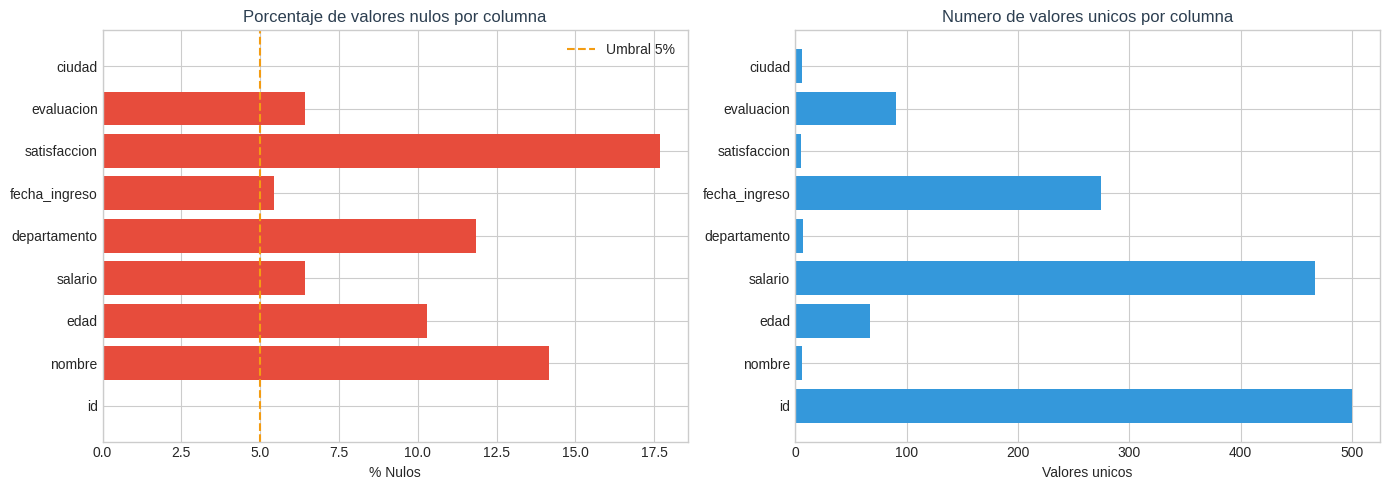

In [3]:
# --- Ejercicio 2: Identificar columnas problematicas ---

# Columnas con >5% nulos
pct_nulls = df_dirty.isnull().mean() * 100
cols_many_nulls = pct_nulls[pct_nulls > 5]
print("Columnas con >5% de valores nulos:")
print(cols_many_nulls.to_string())

# Tipos incorrectos
print("\n--- Tipos de datos actuales ---")
tipos_esperados = {
    'id': 'int', 'nombre': 'object', 'edad': 'float/int',
    'salario': 'float', 'departamento': 'object',
    'fecha_ingreso': 'datetime64', 'satisfaccion': 'object/ordinal',
    'evaluacion': 'float', 'ciudad': 'object'
}
for col in df_dirty.columns:
    actual = str(df_dirty[col].dtype)
    esperado = tipos_esperados.get(col, '?')
    marca = ' << REVISAR' if ('object' in actual and 'date' in esperado.lower()) else ''
    print(f"  {col:20s} actual={actual:10s} esperado={esperado}{marca}")

# Columnas constantes
n_unique = df_dirty.nunique()
cols_constantes = n_unique[n_unique <= 1]
print(f"\nColumnas constantes (n_unique <= 1): {list(cols_constantes.index) if len(cols_constantes) > 0 else 'Ninguna'}")

# Visualizacion resumen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(pct_nulls.index, pct_nulls.values, color=[C_DANGER if v > 5 else C_PRIMARY for v in pct_nulls.values])
axes[0].axvline(x=5, color=C_ORANGE, linestyle='--', label='Umbral 5%')
axes[0].set_xlabel('% Nulos')
axes[0].set_title('Porcentaje de valores nulos por columna', fontsize=12, color=C_DARK)
axes[0].legend()

axes[1].barh(n_unique.index, n_unique.values, color=C_PRIMARY)
axes[1].set_xlabel('Valores unicos')
axes[1].set_title('Numero de valores unicos por columna', fontsize=12, color=C_DARK)

plt.tight_layout()
plt.show()

**Ejercicio 3:** Generar un reporte de calidad de datos en forma de tabla que muestre, para cada columna: nombre, tipo de dato, numero de valores nulos, porcentaje de nulos, numero de valores unicos y un ejemplo de valor. Ordenar por porcentaje de nulos de mayor a menor.

**Resolucion:**

1. Se itera sobre cada columna del DataFrame para recopilar sus metadatos.
2. `df[col].dtype` obtiene el tipo de dato.
3. `df[col].isnull().sum()` cuenta nulos; dividido entre `len(df)` y multiplicado por 100 da el porcentaje.
4. `df[col].nunique()` cuenta valores unicos (excluyendo nulos).
5. `df[col].dropna().iloc[0]` obtiene el primer valor no nulo como ejemplo.
6. Se construye un DataFrame con toda esta informacion y se ordena con `sort_values('% Nulos', ascending=False)`.
7. Se aplica estilo con `Styler.background_gradient()` para resaltar visualmente las columnas mas problematicas.

In [4]:
# --- Ejercicio 3: Reporte de calidad de datos ---

reporte = []
for col in df_dirty.columns:
    n_nulls = df_dirty[col].isnull().sum()
    pct_nulls = round(n_nulls / len(df_dirty) * 100, 2)
    n_unique = df_dirty[col].nunique()
    ejemplo = df_dirty[col].dropna().iloc[0] if df_dirty[col].notna().any() else 'N/A'
    reporte.append({
        'Columna': col,
        'Tipo': str(df_dirty[col].dtype),
        'Nulos': n_nulls,
        '% Nulos': pct_nulls,
        'Unicos': n_unique,
        'Ejemplo': ejemplo
    })

df_reporte = pd.DataFrame(reporte).sort_values('% Nulos', ascending=False).reset_index(drop=True)

# Mostrar con estilo
styled = df_reporte.style.background_gradient(
    subset=['% Nulos'], cmap='Reds'
).background_gradient(
    subset=['Unicos'], cmap='Blues'
).set_caption('Reporte de Calidad de Datos')

display(styled)

,Columna,Tipo,Nulos,% Nulos,Unicos,Ejemplo
0,satisfaccion,object,91,17.670000,5,ALTO
1,nombre,object,73,14.170000,6,pedro Martinez
2,departamento,object,61,11.840000,7,VENTAS
3,edad,float64,53,10.290000,67,31.000000
4,salario,float64,33,6.410000,467,23073.425589
5,evaluacion,float64,33,6.410000,91,5.000000
6,fecha_ingreso,object,28,5.440000,275,2020-01-18
7,id,int64,0,0.000000,500,1
8,ciudad,object,0,0.000000,6,Sevilla


**Ejercicio 4:** Crear un heatmap de valores faltantes (missing values) del DataFrame `df_dirty`. Utilizar seaborn o matplotlib para visualizar la matriz de nulidad, donde cada fila es una observacion y cada columna es una variable, coloreando en un tono distinto las celdas con datos faltantes.

**Resolucion:**

1. Se crea una matriz booleana con `df.isnull()` donde `True` indica dato faltante y `False` dato presente.
2. Se convierte a enteros (0 y 1) para poder usar `sns.heatmap()`.
3. `sns.heatmap()` recibe los parametros:
   - `data`: la matriz booleana convertida a int.
   - `cbar_kws`: personaliza la barra de color.
   - `cmap`: mapa de colores; se usa un mapa de 2 colores (presente vs faltante).
   - `yticklabels=False`: oculta las etiquetas del eje Y (demasiadas filas).
4. La visualizacion permite detectar patrones de nulidad: si los nulos estan dispersos aleatoriamente (MCAR), concentrados en ciertas filas (MAR) o sistematicos (MNAR).

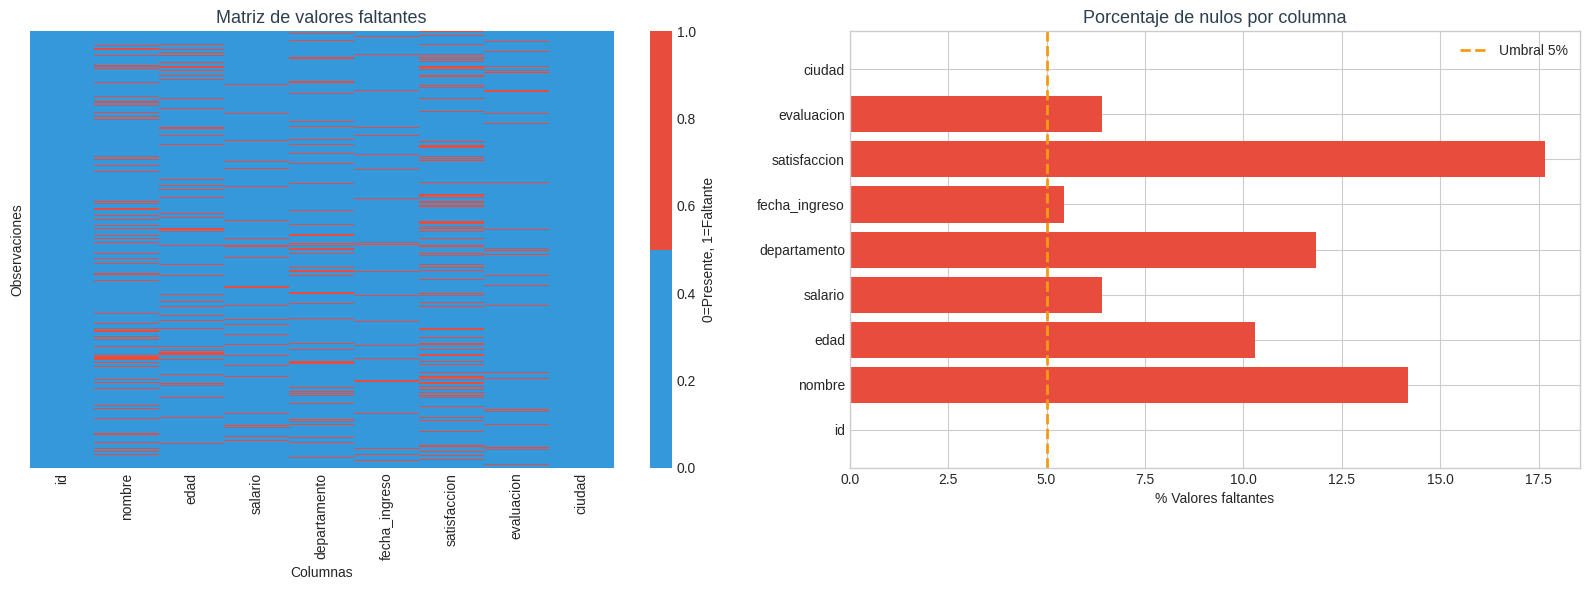

In [5]:
# --- Ejercicio 4: Heatmap de missing values ---

from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de nulidad
cmap_missing = ListedColormap([C_PRIMARY, C_DANGER])
sns.heatmap(df_dirty.isnull().astype(int), cmap=cmap_missing, cbar_kws={'label': '0=Presente, 1=Faltante'},
            yticklabels=False, ax=axes[0])
axes[0].set_title('Matriz de valores faltantes', fontsize=13, color=C_DARK)
axes[0].set_xlabel('Columnas')
axes[0].set_ylabel('Observaciones')

# Barplot de porcentaje de nulos
pct_null = df_dirty.isnull().mean() * 100
colors = [C_DANGER if v > 5 else C_SUCCESS for v in pct_null.values]
axes[1].barh(pct_null.index, pct_null.values, color=colors)
axes[1].axvline(x=5, color=C_ORANGE, linestyle='--', linewidth=2, label='Umbral 5%')
axes[1].set_xlabel('% Valores faltantes')
axes[1].set_title('Porcentaje de nulos por columna', fontsize=13, color=C_DARK)
axes[1].legend()

plt.tight_layout()
plt.show()

**Ejercicio 5:** Imputar los valores nulos de la columna `edad` de dos formas: con la media y con la mediana. Comparar ambas estrategias visualmente mediante histogramas antes y despues de la imputacion. Discutir cual es mas apropiada cuando existen outliers.

**Resolucion:**

1. **Media:** `valor_imputado = media(columna)`. La media es sensible a outliers; si hay valores extremos como edad=150, la media se desplaza hacia arriba.
2. **Mediana:** `valor_imputado = mediana(columna)`. La mediana es el valor central de los datos ordenados; es robusta a outliers porque no se ve afectada por valores extremos.
3. Se usa `df['edad'].fillna(valor)` para reemplazar los NaN por el valor calculado.
4. Se comparan tres histogramas: datos originales (con NaN excluidos), imputados con media, e imputados con mediana.
5. **Conclusion:** Cuando hay outliers, la mediana preserva mejor la distribucion original porque no se desplaza hacia los extremos.

Nulos originales en 'edad': 53
Media de edad (con outliers): 35.77
Mediana de edad: 34.00


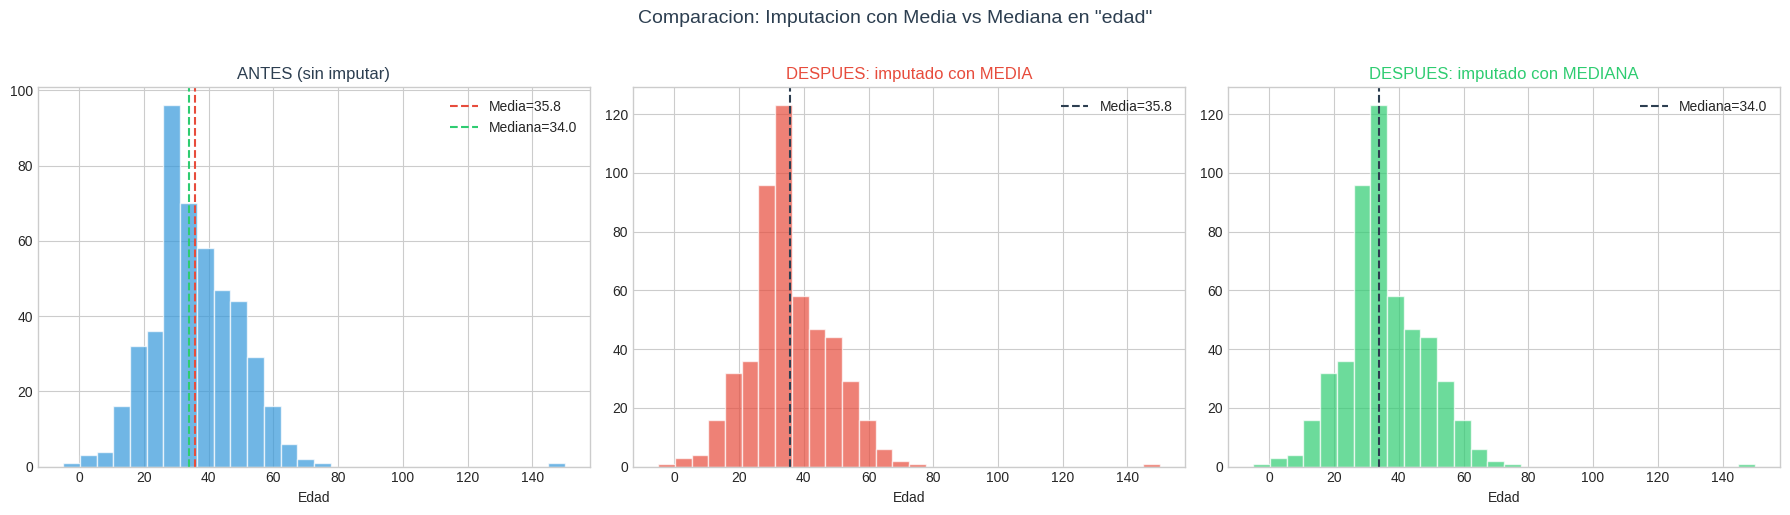

In [6]:
# --- Ejercicio 5: Imputar edad con media vs mediana ---

media_edad = df_dirty['edad'].mean()
mediana_edad = df_dirty['edad'].median()

edad_media = df_dirty['edad'].fillna(media_edad)
edad_mediana = df_dirty['edad'].fillna(mediana_edad)

print(f"Nulos originales en 'edad': {df_dirty['edad'].isnull().sum()}")
print(f"Media de edad (con outliers): {media_edad:.2f}")
print(f"Mediana de edad: {mediana_edad:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_dirty['edad'].dropna(), bins=30, color=C_PRIMARY, alpha=0.7, edgecolor='white')
axes[0].axvline(media_edad, color=C_DANGER, linestyle='--', label=f'Media={media_edad:.1f}')
axes[0].axvline(mediana_edad, color=C_SUCCESS, linestyle='--', label=f'Mediana={mediana_edad:.1f}')
axes[0].set_title('ANTES (sin imputar)', fontsize=12, color=C_DARK)
axes[0].set_xlabel('Edad')
axes[0].legend()

axes[1].hist(edad_media, bins=30, color=C_DANGER, alpha=0.7, edgecolor='white')
axes[1].axvline(media_edad, color=C_DARK, linestyle='--', label=f'Media={media_edad:.1f}')
axes[1].set_title('DESPUES: imputado con MEDIA', fontsize=12, color=C_DANGER)
axes[1].set_xlabel('Edad')
axes[1].legend()

axes[2].hist(edad_mediana, bins=30, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[2].axvline(mediana_edad, color=C_DARK, linestyle='--', label=f'Mediana={mediana_edad:.1f}')
axes[2].set_title('DESPUES: imputado con MEDIANA', fontsize=12, color=C_SUCCESS)
axes[2].set_xlabel('Edad')
axes[2].legend()

plt.suptitle('Comparacion: Imputacion con Media vs Mediana en "edad"', fontsize=14, color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

**Ejercicio 6:** Imputar los valores nulos de la columna `departamento` (categorica) utilizando la moda (valor mas frecuente). Mostrar la distribucion de valores antes y despues de la imputacion con un grafico de barras.

**Resolucion:**

1. **Moda:** `df['columna'].mode()[0]` devuelve el valor mas frecuente de la columna. Se usa `[0]` porque `mode()` puede devolver multiples valores si hay empate.
2. `df['columna'].fillna(moda)` reemplaza todos los NaN por la moda.
3. Para variables categoricas, la moda es la unica medida de tendencia central aplicable (no se puede calcular media ni mediana de texto).
4. Se comparan las distribuciones con graficos de barras lado a lado para verificar que la imputacion no distorsione excesivamente las proporciones originales.
5. **Nota:** En este dataset, `departamento` tiene inconsistencias de case (Ventas, ventas, VENTAS) que se tratan en ejercicios posteriores.

Moda de 'departamento': IT
Nulos antes: 61
Nulos despues: 0


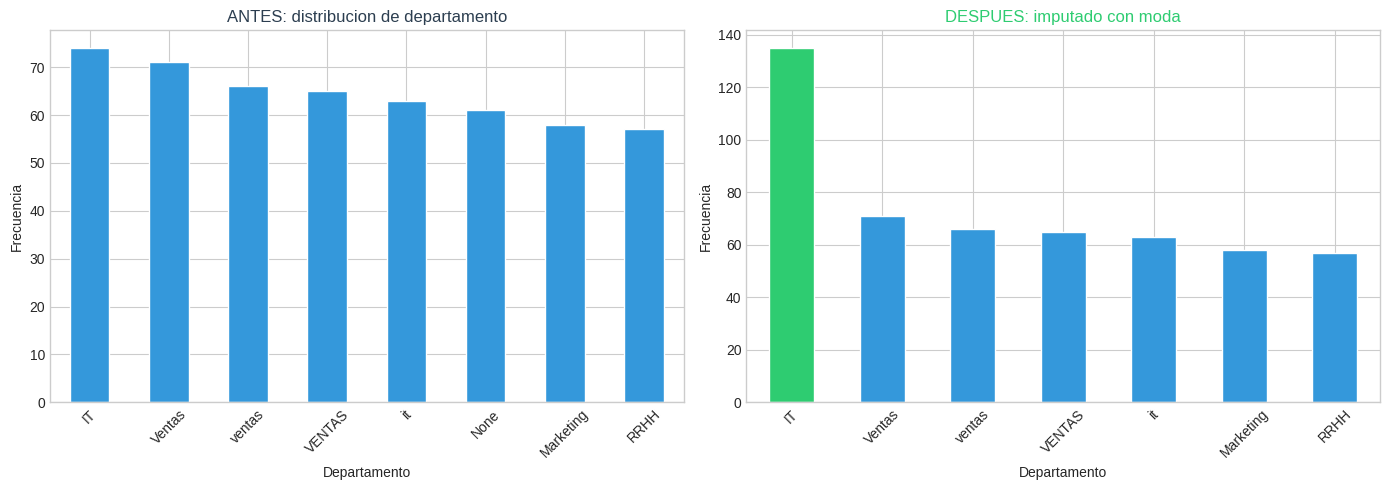

In [7]:
# --- Ejercicio 6: Imputar departamento con moda ---

moda_depto = df_dirty['departamento'].mode()[0]
print(f"Moda de 'departamento': {moda_depto}")
print(f"Nulos antes: {df_dirty['departamento'].isnull().sum()}")

depto_imputado = df_dirty['departamento'].fillna(moda_depto)
print(f"Nulos despues: {depto_imputado.isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
conteo_antes = df_dirty['departamento'].value_counts(dropna=False)
conteo_antes.plot(kind='bar', ax=axes[0], color=C_PRIMARY, edgecolor='white')
axes[0].set_title('ANTES: distribucion de departamento', fontsize=12, color=C_DARK)
axes[0].set_xlabel('Departamento')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)

# Despues
conteo_despues = depto_imputado.value_counts(dropna=False)
colores = [C_SUCCESS if idx == moda_depto else C_PRIMARY for idx in conteo_despues.index]
conteo_despues.plot(kind='bar', ax=axes[1], color=colores, edgecolor='white')
axes[1].set_title('DESPUES: imputado con moda', fontsize=12, color=C_SUCCESS)
axes[1].set_xlabel('Departamento')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Ejercicio 7:** Crear una serie temporal simulada con valores faltantes e imputar utilizando forward-fill (propagacion hacia adelante). Visualizar la serie antes y despues de la imputacion para verificar que los huecos se rellenan con el ultimo valor valido.

**Resolucion:**

1. Se genera una serie temporal con `pd.date_range()` y valores sinteticos (por ejemplo, seno + ruido).
2. Se inyectan NaN en posiciones aleatorias para simular datos faltantes.
3. **Forward-fill** (`df.ffill()` o `df.fillna(method='ffill')`): propaga el ultimo valor valido hacia adelante. Es decir, cada NaN se reemplaza por el valor inmediatamente anterior que no sea NaN.
4. Es apropiado para series temporales porque asume que el valor mas reciente es la mejor estimacion cuando no hay medicion.
5. **Limitacion:** Si el primer valor es NaN, forward-fill no puede rellenarlo (no hay valor anterior). En ese caso se complementa con backward-fill (`bfill`).

Nulos antes: 20
Nulos despues de ffill: 0


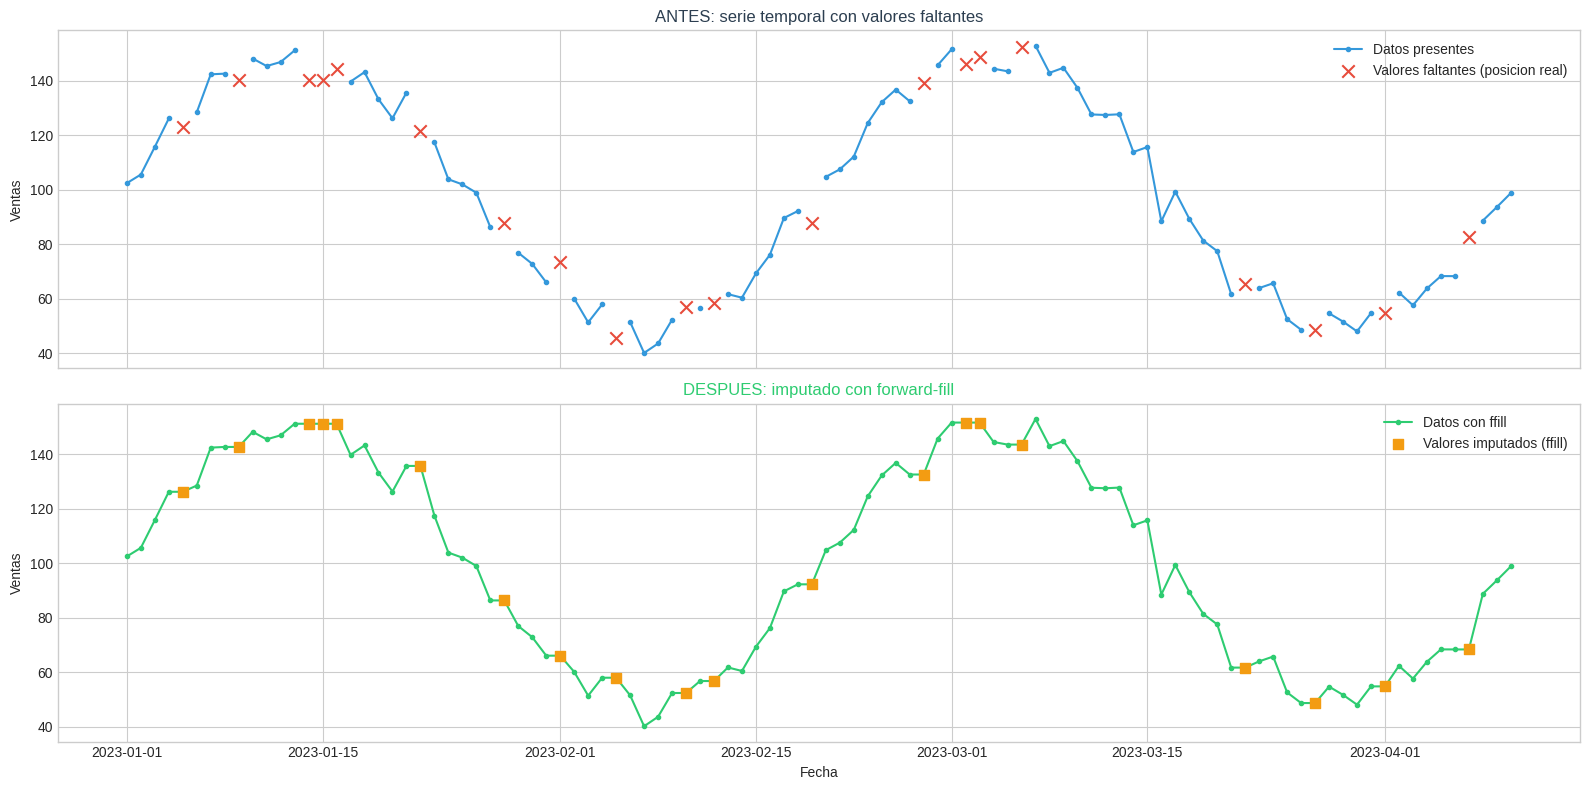

In [8]:
# --- Ejercicio 7: Forward-fill en serie temporal ---

np.random.seed(42)
fechas = pd.date_range('2023-01-01', periods=100, freq='D')
valores = np.sin(np.linspace(0, 4 * np.pi, 100)) * 50 + 100 + np.random.normal(0, 5, 100)

ts = pd.Series(valores, index=fechas, name='ventas')

# Inyectar NaN en posiciones aleatorias
idx_nan = np.random.choice(range(1, 100), size=20, replace=False)
ts_con_nan = ts.copy()
ts_con_nan.iloc[idx_nan] = np.nan

# Forward-fill
ts_ffill = ts_con_nan.ffill()

print(f"Nulos antes: {ts_con_nan.isnull().sum()}")
print(f"Nulos despues de ffill: {ts_ffill.isnull().sum()}")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Antes
axes[0].plot(ts_con_nan.index, ts_con_nan.values, color=C_PRIMARY, marker='o', markersize=3, label='Datos presentes')
mask_nan = ts_con_nan.isnull()
axes[0].scatter(ts_con_nan.index[mask_nan], [ts.iloc[i] for i in range(len(ts)) if mask_nan.iloc[i]],
                color=C_DANGER, marker='x', s=80, zorder=5, label='Valores faltantes (posicion real)')
axes[0].set_title('ANTES: serie temporal con valores faltantes', fontsize=12, color=C_DARK)
axes[0].legend()
axes[0].set_ylabel('Ventas')

# Despues
axes[1].plot(ts_ffill.index, ts_ffill.values, color=C_SUCCESS, marker='o', markersize=3, label='Datos con ffill')
axes[1].scatter(ts_con_nan.index[mask_nan], ts_ffill[mask_nan],
                color=C_ORANGE, marker='s', s=60, zorder=5, label='Valores imputados (ffill)')
axes[1].set_title('DESPUES: imputado con forward-fill', fontsize=12, color=C_SUCCESS)
axes[1].legend()
axes[1].set_ylabel('Ventas')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

**Ejercicio 8:** Imputar los valores nulos de `salario` utilizando la media de salario por departamento (imputacion por grupo). Primero normalizar `departamento` a title case, luego calcular la media de salario para cada departamento y rellenar los nulos con la media correspondiente a su grupo.

**Resolucion:**

1. **Normalizar departamento:** `df['departamento'].str.strip().str.title()` unifica las variantes (Ventas, ventas, VENTAS -> Ventas).
2. **Calcular media por grupo:** `df.groupby('depto_norm')['salario'].transform('mean')` calcula la media de salario para cada departamento y la asigna a cada fila del grupo.
3. **Imputar:** `df['salario'].fillna(media_por_grupo)` rellena cada NaN con la media de su departamento.
4. Esta estrategia es superior a la media global porque respeta la estructura de los datos: si el departamento de IT tiene salarios mas altos que RRHH, un nulo en IT se rellena con la media de IT, no con la media general.
5. Si el departamento tambien es NaN, se usa la media global como fallback.

Media de salario por departamento:
depto_norm
It           41015.10
Marketing    40185.14
Rrhh         43661.20
Ventas       41086.82

Nulos antes: 33
Nulos despues: 0


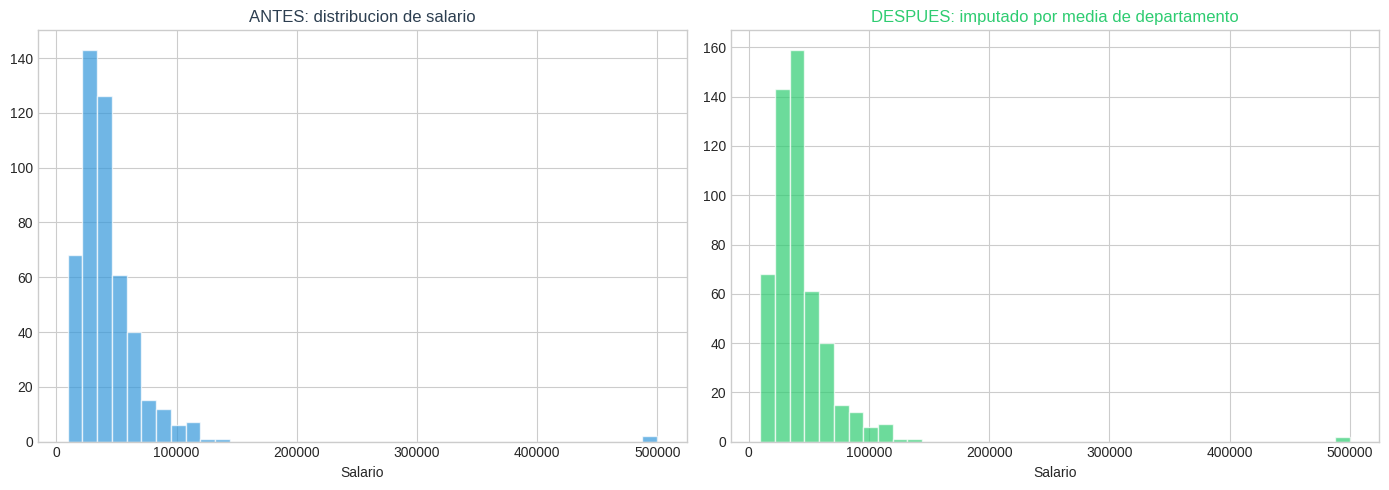

In [9]:
# --- Ejercicio 8: Imputar salario por grupo (departamento) ---

df_temp = df_dirty.copy()
df_temp['depto_norm'] = df_temp['departamento'].str.strip().str.title()

# Media por departamento
media_por_depto = df_temp.groupby('depto_norm')['salario'].mean()
print("Media de salario por departamento:")
print(media_por_depto.round(2).to_string())

# Imputar por grupo
media_grupo = df_temp.groupby('depto_norm')['salario'].transform('mean')
salario_antes = df_temp['salario'].copy()
df_temp['salario_imputado'] = df_temp['salario'].fillna(media_grupo)
# Fallback con media global si departamento es NaN
df_temp['salario_imputado'] = df_temp['salario_imputado'].fillna(df_temp['salario'].mean())

print(f"\nNulos antes: {salario_antes.isnull().sum()}")
print(f"Nulos despues: {df_temp['salario_imputado'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(salario_antes.dropna(), bins=40, color=C_PRIMARY, alpha=0.7, edgecolor='white')
axes[0].set_title('ANTES: distribucion de salario', fontsize=12, color=C_DARK)
axes[0].set_xlabel('Salario')

axes[1].hist(df_temp['salario_imputado'], bins=40, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[1].set_title('DESPUES: imputado por media de departamento', fontsize=12, color=C_SUCCESS)
axes[1].set_xlabel('Salario')

plt.tight_layout()
plt.show()

del df_temp

**Ejercicio 9:** Utilizar `KNNImputer` de scikit-learn para imputar las columnas numericas (`edad`, `salario`, `evaluacion`) y comparar el resultado con la imputacion por media simple. Visualizar las distribuciones resultantes de ambos metodos.

**Resolucion:**

1. **KNNImputer:** Imputa cada valor faltante utilizando la media ponderada de los `n_neighbors` vecinos mas cercanos (por defecto k=5). La distancia se calcula en el espacio de las columnas numericas.
   - Parametro `n_neighbors`: numero de vecinos a considerar (default=5).
   - Parametro `weights`: 'uniform' (todos pesan igual) o 'distance' (los mas cercanos pesan mas).
2. **SimpleImputer(strategy='mean'):** Reemplaza cada NaN por la media de la columna, sin considerar la estructura de los datos.
3. KNNImputer es mas sofisticado porque tiene en cuenta las relaciones entre variables: si una persona tiene alta evaluacion y esta en IT, su salario imputado reflejara esas caracteristicas.
4. Se comparan ambos metodos con histogramas para cada columna numerica.

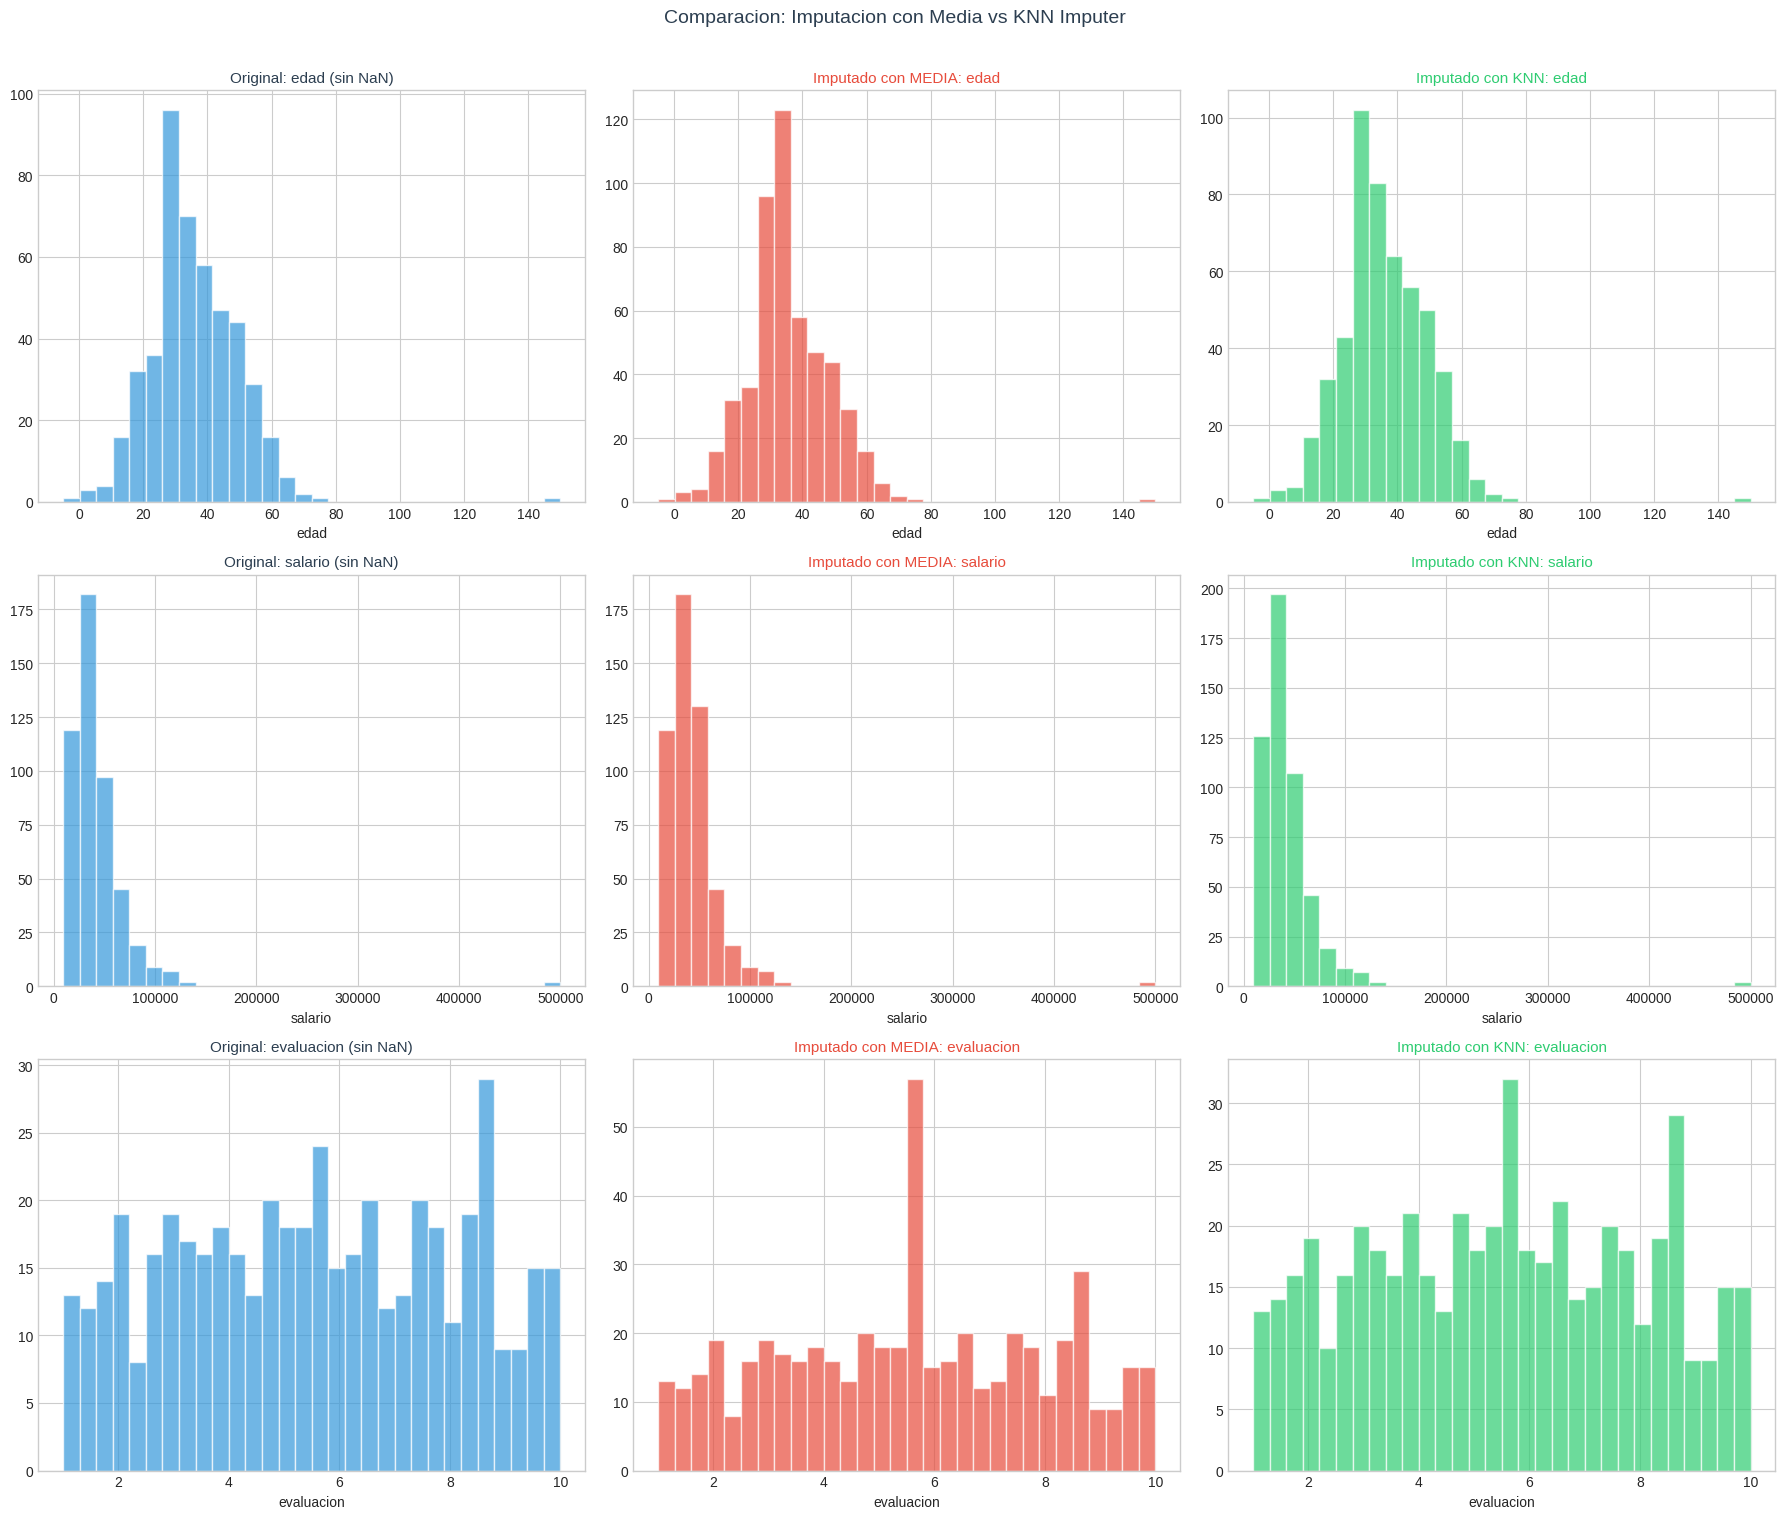


--- Estadisticas comparativas ---

edad:
  Original  -> media=35.77, std=13.93
  Imp.Media -> media=35.77, std=13.19
  Imp.KNN   -> media=35.99, std=13.55

salario:
  Original  -> media=42939.38, std=36333.20
  Imp.Media -> media=42939.38, std=35147.52
  Imp.KNN   -> media=42503.15, std=35313.70

evaluacion:
  Original  -> media=5.50, std=2.50
  Imp.Media -> media=5.50, std=2.41
  Imp.KNN   -> media=5.46, std=2.46


In [10]:
# --- Ejercicio 9: KNN Imputer vs Media ---

cols_num = ['edad', 'salario', 'evaluacion']
df_num = df_dirty[cols_num].copy()

# Imputacion con media
imp_media = SimpleImputer(strategy='mean')
df_media = pd.DataFrame(imp_media.fit_transform(df_num), columns=cols_num)

# Imputacion con KNN
imp_knn = KNNImputer(n_neighbors=5, weights='distance')
df_knn = pd.DataFrame(imp_knn.fit_transform(df_num), columns=cols_num)

fig, axes = plt.subplots(len(cols_num), 3, figsize=(18, 5 * len(cols_num)))

for i, col in enumerate(cols_num):
    # Original
    axes[i, 0].hist(df_num[col].dropna(), bins=30, color=C_PRIMARY, alpha=0.7, edgecolor='white')
    axes[i, 0].set_title(f'Original: {col} (sin NaN)', fontsize=11, color=C_DARK)
    axes[i, 0].set_xlabel(col)

    # Media
    axes[i, 1].hist(df_media[col], bins=30, color=C_DANGER, alpha=0.7, edgecolor='white')
    axes[i, 1].set_title(f'Imputado con MEDIA: {col}', fontsize=11, color=C_DANGER)
    axes[i, 1].set_xlabel(col)

    # KNN
    axes[i, 2].hist(df_knn[col], bins=30, color=C_SUCCESS, alpha=0.7, edgecolor='white')
    axes[i, 2].set_title(f'Imputado con KNN: {col}', fontsize=11, color=C_SUCCESS)
    axes[i, 2].set_xlabel(col)

plt.suptitle('Comparacion: Imputacion con Media vs KNN Imputer', fontsize=14, color=C_DARK, y=1.01)
plt.tight_layout()
plt.show()

# Estadisticas comparativas
print("\n--- Estadisticas comparativas ---")
for col in cols_num:
    print(f"\n{col}:")
    print(f"  Original  -> media={df_num[col].mean():.2f}, std={df_num[col].std():.2f}")
    print(f"  Imp.Media -> media={df_media[col].mean():.2f}, std={df_media[col].std():.2f}")
    print(f"  Imp.KNN   -> media={df_knn[col].mean():.2f}, std={df_knn[col].std():.2f}")

**Ejercicio 10:** Antes de imputar `salario`, crear una columna binaria `salario_missing` que valga 1 donde `salario` es NaN y 0 donde tiene valor. Luego imputar `salario` con la mediana. Mostrar la tabla con ambas columnas y verificar que la flag se creo correctamente.

**Resolucion:**

1. Se crea la columna flag con `df['salario_missing'] = df['salario'].isnull().astype(int)`. Esto convierte True/False a 1/0.
2. La flag se crea **antes** de imputar, ya que despues de la imputacion ya no se sabra cuales valores eran originalmente faltantes.
3. Esta tecnica es util porque la "razon de la ausencia" puede contener informacion predictiva. Por ejemplo, si los salarios faltantes corresponden sistematicamente a empleados nuevos, el modelo puede aprender ese patron.
4. Despues se imputa con la mediana: `df['salario'].fillna(df['salario'].median())`.
5. Se verifica la coherencia: donde `salario_missing == 1`, el valor de `salario` despues de imputar debe ser igual a la mediana.

Mediana de salario: 36818.70
Total filas con salario faltante: 33
Nulos en salario_imputado: 0

Filas con flag=1 (muestra):


,salario,salario_missing,salario_imputado
38,NaN,1,36818.698897
62,NaN,1,36818.698897
96,NaN,1,36818.698897
128,NaN,1,36818.698897
136,NaN,1,36818.698897
153,NaN,1,36818.698897
161,NaN,1,36818.698897
176,NaN,1,36818.698897
183,NaN,1,36818.698897
195,NaN,1,36818.698897


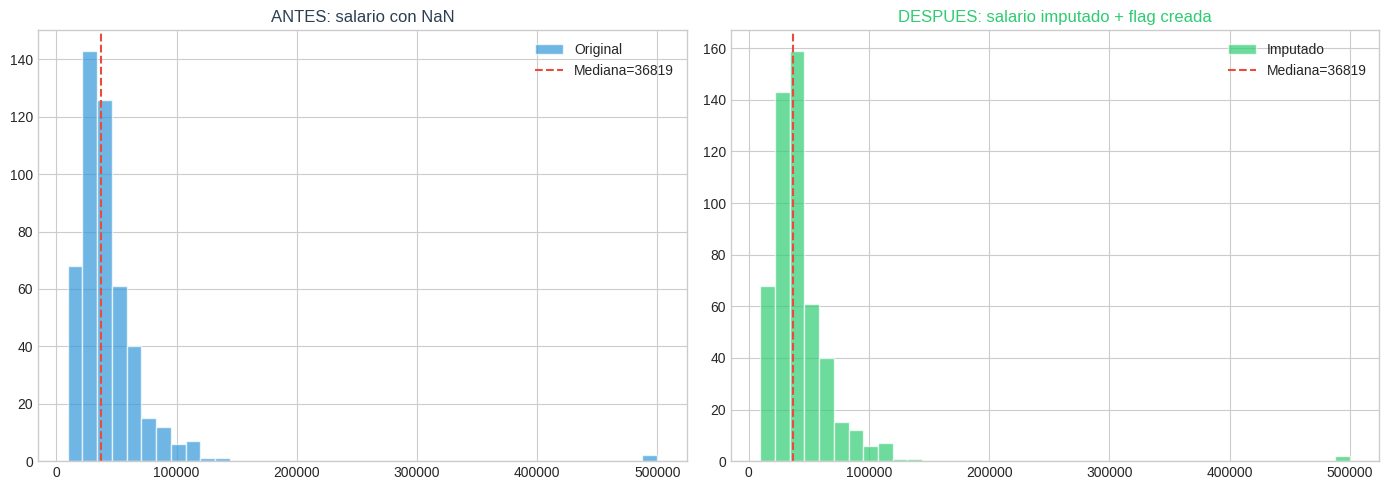

In [11]:
# --- Ejercicio 10: Flag de missing antes de imputar ---

df_temp = df_dirty[['id', 'salario']].copy()

# Paso 1: crear flag ANTES de imputar
df_temp['salario_missing'] = df_temp['salario'].isnull().astype(int)

# Paso 2: imputar con mediana
mediana_salario = df_temp['salario'].median()
df_temp['salario_imputado'] = df_temp['salario'].fillna(mediana_salario)

print(f"Mediana de salario: {mediana_salario:.2f}")
print(f"Total filas con salario faltante: {df_temp['salario_missing'].sum()}")
print(f"Nulos en salario_imputado: {df_temp['salario_imputado'].isnull().sum()}")

# Verificar: donde flag=1, el valor imputado debe ser la mediana
verificacion = df_temp[df_temp['salario_missing'] == 1][['salario', 'salario_missing', 'salario_imputado']]
print(f"\nFilas con flag=1 (muestra):")
display(verificacion.head(10))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_dirty['salario'].dropna(), bins=40, color=C_PRIMARY, alpha=0.7, edgecolor='white', label='Original')
axes[0].axvline(mediana_salario, color=C_DANGER, linestyle='--', label=f'Mediana={mediana_salario:.0f}')
axes[0].set_title('ANTES: salario con NaN', fontsize=12, color=C_DARK)
axes[0].legend()

axes[1].hist(df_temp['salario_imputado'], bins=40, color=C_SUCCESS, alpha=0.7, edgecolor='white', label='Imputado')
axes[1].axvline(mediana_salario, color=C_DANGER, linestyle='--', label=f'Mediana={mediana_salario:.0f}')
axes[1].set_title('DESPUES: salario imputado + flag creada', fontsize=12, color=C_SUCCESS)
axes[1].legend()

plt.tight_layout()
plt.show()

del df_temp

**Ejercicio 11:** Detectar y eliminar los duplicados exactos en `df_dirty`. Mostrar cuantos duplicados hay, cuales son las filas duplicadas, y el shape del DataFrame antes y despues de la eliminacion.

**Resolucion:**

1. `df.duplicated()` devuelve una serie booleana donde `True` indica que la fila es duplicada (tiene una fila identica anterior).
2. `df.duplicated().sum()` cuenta el total de duplicados.
3. `df[df.duplicated(keep=False)]` muestra todas las filas involucradas en duplicacion (tanto la primera aparicion como las copias).
4. `df.drop_duplicates()` elimina las filas duplicadas, conservando la primera aparicion por defecto.
   - `keep='first'`: conserva la primera aparicion (default).
   - `keep='last'`: conserva la ultima aparicion.
   - `keep=False`: elimina todas las apariciones.
5. Se verifica comparando `df.shape` antes y despues.

ANTES: 515 filas, 15 duplicados exactos detectados

Filas duplicadas (muestra):


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
0,1,pedro Martinez,31.0,23073.425589,VENTAS,2020-01-18,None,5.0,Sevilla
1,2,Ana Torres,29.0,61594.486576,RRHH,2020-04-21,ALTO,5.3,madrid
2,3,LUIS sanchez,42.0,45608.292605,None,2020-04-01,Bajo,2.9,Valencia
3,4,pedro Martinez,53.0,21144.784963,ventas,2020-10-26,ALTO,2.0,BARCELONA
4,5,pedro martinez,49.0,18697.442936,IT,2020-04-23,None,8.5,Valencia
5,6,LUIS sanchez,43.0,36029.385374,RRHH,2020-11-09,None,5.5,Valencia
6,7,LUIS sanchez,27.0,55550.455489,RRHH,None,medio,1.1,BARCELONA
7,8,pedro Martinez,32.0,56266.686851,Marketing,2020-02-24,ALTO,8.2,BARCELONA
8,9,MARIA LOPEZ,31.0,43394.302758,ventas,2020-04-05,Bajo,9.8,Madrid
9,10,pedro martinez,29.0,37210.171085,ventas,2020-08-19,Bajo,6.5,Valencia



DESPUES: 500 filas (se eliminaron 15 filas)


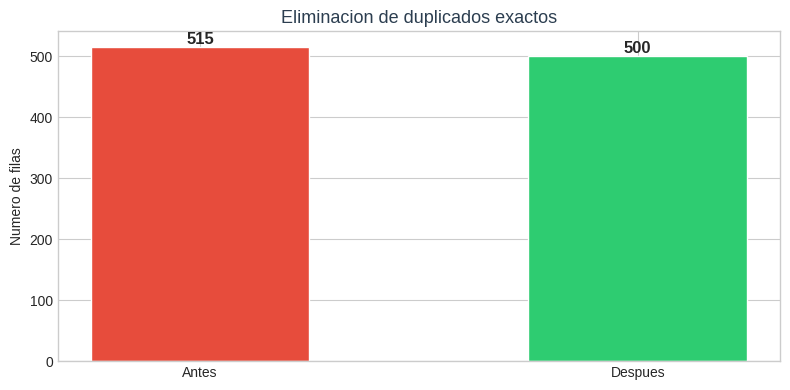

In [12]:
# --- Ejercicio 11: Detectar y eliminar duplicados exactos ---

n_dupes = df_dirty.duplicated().sum()
print(f"ANTES: {df_dirty.shape[0]} filas, {n_dupes} duplicados exactos detectados")

# Mostrar las filas duplicadas
print("\nFilas duplicadas (muestra):")
display(df_dirty[df_dirty.duplicated(keep=False)].head(10))

# Eliminar duplicados
df_sin_dupes = df_dirty.drop_duplicates(keep='first')
print(f"\nDESPUES: {df_sin_dupes.shape[0]} filas (se eliminaron {df_dirty.shape[0] - df_sin_dupes.shape[0]} filas)")

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Antes', 'Despues'], [df_dirty.shape[0], df_sin_dupes.shape[0]],
              color=[C_DANGER, C_SUCCESS], edgecolor='white', width=0.5)
ax.bar_label(bars, fontsize=12, fontweight='bold')
ax.set_ylabel('Numero de filas')
ax.set_title('Eliminacion de duplicados exactos', fontsize=13, color=C_DARK)
plt.tight_layout()
plt.show()

**Ejercicio 12:** Detectar duplicados aproximados en la columna `nombre`. Normalizar los nombres (strip, lower, quitar espacios multiples) y luego identificar cuales nombres, tras la normalizacion, resultan ser el mismo. Mostrar los grupos de nombres que son duplicados aproximados.

**Resolucion:**

1. **Normalizar:** Se aplica una cadena de transformaciones:
   - `str.strip()`: elimina espacios al inicio y final.
   - `str.lower()`: convierte a minusculas para que "MARIA LOPEZ" y "maria lopez" sean iguales.
   - `str.replace(r'\s+', ' ', regex=True)`: reemplaza multiples espacios por uno solo.
2. Se compara el numero de valores unicos antes y despues de la normalizacion para cuantificar cuantos duplicados aproximados habia.
3. Se agrupan los nombres originales por su version normalizada para ver las variantes que representan la misma persona.
4. Esta tecnica es fundamental en datos del mundo real donde los nombres se capturan con diferentes formatos.

Valores unicos ANTES de normalizar: 6
Valores unicos DESPUES de normalizar: 5
Duplicados aproximados detectados: 1

--- Variantes por nombre normalizado ---
  'pedro martinez' <- variantes: ['pedro Martinez', '  pedro martinez  ']


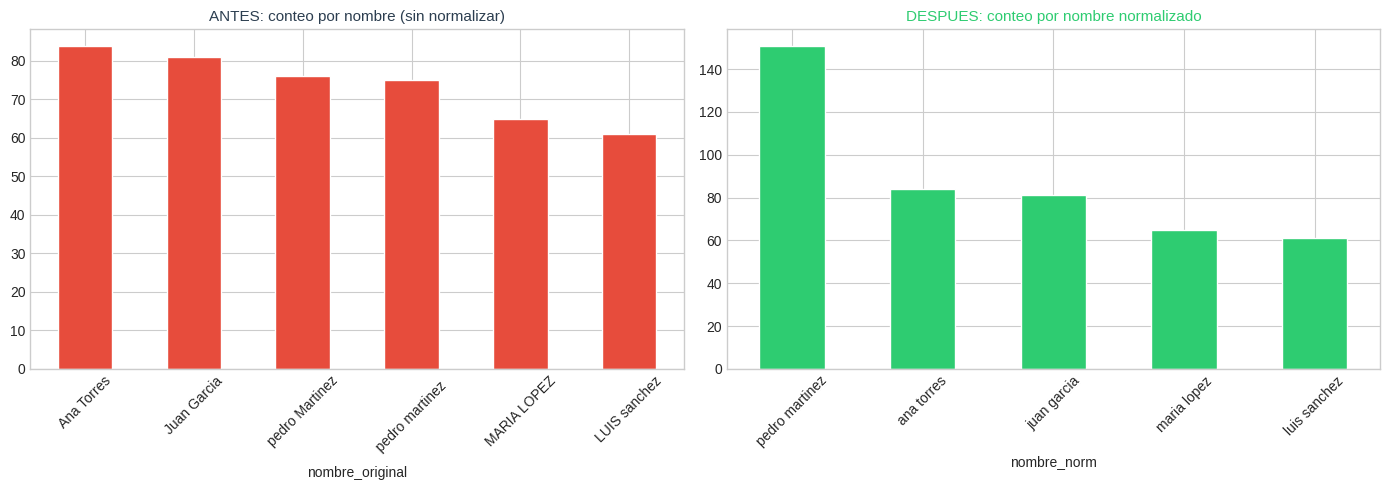

In [13]:
# --- Ejercicio 12: Duplicados aproximados en nombre ---

import re

df_temp = df_dirty[['nombre']].dropna().copy()
df_temp['nombre_original'] = df_temp['nombre']
df_temp['nombre_norm'] = (df_temp['nombre']
                          .str.strip()
                          .str.lower()
                          .str.replace(r'\s+', ' ', regex=True))

n_antes = df_temp['nombre_original'].nunique()
n_despues = df_temp['nombre_norm'].nunique()
print(f"Valores unicos ANTES de normalizar: {n_antes}")
print(f"Valores unicos DESPUES de normalizar: {n_despues}")
print(f"Duplicados aproximados detectados: {n_antes - n_despues}")

# Mostrar grupos de variantes
print("\n--- Variantes por nombre normalizado ---")
grupos = df_temp.groupby('nombre_norm')['nombre_original'].unique()
for norm, variantes in grupos.items():
    if len(variantes) > 1:
        print(f"  '{norm}' <- variantes: {list(variantes)}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_temp['nombre_original'].value_counts().plot(kind='bar', ax=axes[0], color=C_DANGER, edgecolor='white')
axes[0].set_title('ANTES: conteo por nombre (sin normalizar)', fontsize=11, color=C_DARK)
axes[0].tick_params(axis='x', rotation=45)

df_temp['nombre_norm'].value_counts().plot(kind='bar', ax=axes[1], color=C_SUCCESS, edgecolor='white')
axes[1].set_title('DESPUES: conteo por nombre normalizado', fontsize=11, color=C_SUCCESS)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

del df_temp

**Ejercicio 13:** Detectar duplicados basados en el subconjunto de columnas `['nombre', 'departamento']`, conservando solo la primera aparicion (`keep='first'`). Mostrar cuantos registros se eliminan y una muestra de los duplicados encontrados.

**Resolucion:**

1. `df.duplicated(subset=['nombre', 'departamento'])` marca como duplicada toda fila cuya combinacion de nombre y departamento ya aparecio antes.
2. A diferencia de los duplicados exactos (todas las columnas), aqui se buscan filas que comparten las mismas claves de negocio aunque difieran en otras columnas.
3. `keep='first'` conserva la primera aparicion y marca las demas como duplicadas.
4. `df.drop_duplicates(subset=['nombre', 'departamento'], keep='first')` elimina las marcadas.
5. Este tipo de deduplicacion es comun cuando se fusionan bases de datos de diferentes fuentes.

Duplicados por subconjunto ['nombre', 'departamento']: 459

Filas involucradas en duplicacion (muestra):


,id,nombre,edad,salario,departamento,fecha_ingreso,satisfaccion,evaluacion,ciudad
4,5,pedro martinez,49.0,18697.442936,IT,2020-04-23,None,8.5,Valencia
15,16,pedro martinez,NaN,40080.700374,IT,2020-04-13,None,6.3,madrid
49,50,pedro martinez,28.0,30077.807526,IT,2020-07-26,bajo,8.4,Barcelona
51,52,pedro martinez,30.0,67994.250852,IT,None,alto,9.3,Valencia
149,150,pedro martinez,37.0,23863.070517,IT,2020-04-19,ALTO,3.0,Valencia
152,153,pedro martinez,19.0,16123.311058,IT,2020-07-25,None,5.4,BARCELONA
159,160,pedro martinez,27.0,19792.063632,IT,2020-03-07,medio,8.3,Madrid
194,195,pedro martinez,10.0,44095.866368,IT,2020-09-07,ALTO,8.7,BARCELONA
235,236,pedro martinez,NaN,30407.909999,IT,2020-08-20,bajo,3.2,Madrid
295,296,pedro martinez,40.0,41510.574923,IT,2020-02-07,bajo,9.0,Barcelona



Antes: 515 filas
Despues: 56 filas
Eliminadas: 459


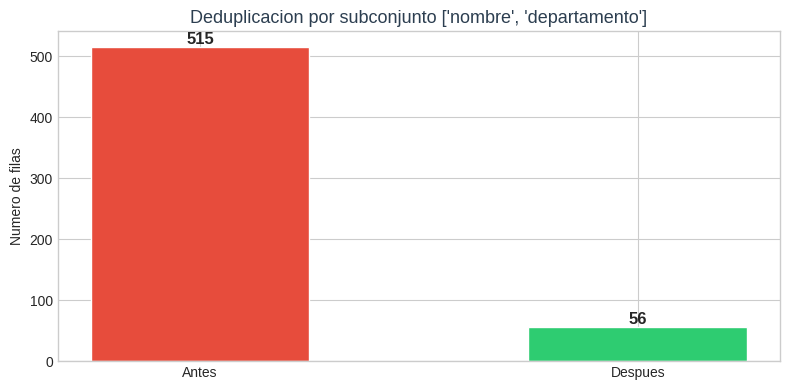

In [14]:
# --- Ejercicio 13: Duplicados por subconjunto ['nombre', 'departamento'] ---

subset_cols = ['nombre', 'departamento']
n_dupes_subset = df_dirty.duplicated(subset=subset_cols, keep='first').sum()
print(f"Duplicados por subconjunto {subset_cols}: {n_dupes_subset}")

# Mostrar muestra de duplicados
dupes_mask = df_dirty.duplicated(subset=subset_cols, keep=False)
print(f"\nFilas involucradas en duplicacion (muestra):")
display(df_dirty[dupes_mask].sort_values(subset_cols).head(15))

# Eliminar
df_dedup = df_dirty.drop_duplicates(subset=subset_cols, keep='first')
print(f"\nAntes: {df_dirty.shape[0]} filas")
print(f"Despues: {df_dedup.shape[0]} filas")
print(f"Eliminadas: {df_dirty.shape[0] - df_dedup.shape[0]}")

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Antes', 'Despues']
valores = [df_dirty.shape[0], df_dedup.shape[0]]
bars = ax.bar(categorias, valores, color=[C_DANGER, C_SUCCESS], edgecolor='white', width=0.5)
ax.bar_label(bars, fontsize=12, fontweight='bold')
ax.set_ylabel('Numero de filas')
ax.set_title(f'Deduplicacion por subconjunto {subset_cols}', fontsize=13, color=C_DARK)
plt.tight_layout()
plt.show()

**Ejercicio 14:** Detectar outliers en la columna `salario` utilizando el metodo IQR (Rango Intercuartilico). Calcular Q1, Q3, IQR, y los limites inferior y superior. Identificar los outliers y visualizarlos con un boxplot antes y despues de su eliminacion.

**Resolucion:**

1. **Q1** = percentil 25 de la columna: `df['salario'].quantile(0.25)`.
2. **Q3** = percentil 75 de la columna: `df['salario'].quantile(0.75)`.
3. **IQR** = Q3 - Q1: rango intercuartilico, mide la dispersion del 50% central de los datos.
4. **Limite inferior** = Q1 - 1.5 * IQR: valores por debajo son outliers.
5. **Limite superior** = Q3 + 1.5 * IQR: valores por encima son outliers.
6. Un outlier es cualquier valor `x` tal que `x < limite_inferior` o `x > limite_superior`.
7. Se usa un boxplot que automaticamente muestra los bigotes (limites) y los puntos fuera de ellos (outliers).

Q1 = 25819.23
Q3 = 50502.83
IQR = 24683.60
Limite inferior = -11206.17
Limite superior = 87528.23
Outliers detectados: 20 (4.1%)

Valores outlier:
[500000.          94594.64559846  99699.79959096  95984.15901312
 100797.91554428 109071.9805828   92073.47908291 113450.77842653
 118404.13616506 109048.6171074  129756.72637493  93945.28398392
 108598.46803995 100372.83528432 138241.23050188 102865.16912454
 111287.42188533 104268.26178537 110124.83209936 500000.        ]


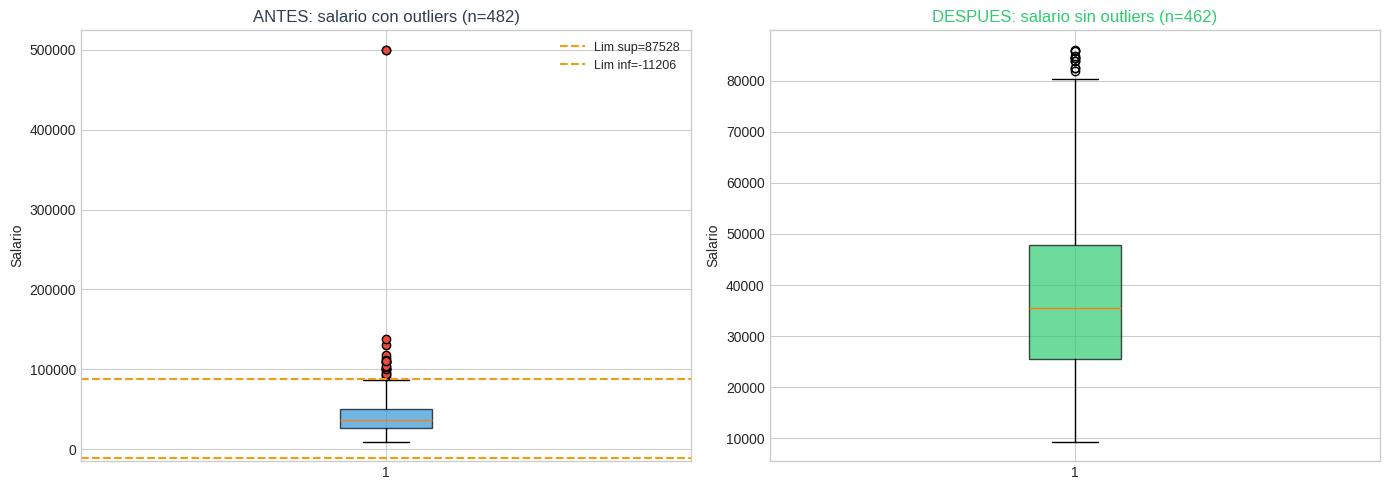

In [15]:
# --- Ejercicio 14: Outliers en salario con IQR ---

salario = df_dirty['salario'].dropna()

Q1 = salario.quantile(0.25)
Q3 = salario.quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_mask = (salario < lim_inf) | (salario > lim_sup)
n_outliers = outliers_mask.sum()

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Limite inferior = {lim_inf:.2f}")
print(f"Limite superior = {lim_sup:.2f}")
print(f"Outliers detectados: {n_outliers} ({n_outliers/len(salario)*100:.1f}%)")
print(f"\nValores outlier:")
print(salario[outliers_mask].values)

# Salario sin outliers
salario_clean = salario[~outliers_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp1 = axes[0].boxplot(salario.values, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=C_PRIMARY, alpha=0.7),
                       flierprops=dict(marker='o', markerfacecolor=C_DANGER, markersize=6))
axes[0].set_title(f'ANTES: salario con outliers (n={len(salario)})', fontsize=12, color=C_DARK)
axes[0].set_ylabel('Salario')
axes[0].axhline(lim_sup, color=C_ORANGE, linestyle='--', label=f'Lim sup={lim_sup:.0f}')
axes[0].axhline(lim_inf, color=C_ORANGE, linestyle='--', label=f'Lim inf={lim_inf:.0f}')
axes[0].legend(fontsize=9)

bp2 = axes[1].boxplot(salario_clean.values, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=C_SUCCESS, alpha=0.7))
axes[1].set_title(f'DESPUES: salario sin outliers (n={len(salario_clean)})', fontsize=12, color=C_SUCCESS)
axes[1].set_ylabel('Salario')

plt.tight_layout()
plt.show()

**Ejercicio 15:** Detectar outliers en la columna `edad` utilizando el Z-score. Calcular el Z-score de cada valor y marcar como outlier aquellos con |z| > 3. Mostrar los valores detectados y su Z-score correspondiente.

**Resolucion:**

1. **Z-score:** `z = (x - media) / desviacion_estandar`. Mide cuantas desviaciones estandar un valor esta alejado de la media.
2. Se calcula con `scipy.stats.zscore()` o manualmente con `(df['edad'] - df['edad'].mean()) / df['edad'].std()`.
3. Un valor con `|z| > 3` esta a mas de 3 desviaciones estandar de la media, lo cual es extremadamente improbable en una distribucion normal (probabilidad < 0.3%).
4. En nuestro dataset, la edad=150 y edad=-5 deberian tener Z-scores muy altos en valor absoluto.
5. Se visualiza con un scatter plot donde el eje X es el indice y el eje Y el Z-score, marcando los outliers en rojo.

Media de edad: 35.77
Desviacion estandar: 13.93
Outliers detectados (|z| > 3): 1

Detalle de outliers:
  Indice 20: edad=150, z-score=8.20


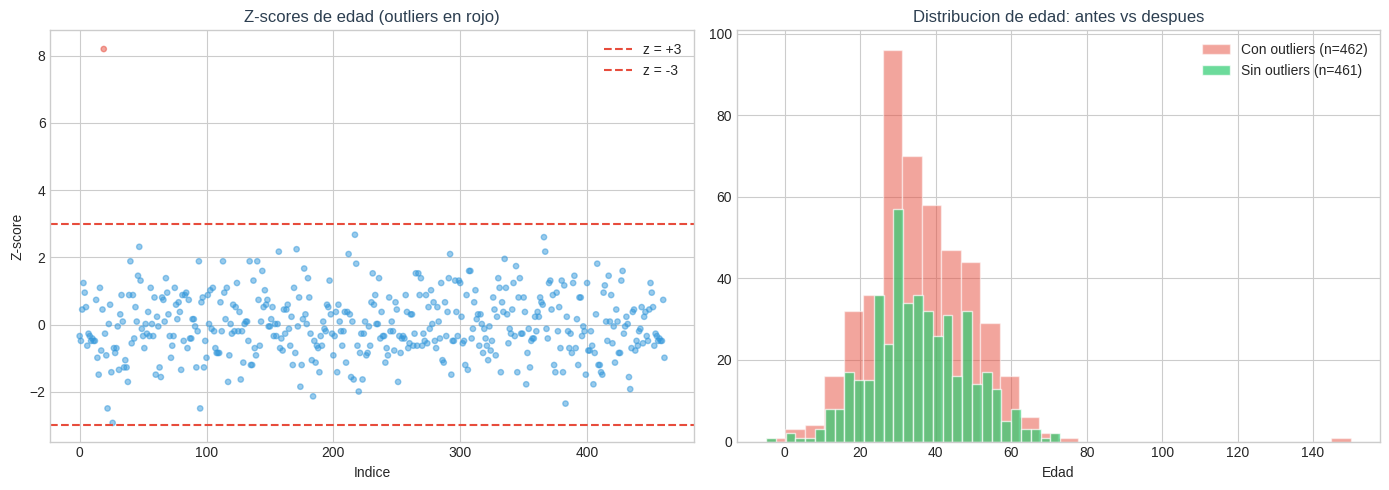

In [16]:
# --- Ejercicio 15: Outliers en edad con Z-score ---

edad = df_dirty['edad'].dropna()
z_scores = (edad - edad.mean()) / edad.std()

outliers_z = np.abs(z_scores) > 3
n_out = outliers_z.sum()

print(f"Media de edad: {edad.mean():.2f}")
print(f"Desviacion estandar: {edad.std():.2f}")
print(f"Outliers detectados (|z| > 3): {n_out}")
print(f"\nDetalle de outliers:")
for idx in edad[outliers_z].index:
    print(f"  Indice {idx}: edad={edad[idx]:.0f}, z-score={z_scores[idx]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter de Z-scores
colors_z = [C_DANGER if abs(z) > 3 else C_PRIMARY for z in z_scores]
axes[0].scatter(range(len(z_scores)), z_scores.values, c=colors_z, alpha=0.5, s=15)
axes[0].axhline(y=3, color=C_DANGER, linestyle='--', label='z = +3')
axes[0].axhline(y=-3, color=C_DANGER, linestyle='--', label='z = -3')
axes[0].set_xlabel('Indice')
axes[0].set_ylabel('Z-score')
axes[0].set_title('Z-scores de edad (outliers en rojo)', fontsize=12, color=C_DARK)
axes[0].legend()

# Histograma antes vs despues
axes[1].hist(edad, bins=30, color=C_DANGER, alpha=0.5, label=f'Con outliers (n={len(edad)})', edgecolor='white')
axes[1].hist(edad[~outliers_z], bins=30, color=C_SUCCESS, alpha=0.7, label=f'Sin outliers (n={len(edad)-n_out})', edgecolor='white')
axes[1].set_xlabel('Edad')
axes[1].set_title('Distribucion de edad: antes vs despues', fontsize=12, color=C_DARK)
axes[1].legend()

plt.tight_layout()
plt.show()

**Ejercicio 16:** Comparar dos estrategias para tratar outliers en `salario`: (a) winsorizar al percentil 1-99 (recortar los extremos) y (b) eliminar los outliers. Visualizar las distribuciones resultantes de ambos metodos lado a lado.

**Resolucion:**

1. **Winsorizar:** Recorta los valores extremos al percentil especificado. `scipy.stats.mstats.winsorize(data, limits=[0.01, 0.01])` recorta el 1% inferior y superior.
   - Los valores por debajo del percentil 1 se reemplazan por el valor del percentil 1.
   - Los valores por encima del percentil 99 se reemplazan por el valor del percentil 99.
   - Ventaja: no se pierden filas, se preserva el tamano del dataset.
2. **Eliminar:** Se calculan los limites con IQR y se descartan las filas fuera del rango.
   - Ventaja: no se distorsionan los valores.
   - Desventaja: se pierden observaciones.
3. Se comparan ambas estrategias visualmente para decidir cual es mas apropiada segun el contexto.

Original:     n=482, media=42939, std=36333
Winsorizado:  n=482, media=41305, std=21465
Eliminados:   n=462, media=38451, std=16832


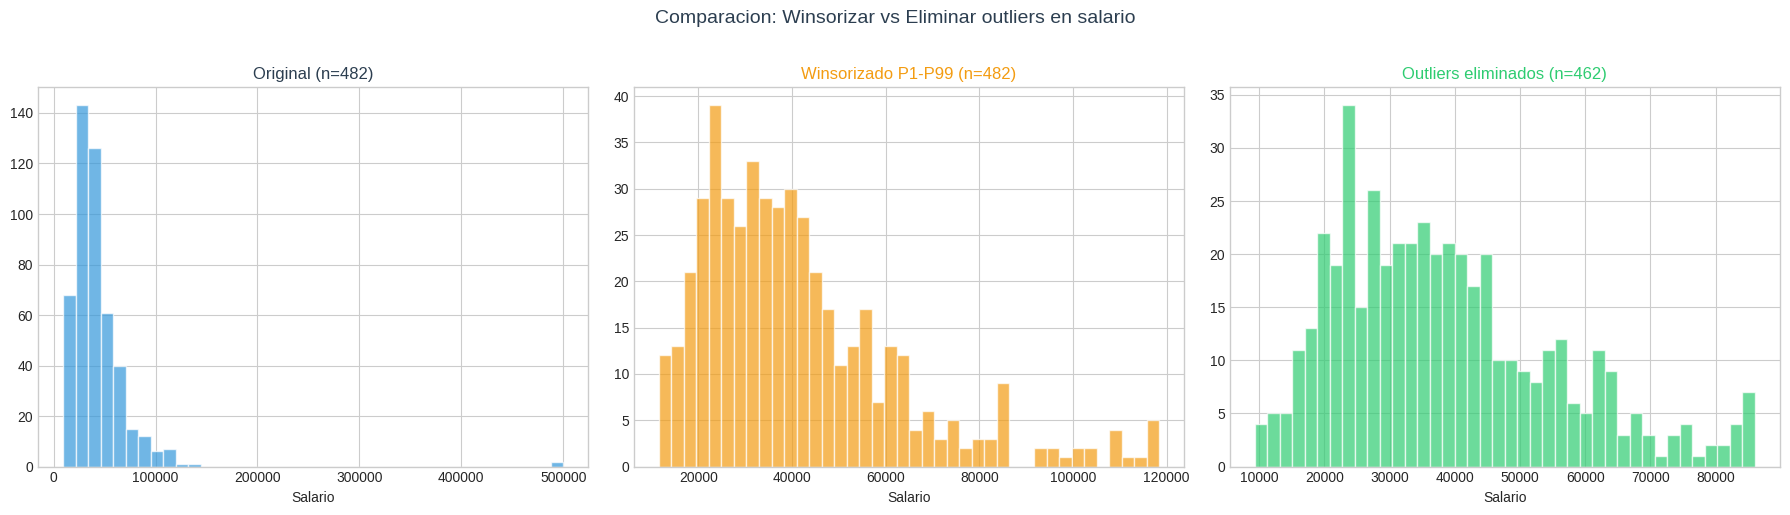

In [17]:
# --- Ejercicio 16: Winsorizar vs Eliminar outliers en salario ---

from scipy.stats.mstats import winsorize

salario = df_dirty['salario'].dropna()

# Metodo A: Winsorizar al percentil 1-99
salario_wins = pd.Series(winsorize(salario, limits=[0.01, 0.01]))

# Metodo B: Eliminar con IQR
Q1 = salario.quantile(0.25)
Q3 = salario.quantile(0.75)
IQR = Q3 - Q1
mask_ok = (salario >= Q1 - 1.5 * IQR) & (salario <= Q3 + 1.5 * IQR)
salario_elim = salario[mask_ok]

print(f"Original:     n={len(salario)}, media={salario.mean():.0f}, std={salario.std():.0f}")
print(f"Winsorizado:  n={len(salario_wins)}, media={salario_wins.mean():.0f}, std={salario_wins.std():.0f}")
print(f"Eliminados:   n={len(salario_elim)}, media={salario_elim.mean():.0f}, std={salario_elim.std():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(salario, bins=40, color=C_PRIMARY, alpha=0.7, edgecolor='white')
axes[0].set_title(f'Original (n={len(salario)})', fontsize=12, color=C_DARK)
axes[0].set_xlabel('Salario')

axes[1].hist(salario_wins, bins=40, color=C_ORANGE, alpha=0.7, edgecolor='white')
axes[1].set_title(f'Winsorizado P1-P99 (n={len(salario_wins)})', fontsize=12, color=C_ORANGE)
axes[1].set_xlabel('Salario')

axes[2].hist(salario_elim, bins=40, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[2].set_title(f'Outliers eliminados (n={len(salario_elim)})', fontsize=12, color=C_SUCCESS)
axes[2].set_xlabel('Salario')

plt.suptitle('Comparacion: Winsorizar vs Eliminar outliers en salario', fontsize=14, color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

**Ejercicio 17:** Utilizar Isolation Forest de scikit-learn para detectar anomalias multivariantes en las columnas `['edad', 'salario', 'evaluacion']`. Visualizar los puntos anomalos en un scatter plot de edad vs salario, coloreando diferente los puntos normales y los anomalos.

**Resolucion:**

1. **Isolation Forest:** Algoritmo basado en arboles que aisle puntos anomalos. La idea es que los outliers requieren menos particiones (cortes) para ser aislados del resto.
2. Parametros principales:
   - `contamination`: proporcion esperada de outliers en el dataset (ej: 0.05 = 5%).
   - `n_estimators`: numero de arboles (default=100).
   - `random_state`: semilla para reproducibilidad.
3. `model.fit_predict(X)` devuelve 1 para puntos normales y -1 para anomalias.
4. A diferencia de IQR y Z-score (univariantes), Isolation Forest detecta anomalias **multivariantes**: un punto puede tener edad y salario normales por separado, pero su combinacion ser anomala.
5. Se requiere eliminar NaN antes de usar Isolation Forest.

Puntos analizados: 404
Anomalias detectadas: 21 (5.2%)


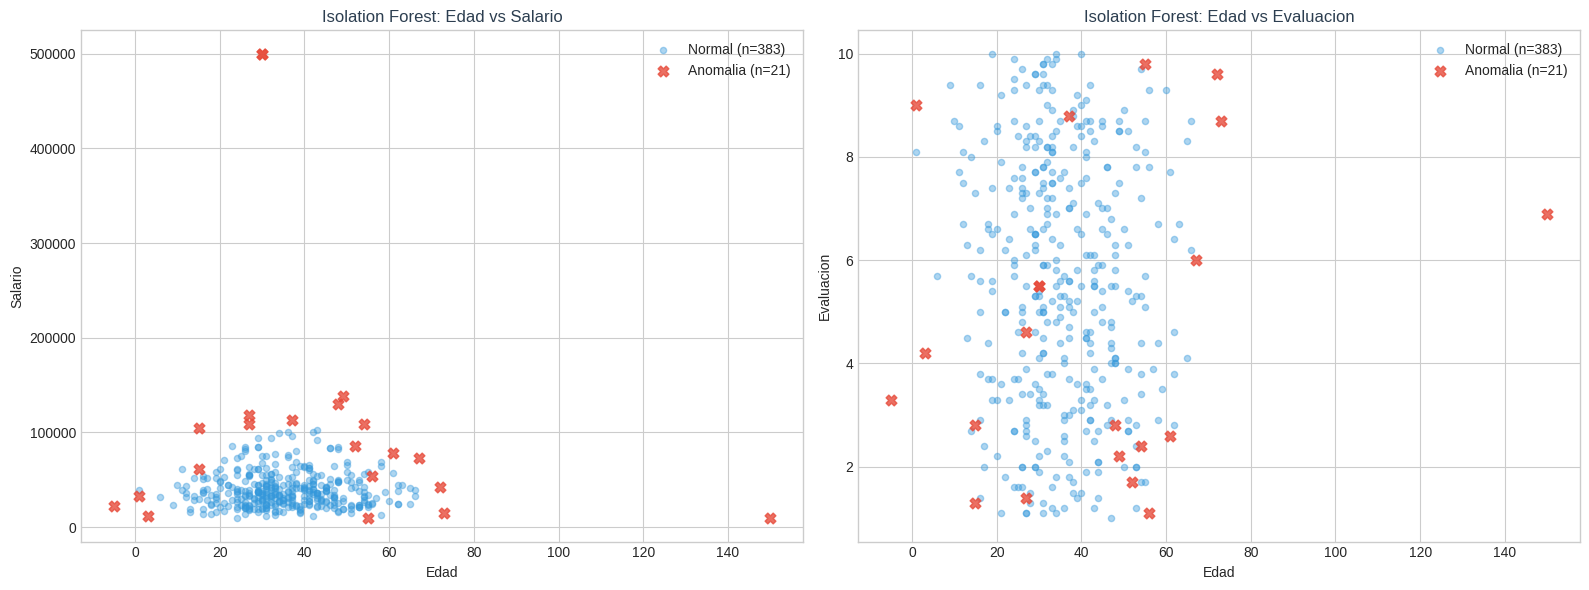


Muestra de puntos anomalos:


,edad,salario,evaluacion,anomalia
10,30.0,500000.000000,5.5,-1
20,150.0,9348.267862,6.9,-1
30,-5.0,22538.249579,3.3,-1
107,1.0,32772.986178,9.0,-1
191,67.0,73559.853560,6.0,-1
245,73.0,15138.721268,8.7,-1
255,37.0,113450.778427,8.8,-1
259,27.0,118404.136165,1.4,-1
297,27.0,109048.617107,4.6,-1
307,48.0,129756.726375,2.8,-1


In [18]:
# --- Ejercicio 17: Isolation Forest ---

cols_if = ['edad', 'salario', 'evaluacion']
df_if = df_dirty[cols_if].dropna().copy()

iso_forest = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
df_if['anomalia'] = iso_forest.fit_predict(df_if[cols_if])

n_anomalias = (df_if['anomalia'] == -1).sum()
print(f"Puntos analizados: {len(df_if)}")
print(f"Anomalias detectadas: {n_anomalias} ({n_anomalias/len(df_if)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter edad vs salario
normales = df_if[df_if['anomalia'] == 1]
anomalos = df_if[df_if['anomalia'] == -1]

axes[0].scatter(normales['edad'], normales['salario'], c=C_PRIMARY, alpha=0.4, s=20, label=f'Normal (n={len(normales)})')
axes[0].scatter(anomalos['edad'], anomalos['salario'], c=C_DANGER, alpha=0.8, s=60, marker='X', label=f'Anomalia (n={len(anomalos)})')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Salario')
axes[0].set_title('Isolation Forest: Edad vs Salario', fontsize=12, color=C_DARK)
axes[0].legend()

# Scatter edad vs evaluacion
axes[1].scatter(normales['edad'], normales['evaluacion'], c=C_PRIMARY, alpha=0.4, s=20, label=f'Normal (n={len(normales)})')
axes[1].scatter(anomalos['edad'], anomalos['evaluacion'], c=C_DANGER, alpha=0.8, s=60, marker='X', label=f'Anomalia (n={len(anomalos)})')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Evaluacion')
axes[1].set_title('Isolation Forest: Edad vs Evaluacion', fontsize=12, color=C_DARK)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nMuestra de puntos anomalos:")
display(anomalos.head(10))

**Ejercicio 18:** Crear una columna con valores monetarios en formato string como "$1,234.56" y "$45,678.90". Limpiar estos strings eliminando el simbolo "$" y las comas, y convertir el resultado a tipo float. Mostrar la columna antes y despues de la conversion.

**Resolucion:**

1. Los valores monetarios como "$1,234.56" son strings que no se pueden usar directamente en calculos numericos.
2. **Paso 1:** Eliminar el simbolo "$" con `str.replace('$', '', regex=False)`.
3. **Paso 2:** Eliminar las comas con `str.replace(',', '', regex=False)`.
4. **Paso 3:** Convertir a float con `.astype(float)` o `pd.to_numeric()`.
5. Alternativa en un solo paso con regex: `str.replace(r'[\$,]', '', regex=True).astype(float)`.
6. Se verifica que el dtype cambie de `object` a `float64` y que los valores sean correctos.

ANTES:
Tipo: object


,precio_original
0,"$32,773.36"
1,"$19,720.00"
2,"$36,980.68"
3,"$74,490.28"
4,"$18,263.82"
5,"$18,264.06"
6,"$77,914.73"
7,"$40,698.55"
8,"$15,129.78"
9,"$33,997.70"



DESPUES:
Tipo: float64


,precio_original,precio_limpio
0,"$32,773.36",32773.36
1,"$19,720.00",19720.00
2,"$36,980.68",36980.68
3,"$74,490.28",74490.28
4,"$18,263.82",18263.82
5,"$18,264.06",18264.06
6,"$77,914.73",77914.73
7,"$40,698.55",40698.55
8,"$15,129.78",15129.78
9,"$33,997.70",33997.70


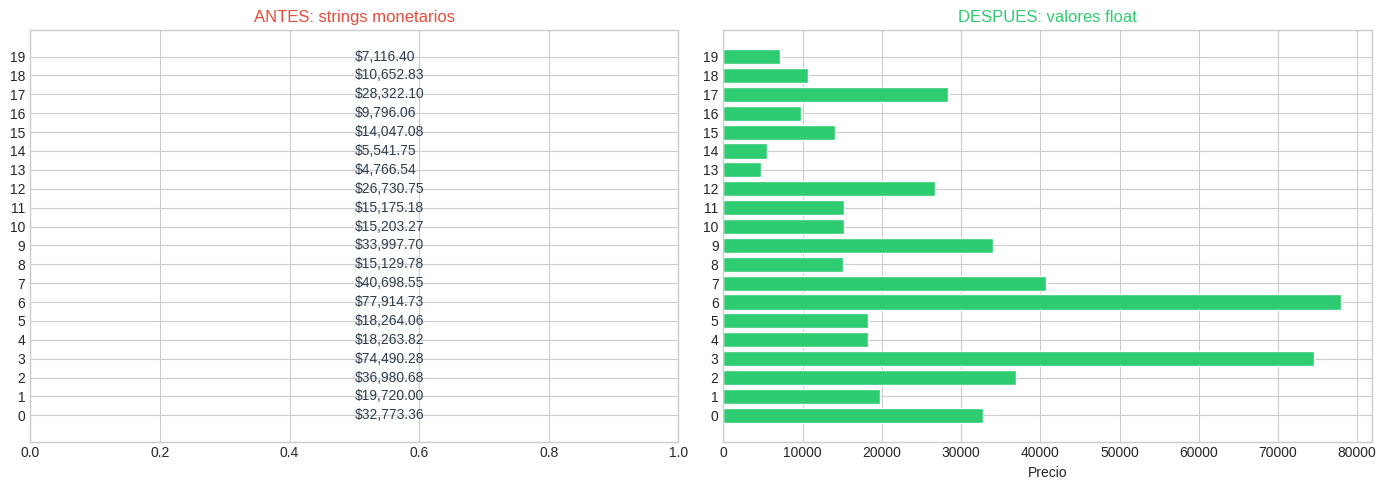

In [19]:
# --- Ejercicio 18: Limpiar columna "$1,234.56" y convertir a float ---

# Crear columna con formato monetario
np.random.seed(42)
precios_str = [f"${v:,.2f}" for v in np.random.lognormal(10, 0.8, 20)]
df_precios = pd.DataFrame({'precio_original': precios_str})

print("ANTES:")
print(f"Tipo: {df_precios['precio_original'].dtype}")
display(df_precios.head(10))

# Limpiar y convertir
df_precios['precio_limpio'] = (df_precios['precio_original']
                                .str.replace(r'[\$,]', '', regex=True)
                                .astype(float))

print("\nDESPUES:")
print(f"Tipo: {df_precios['precio_limpio'].dtype}")
display(df_precios.head(10))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(len(df_precios)), [0]*len(df_precios), color=C_PRIMARY)
for i, txt in enumerate(df_precios['precio_original']):
    axes[0].text(0.5, i, txt, va='center', fontsize=10, color=C_DARK)
axes[0].set_yticks(range(len(df_precios)))
axes[0].set_title('ANTES: strings monetarios', fontsize=12, color=C_DANGER)
axes[0].set_xlim(0, 1)

axes[1].barh(range(len(df_precios)), df_precios['precio_limpio'], color=C_SUCCESS, edgecolor='white')
axes[1].set_yticks(range(len(df_precios)))
axes[1].set_title('DESPUES: valores float', fontsize=12, color=C_SUCCESS)
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()

**Ejercicio 19:** Parsear la columna `fecha_ingreso` que contiene formatos mixtos: algunas fechas estan en formato "YYYY-MM-DD" y otras en "DD/MM/YYYY". Convertir todas a tipo datetime. Mostrar los valores antes y despues de la conversion, incluyendo los que no se pudieron parsear.

**Resolucion:**

1. `pd.to_datetime()` es la funcion principal para convertir strings a datetime.
2. Con formatos mixtos, se puede intentar el parseo automatico con `pd.to_datetime(col, infer_datetime_format=True, errors='coerce')`. El parametro `errors='coerce'` convierte los valores que no se pueden parsear en NaT (Not a Time).
3. Para mayor control, se aplica una funcion personalizada que intenta primero un formato y luego el otro:
   - Intentar `pd.to_datetime(x, format='%Y-%m-%d')` para "YYYY-MM-DD".
   - Si falla, intentar `pd.to_datetime(x, format='%d/%m/%Y')` para "DD/MM/YYYY".
4. Se verifica que el dtype resultante sea `datetime64[ns]`.
5. Se extraen componentes utiles: anno, mes, dia de la semana, con `.dt.year`, `.dt.month`, `.dt.dayofweek`.

Tipo ANTES: object
Tipo DESPUES: datetime64[ns]
NaT (no parseadas): 28

Muestra de conversion:


,original,parseada
0,2020-01-18,2020-01-18
1,2020-04-21,2020-04-21
2,2020-04-01,2020-04-01
3,2020-10-26,2020-10-26
4,2020-04-23,2020-04-23
5,2020-11-09,2020-11-09
7,2020-02-24,2020-02-24
8,2020-04-05,2020-04-05
9,2020-08-19,2020-08-19
10,2020-12-26,2020-12-26


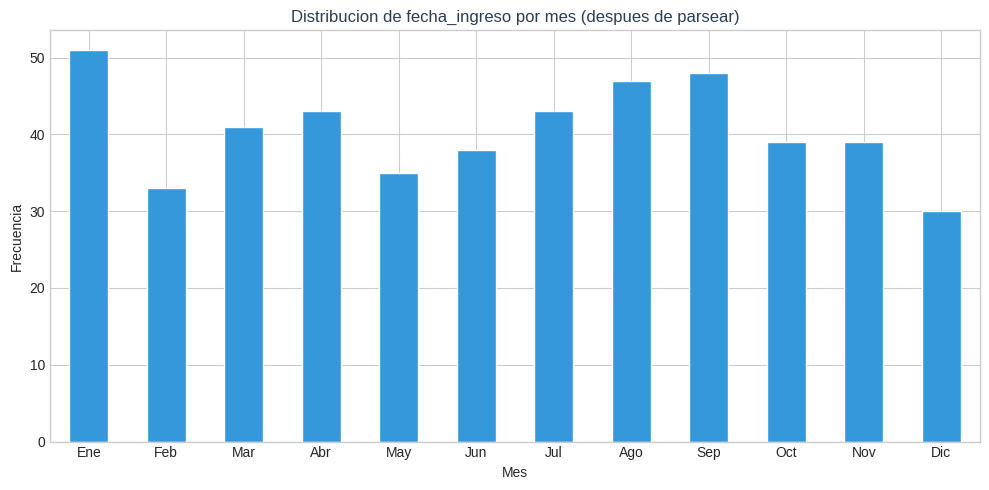

In [20]:
# --- Ejercicio 19: Parsear fecha_ingreso con formatos mixtos ---

def parsear_fecha(x):
    """Intenta parsear una fecha en formato YYYY-MM-DD o DD/MM/YYYY."""
    if pd.isna(x):
        return pd.NaT
    for fmt in ['%Y-%m-%d', '%d/%m/%Y']:
        try:
            return pd.to_datetime(x, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

fechas_antes = df_dirty['fecha_ingreso'].copy()
fechas_despues = df_dirty['fecha_ingreso'].apply(parsear_fecha)

print(f"Tipo ANTES: {fechas_antes.dtype}")
print(f"Tipo DESPUES: {fechas_despues.dtype}")
print(f"NaT (no parseadas): {fechas_despues.isna().sum()}")

# Muestra comparativa
comparacion = pd.DataFrame({
    'original': fechas_antes,
    'parseada': fechas_despues
})
print("\nMuestra de conversion:")
display(comparacion.dropna(subset=['original']).head(15))

# Visualizacion: distribucion por mes
fig, ax = plt.subplots(figsize=(10, 5))
meses = fechas_despues.dt.month.dropna().astype(int)
meses.value_counts().sort_index().plot(kind='bar', ax=ax, color=C_PRIMARY, edgecolor='white')
ax.set_xlabel('Mes')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de fecha_ingreso por mes (despues de parsear)', fontsize=12, color=C_DARK)
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
plt.tight_layout()
plt.show()

**Ejercicio 20:** Validar los datos de `df_dirty` aplicando las siguientes reglas: edad debe estar en el rango [18, 70], salario debe ser mayor que 0, y evaluacion debe estar en el rango [1, 10]. Crear una columna `valido` que indique si la fila cumple todas las reglas. Mostrar el conteo de filas validas e invalidas.

**Resolucion:**

1. Se definen las reglas de validacion como expresiones booleanas:
   - `edad_ok`: `df['edad'].between(18, 70)` -- True si la edad esta entre 18 y 70 (inclusive). Los NaN devuelven False.
   - `salario_ok`: `df['salario'] > 0` -- True si el salario es positivo.
   - `eval_ok`: `df['evaluacion'].between(1, 10)` -- True si la evaluacion esta entre 1 y 10.
2. La columna `valido` es la conjuncion (AND) de todas las reglas: `edad_ok & salario_ok & eval_ok`.
3. Las filas con NaN en cualquiera de estas columnas se consideran invalidas automaticamente (NaN no cumple ninguna condicion).
4. Se muestran las filas invalidas para inspeccionar que regla violan.

Filas validas: 371 (72.0%)
Filas invalidas: 144 (28.0%)

Desglose de violaciones:
  Edad fuera de [18, 70]: 91
  Salario <= 0 o NaN:    33
  Evaluacion fuera [1,10]: 33

Muestra de filas invalidas:


,id,edad,salario,evaluacion,edad_ok,salario_ok,eval_ok
11,12,29.0,23678.784153,NaN,True,True,False
15,16,NaN,40080.700374,6.3,False,True,True
16,17,15.0,29563.315003,7.3,False,True,True
18,19,25.0,25702.442737,NaN,True,True,False
20,21,150.0,9348.267862,6.9,False,True,True
21,22,NaN,24349.116231,4.7,False,True,True
23,24,23.0,42872.499710,NaN,True,True,False
24,25,NaN,28470.436035,4.6,False,True,True
25,26,1.0,38984.428789,8.1,False,True,True
28,29,NaN,35352.618620,9.6,False,True,True


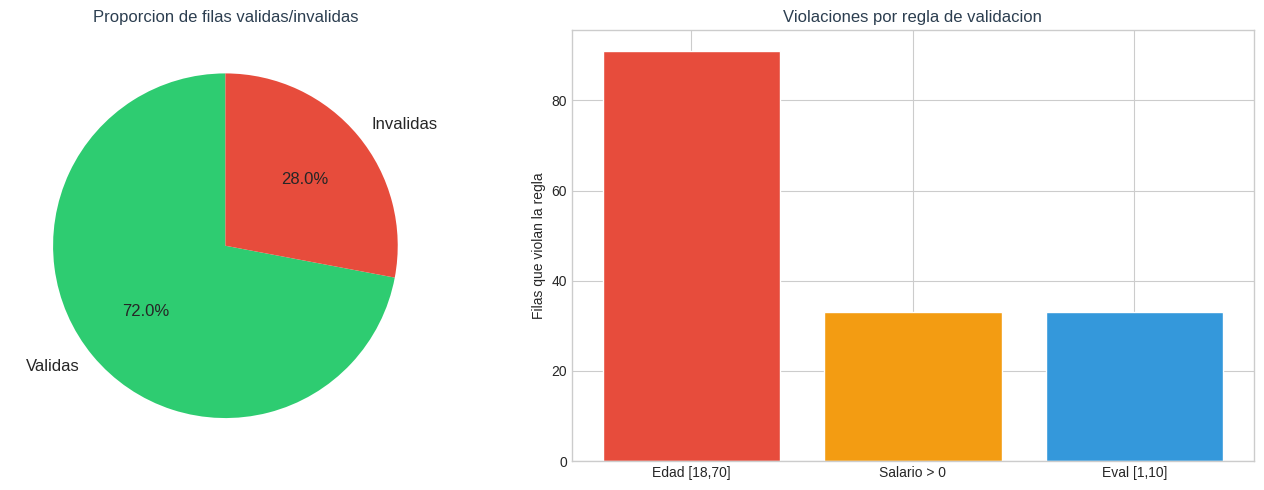

In [21]:
# --- Ejercicio 20: Validacion de rangos ---

df_val = df_dirty.copy()

# Reglas de validacion
df_val['edad_ok'] = df_val['edad'].between(18, 70)
df_val['salario_ok'] = df_val['salario'] > 0
df_val['eval_ok'] = df_val['evaluacion'].between(1, 10)
df_val['valido'] = df_val['edad_ok'] & df_val['salario_ok'] & df_val['eval_ok']

n_validos = df_val['valido'].sum()
n_invalidos = (~df_val['valido']).sum()

print(f"Filas validas: {n_validos} ({n_validos/len(df_val)*100:.1f}%)")
print(f"Filas invalidas: {n_invalidos} ({n_invalidos/len(df_val)*100:.1f}%)")

# Desglose por regla
print(f"\nDesglose de violaciones:")
print(f"  Edad fuera de [18, 70]: {(~df_val['edad_ok']).sum()}")
print(f"  Salario <= 0 o NaN:    {(~df_val['salario_ok']).sum()}")
print(f"  Evaluacion fuera [1,10]: {(~df_val['eval_ok']).sum()}")

print("\nMuestra de filas invalidas:")
display(df_val[~df_val['valido']][['id', 'edad', 'salario', 'evaluacion', 'edad_ok', 'salario_ok', 'eval_ok']].head(10))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie([n_validos, n_invalidos], labels=['Validas', 'Invalidas'],
            colors=[C_SUCCESS, C_DANGER], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Proporcion de filas validas/invalidas', fontsize=12, color=C_DARK)

# Barplot por regla
reglas = ['edad_ok', 'salario_ok', 'eval_ok']
violaciones = [(~df_val[r]).sum() for r in reglas]
axes[1].bar(['Edad [18,70]', 'Salario > 0', 'Eval [1,10]'], violaciones,
            color=[C_DANGER, C_ORANGE, C_PRIMARY], edgecolor='white')
axes[1].set_ylabel('Filas que violan la regla')
axes[1].set_title('Violaciones por regla de validacion', fontsize=12, color=C_DARK)

plt.tight_layout()
plt.show()

del df_val

**Ejercicio 21:** Normalizar la columna `nombre` de `df_dirty` aplicando: (1) eliminar espacios al inicio y final (strip), (2) convertir a title case (primera letra de cada palabra en mayuscula), (3) reemplazar multiples espacios consecutivos por uno solo. Mostrar los valores unicos antes y despues.

**Resolucion:**

1. `str.strip()`: elimina espacios en blanco (y otros caracteres de espacio) al inicio y al final del string. Ejemplo: "  pedro martinez  " -> "pedro martinez".
2. `str.title()`: convierte la primera letra de cada palabra a mayuscula y el resto a minuscula. Ejemplo: "MARIA LOPEZ" -> "Maria Lopez".
3. `str.replace(r'\s+', ' ', regex=True)`: usa una expresion regular para reemplazar cualquier secuencia de uno o mas espacios (`\s+`) por un unico espacio.
4. El orden importa: primero strip (quitar extremos), luego replace (limpiar internos), luego title (normalizar case).
5. Se compara `nunique()` antes y despues para verificar que variantes como "MARIA LOPEZ", "  pedro martinez  " y "pedro Martinez" se unifican.

ANTES - Valores unicos:
['  pedro martinez  ', 'Ana Torres', 'Juan Garcia', 'LUIS sanchez', 'MARIA LOPEZ', 'pedro Martinez']
Total unicos: 6

DESPUES - Valores unicos:
['Ana Torres', 'Juan Garcia', 'Luis Sanchez', 'Maria Lopez', 'Pedro Martinez']
Total unicos: 5


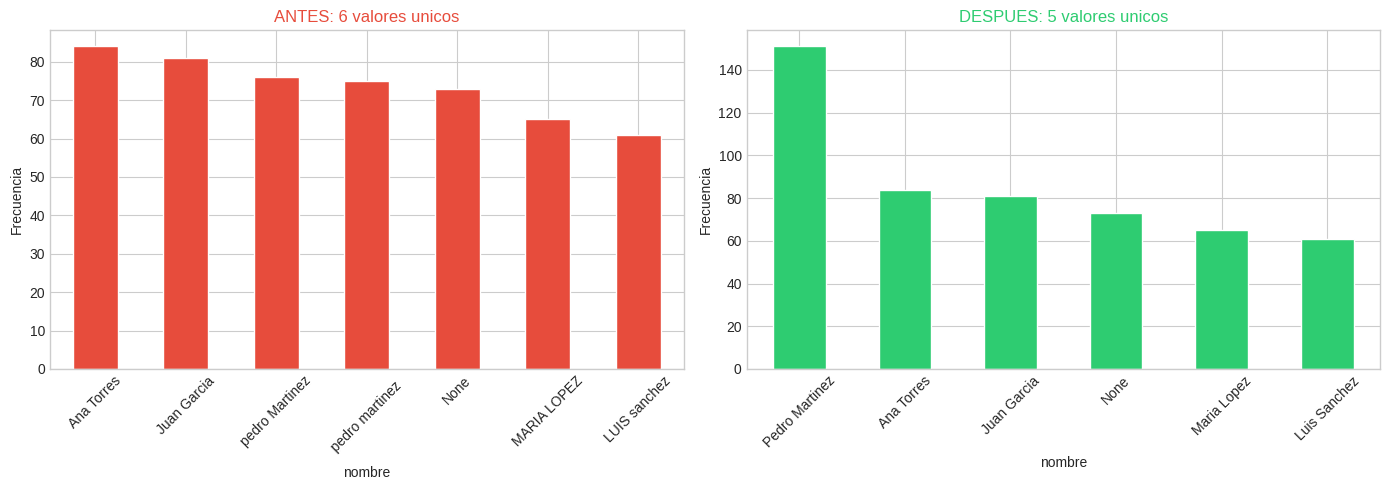

In [22]:
# --- Ejercicio 21: Normalizar nombre ---

nombre_antes = df_dirty['nombre'].copy()
nombre_despues = (df_dirty['nombre']
                  .str.strip()
                  .str.replace(r'\s+', ' ', regex=True)
                  .str.title())

print("ANTES - Valores unicos:")
print(sorted(nombre_antes.dropna().unique()))
print(f"Total unicos: {nombre_antes.nunique()}")

print(f"\nDESPUES - Valores unicos:")
print(sorted(nombre_despues.dropna().unique()))
print(f"Total unicos: {nombre_despues.nunique()}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombre_antes.value_counts(dropna=False).plot(kind='bar', ax=axes[0], color=C_DANGER, edgecolor='white')
axes[0].set_title(f'ANTES: {nombre_antes.nunique()} valores unicos', fontsize=12, color=C_DANGER)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Frecuencia')

nombre_despues.value_counts(dropna=False).plot(kind='bar', ax=axes[1], color=C_SUCCESS, edgecolor='white')
axes[1].set_title(f'DESPUES: {nombre_despues.nunique()} valores unicos', fontsize=12, color=C_SUCCESS)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Ejercicio 22:** Crear una columna de emails ficticios basados en los nombres de `df_dirty` (ej: "juan.garcia@empresa.com") y extraer el dominio de cada email utilizando expresiones regulares (regex).

**Resolucion:**

1. Se generan emails ficticios combinando el nombre normalizado con dominios aleatorios.
2. `str.extract(r'@(.+)')` usa una expresion regular para capturar todo lo que viene despues del "@":
   - `@`: coincide con el caracter "@" literal.
   - `(.+)`: grupo de captura que atrapa uno o mas caracteres despues del "@".
3. Alternativa: `str.split('@').str[1]` divide por "@" y toma la segunda parte.
4. Las expresiones regulares son una herramienta fundamental para extraer patrones de texto en limpieza de datos.

Muestra de emails y dominios extraidos:


,nombre,email,dominio
0,pedro Martinez,pedro.martinez@outlook.com,outlook.com
1,Ana Torres,ana.torres@trabajo.org,trabajo.org
2,LUIS sanchez,luis.sanchez@gmail.com,gmail.com
3,pedro Martinez,pedro.martinez@trabajo.org,trabajo.org
4,pedro martinez,pedro.martinez@trabajo.org,trabajo.org
5,LUIS sanchez,luis.sanchez@corp.es,corp.es
6,LUIS sanchez,luis.sanchez@gmail.com,gmail.com
7,pedro Martinez,pedro.martinez@gmail.com,gmail.com
8,MARIA LOPEZ,maria.lopez@gmail.com,gmail.com
9,pedro martinez,pedro.martinez@trabajo.org,trabajo.org


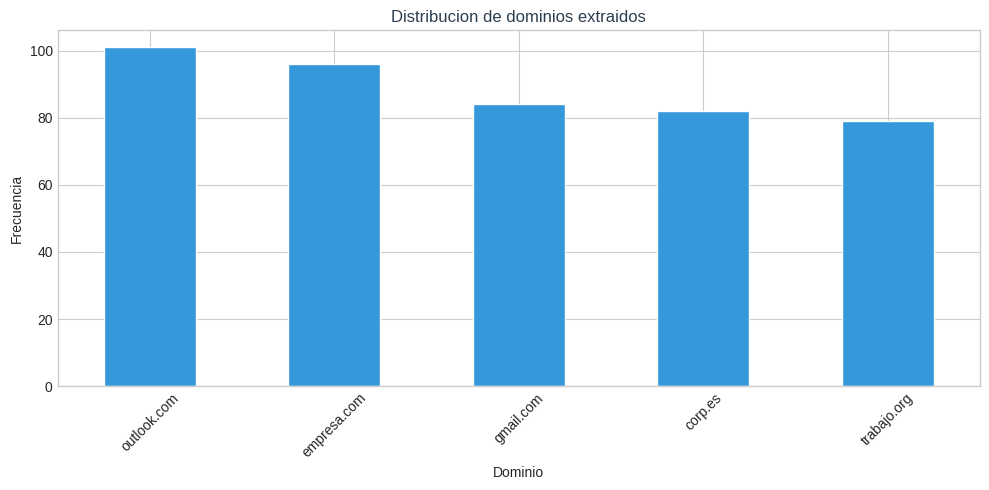

In [23]:
# --- Ejercicio 22: Extraer dominio de emails con regex ---

np.random.seed(42)
dominios = ['empresa.com', 'corp.es', 'gmail.com', 'outlook.com', 'trabajo.org']

# Generar emails ficticios
nombre_norm = (df_dirty['nombre']
               .str.strip()
               .str.lower()
               .str.replace(r'\s+', '.', regex=True))

df_temp = pd.DataFrame({'nombre': df_dirty['nombre']})
df_temp['email'] = nombre_norm + '@' + np.random.choice(dominios, len(df_dirty))
df_temp.loc[df_dirty['nombre'].isna(), 'email'] = np.nan

# Extraer dominio con regex
df_temp['dominio'] = df_temp['email'].str.extract(r'@(.+)')

print("Muestra de emails y dominios extraidos:")
display(df_temp.dropna().head(10))

# Visualizacion
fig, ax = plt.subplots(figsize=(10, 5))
df_temp['dominio'].value_counts().plot(kind='bar', ax=ax, color=C_PRIMARY, edgecolor='white')
ax.set_title('Distribucion de dominios extraidos', fontsize=12, color=C_DARK)
ax.set_xlabel('Dominio')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

del df_temp

**Ejercicio 23:** Estandarizar la columna `departamento` de `df_dirty`: convertir todo a title case y corregir las inconsistencias (Ventas, ventas, VENTAS deben ser todas "Ventas"). Mostrar los valores unicos antes y despues, y la distribucion resultante.

**Resolucion:**

1. `str.strip()`: elimina espacios al inicio y final.
2. `str.title()`: convierte a Title Case. Ejemplo: "ventas" -> "Ventas", "VENTAS" -> "Ventas", "it" -> "It".
3. Para casos especiales como "IT" (que title case convertiria a "It"), se puede usar un diccionario de mapeo: `df['col'].replace({'It': 'IT', 'Rrhh': 'RRHH'})`.
4. Se verifica con `value_counts()` que todas las variantes se hayan unificado correctamente.
5. La estandarizacion de categorias es esencial antes de aplicar encoding o agrupaciones.

ANTES - Valores unicos:
['IT', 'Marketing', 'RRHH', 'VENTAS', 'Ventas', 'it', 'ventas']
Total unicos: 7

DESPUES - Valores unicos:
['IT', 'Marketing', 'RRHH', 'Ventas']
Total unicos: 4


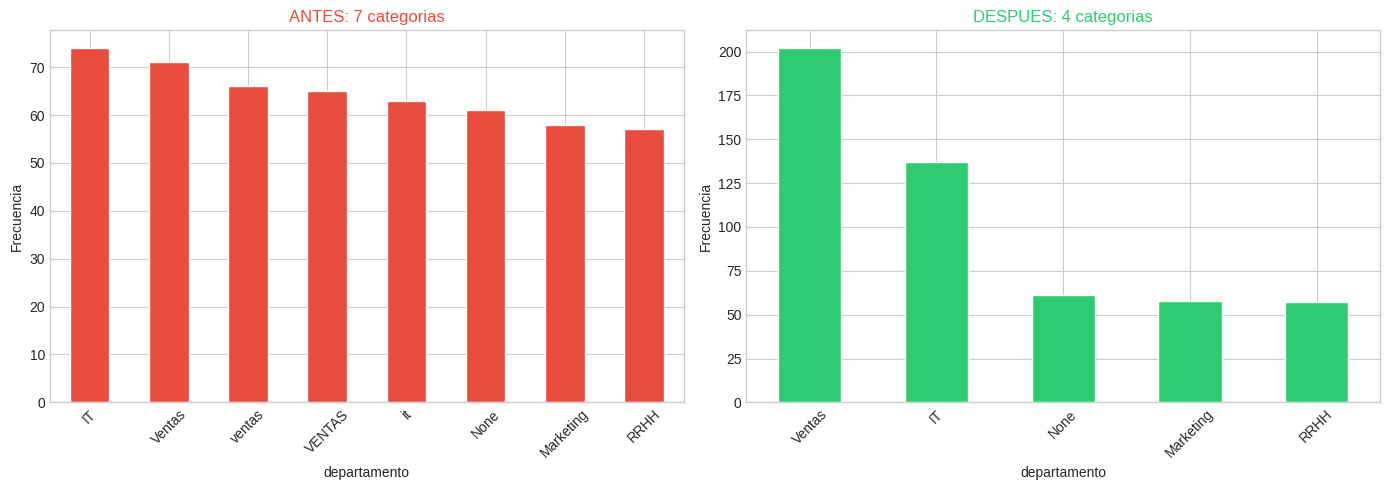

In [24]:
# --- Ejercicio 23: Estandarizar departamento ---

depto_antes = df_dirty['departamento'].copy()
depto_despues = (df_dirty['departamento']
                 .str.strip()
                 .str.title()
                 .replace({'It': 'IT', 'Rrhh': 'RRHH'}))

print("ANTES - Valores unicos:")
print(sorted(depto_antes.dropna().unique()))
print(f"Total unicos: {depto_antes.nunique()}")

print(f"\nDESPUES - Valores unicos:")
print(sorted(depto_despues.dropna().unique()))
print(f"Total unicos: {depto_despues.nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depto_antes.value_counts(dropna=False).plot(kind='bar', ax=axes[0], color=C_DANGER, edgecolor='white')
axes[0].set_title(f'ANTES: {depto_antes.nunique()} categorias', fontsize=12, color=C_DANGER)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Frecuencia')

depto_despues.value_counts(dropna=False).plot(kind='bar', ax=axes[1], color=C_SUCCESS, edgecolor='white')
axes[1].set_title(f'DESPUES: {depto_despues.nunique()} categorias', fontsize=12, color=C_SUCCESS)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Ejercicio 24:** Aplicar One-Hot Encoding a la columna `ciudad` (previamente normalizada a title case). Usar `pd.get_dummies()` con `drop_first=True` para evitar la trampa de variables dummy. Mostrar las primeras filas del resultado y explicar por que se elimina una columna.

**Resolucion:**

1. **One-Hot Encoding:** Crea una columna binaria (0/1) por cada categoria unica. Si `ciudad` tiene 4 valores unicos (Madrid, Barcelona, Sevilla, Valencia), se crean 4 columnas.
2. **Trampa de variables dummy (dummy trap):** Si se incluyen todas las columnas dummy, se genera multicolinealidad perfecta (la suma de todas las dummies siempre es 1). Esto causa problemas en modelos lineales.
3. `drop_first=True`: elimina la primera categoria (que se convierte en la "referencia"). Si todas las dummies son 0, la observacion pertenece a la categoria eliminada.
4. `pd.get_dummies(df, columns=['ciudad'], drop_first=True)` aplica el encoding directamente sobre el DataFrame.
5. Alternativa con sklearn: `OneHotEncoder(drop='first', sparse_output=False)`.

ANTES - Valores unicos de ciudad:
ciudad
Barcelona    176
Madrid       168
Sevilla       86
Valencia      85

One-Hot SIN drop_first (4 columnas):


,ciudad_Barcelona,ciudad_Madrid,ciudad_Sevilla,ciudad_Valencia
0,False,False,True,False
1,False,True,False,False
2,False,False,False,True
3,True,False,False,False
4,False,False,False,True
5,False,False,False,True
6,True,False,False,False
7,True,False,False,False



One-Hot CON drop_first (3 columnas):


,ciudad_Madrid,ciudad_Sevilla,ciudad_Valencia
0,False,True,False
1,True,False,False
2,False,False,True
3,False,False,False
4,False,False,True
5,False,False,True
6,False,False,False
7,False,False,False


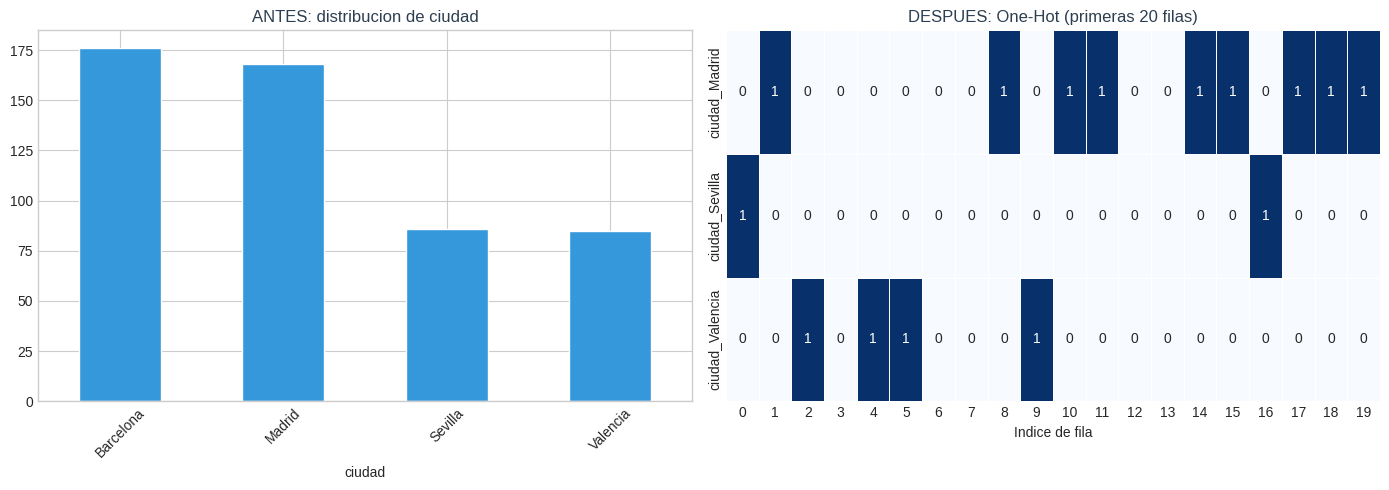

In [25]:
# --- Ejercicio 24: One-Hot Encoding de ciudad ---

ciudad_norm = df_dirty['ciudad'].str.strip().str.title()

print("ANTES - Valores unicos de ciudad:")
print(ciudad_norm.value_counts().to_string())

# Sin drop_first
dummies_full = pd.get_dummies(ciudad_norm, prefix='ciudad')
print(f"\nOne-Hot SIN drop_first ({dummies_full.shape[1]} columnas):")
display(dummies_full.head(8))

# Con drop_first
dummies_drop = pd.get_dummies(ciudad_norm, prefix='ciudad', drop_first=True)
print(f"\nOne-Hot CON drop_first ({dummies_drop.shape[1]} columnas):")
display(dummies_drop.head(8))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes: distribucion de ciudad
ciudad_norm.value_counts().plot(kind='bar', ax=axes[0], color=C_PRIMARY, edgecolor='white')
axes[0].set_title('ANTES: distribucion de ciudad', fontsize=12, color=C_DARK)
axes[0].tick_params(axis='x', rotation=45)

# Despues: heatmap de dummies
sns.heatmap(dummies_drop.head(20).T, cmap='Blues', cbar=False, ax=axes[1],
            linewidths=0.5, annot=True, fmt='d')
axes[1].set_title('DESPUES: One-Hot (primeras 20 filas)', fontsize=12, color=C_DARK)
axes[1].set_xlabel('Indice de fila')

plt.tight_layout()
plt.show()

**Ejercicio 25:** Aplicar Ordinal Encoding a la columna `satisfaccion` con el orden logico: bajo=1, medio=2, alto=3. Primero normalizar los valores (strip, lower) para unificar variantes. Mostrar el mapeo y la distribucion resultante.

**Resolucion:**

1. **Ordinal Encoding:** Asigna un entero a cada categoria respetando un orden logico. A diferencia de Label Encoding (orden arbitrario), aqui el orden tiene significado: bajo < medio < alto.
2. Primero se normaliza: `str.strip().str.lower()` para unificar "bajo", "Bajo", "ALTO" en "bajo", "alto".
3. Se define el mapeo manualmente: `{'bajo': 1, 'medio': 2, 'alto': 3}`.
4. Se aplica con `df['col'].map(mapeo)`.
5. Alternativa con sklearn: `OrdinalEncoder(categories=[['bajo', 'medio', 'alto']])`.
6. Los valores NaN se mantienen como NaN tras el mapeo (no aparecen en el diccionario).

ANTES - Valores unicos:
satisfaccion
bajo     175
alto     172
None      91
medio     77

Mapeo aplicado: {'bajo': 1, 'medio': 2, 'alto': 3}

DESPUES - Valores unicos:
satisfaccion
1.0    175
3.0    172
NaN     91
2.0     77


,original,normalizado,encoded
0,None,None,NaN
1,ALTO,alto,3.0
2,Bajo,bajo,1.0
3,ALTO,alto,3.0
4,None,None,NaN
5,None,None,NaN
6,medio,medio,2.0
7,ALTO,alto,3.0
8,Bajo,bajo,1.0
9,Bajo,bajo,1.0


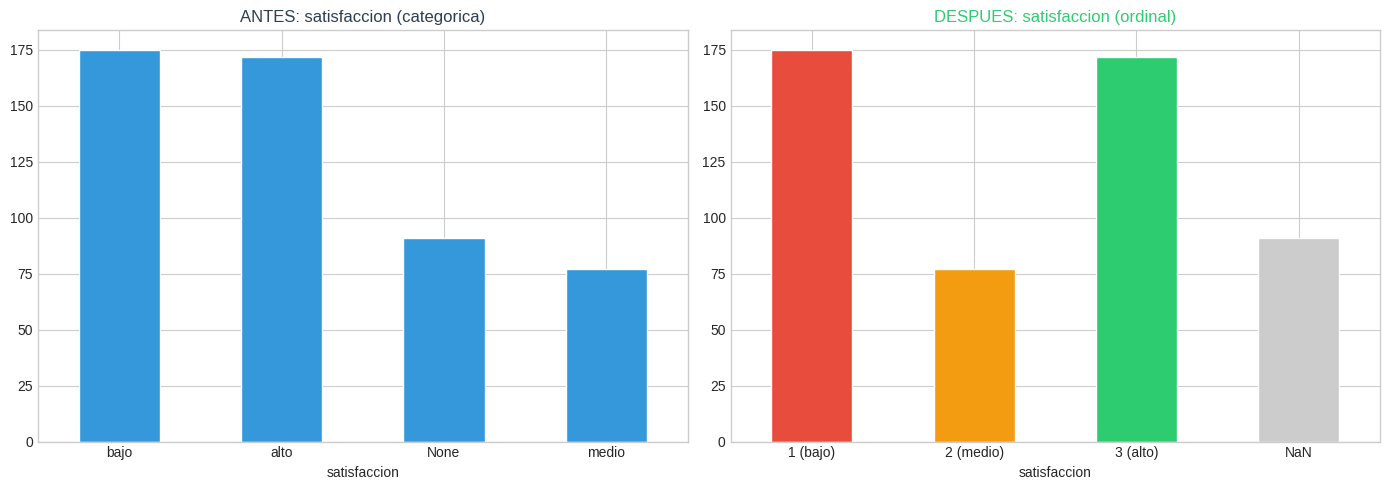

In [26]:
# --- Ejercicio 25: Ordinal Encoding de satisfaccion ---

satis_norm = df_dirty['satisfaccion'].str.strip().str.lower()

print("ANTES - Valores unicos:")
print(satis_norm.value_counts(dropna=False).to_string())

# Mapeo ordinal
mapeo_ordinal = {'bajo': 1, 'medio': 2, 'alto': 3}
satis_encoded = satis_norm.map(mapeo_ordinal)

print(f"\nMapeo aplicado: {mapeo_ordinal}")
print(f"\nDESPUES - Valores unicos:")
print(satis_encoded.value_counts(dropna=False).to_string())

# Muestra
muestra = pd.DataFrame({
    'original': df_dirty['satisfaccion'],
    'normalizado': satis_norm,
    'encoded': satis_encoded
})
display(muestra.head(10))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

satis_norm.value_counts(dropna=False).plot(kind='bar', ax=axes[0], color=C_PRIMARY, edgecolor='white')
axes[0].set_title('ANTES: satisfaccion (categorica)', fontsize=12, color=C_DARK)
axes[0].tick_params(axis='x', rotation=0)

satis_encoded.value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[1],
    color=[C_DANGER, C_ORANGE, C_SUCCESS, '#cccccc'], edgecolor='white')
axes[1].set_title('DESPUES: satisfaccion (ordinal)', fontsize=12, color=C_SUCCESS)
axes[1].set_xticklabels(['1 (bajo)', '2 (medio)', '3 (alto)', 'NaN'], rotation=0)

plt.tight_layout()
plt.show()

**Ejercicio 26:** Aplicar Target Encoding a la columna `departamento` usando la media de `evaluacion` por departamento. Es decir, reemplazar cada valor de departamento por la media de evaluacion de ese departamento. Normalizar departamento antes de aplicar el encoding.

**Resolucion:**

1. **Target Encoding:** Reemplaza cada categoria por la media de la variable objetivo (target) para esa categoria. Es una forma de encoding que captura la relacion entre la variable categorica y el target.
2. Se calcula la media de `evaluacion` agrupada por `departamento` normalizado: `df.groupby('depto_norm')['evaluacion'].mean()`.
3. Se crea un diccionario de mapeo con esas medias y se aplica con `df['depto_norm'].map(mapeo)`.
4. **Riesgo de data leakage:** En produccion, el target encoding debe calcularse solo sobre el conjunto de entrenamiento y aplicarse al de test. Calcularlo sobre todo el dataset introduce fuga de informacion.
5. Para mitigar el overfitting, se pueden usar tecnicas como leave-one-out encoding o agregar ruido (smoothing).

Media de evaluacion por departamento:
depto_norm
IT           5.827
Marketing    5.366
RRHH         5.345
Ventas       5.397

Muestra del resultado:


,departamento,evaluacion,depto_norm,depto_target_enc
0,VENTAS,5.0,Ventas,5.396774
1,RRHH,5.3,RRHH,5.344643
2,None,2.9,None,NaN
3,ventas,2.0,Ventas,5.396774
4,IT,8.5,IT,5.827344
5,RRHH,5.5,RRHH,5.344643
6,RRHH,1.1,RRHH,5.344643
7,Marketing,8.2,Marketing,5.366071
8,ventas,9.8,Ventas,5.396774
9,ventas,6.5,Ventas,5.396774


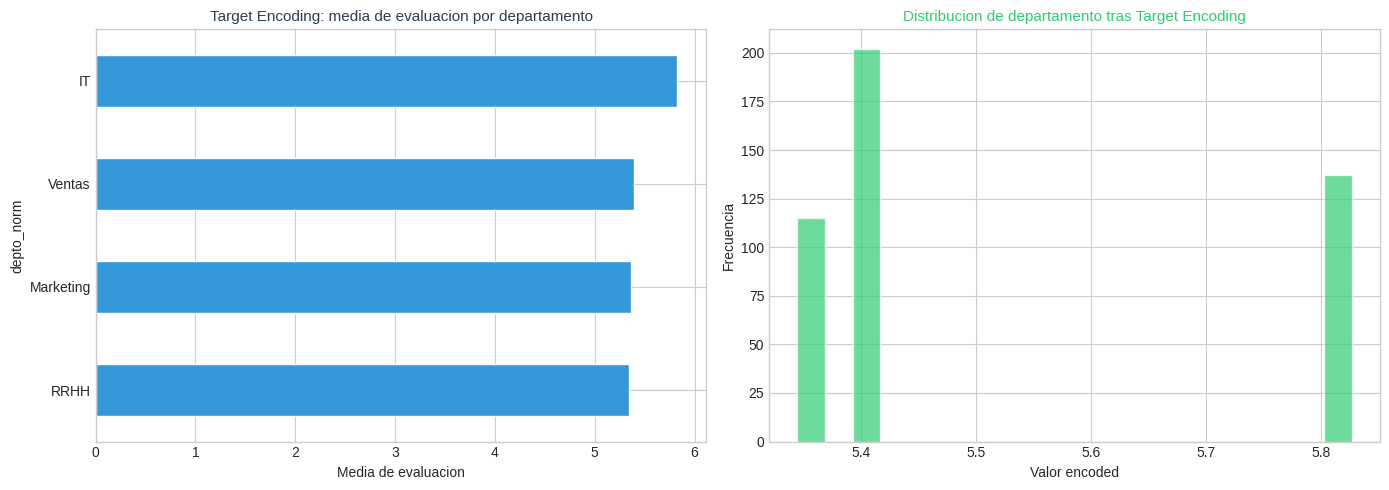

In [27]:
# --- Ejercicio 26: Target Encoding de departamento ---

df_temp = df_dirty[['departamento', 'evaluacion']].copy()
df_temp['depto_norm'] = df_temp['departamento'].str.strip().str.title().replace({'It': 'IT', 'Rrhh': 'RRHH'})

# Calcular media de evaluacion por departamento
target_map = df_temp.groupby('depto_norm')['evaluacion'].mean()
print("Media de evaluacion por departamento:")
print(target_map.round(3).to_string())

# Aplicar target encoding
df_temp['depto_target_enc'] = df_temp['depto_norm'].map(target_map)

print(f"\nMuestra del resultado:")
display(df_temp.head(10))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_map.sort_values().plot(kind='barh', ax=axes[0], color=C_PRIMARY, edgecolor='white')
axes[0].set_xlabel('Media de evaluacion')
axes[0].set_title('Target Encoding: media de evaluacion por departamento', fontsize=11, color=C_DARK)

axes[1].hist(df_temp['depto_target_enc'].dropna(), bins=20, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Valor encoded')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de departamento tras Target Encoding', fontsize=11, color=C_SUCCESS)

plt.tight_layout()
plt.show()

del df_temp

**Ejercicio 27:** Comparar tres metodos de escalado en la columna `salario` (con outliers): MinMaxScaler, StandardScaler y RobustScaler. Mostrar tres histogramas lado a lado con las distribuciones resultantes y discutir cual es mas apropiado en presencia de outliers.

**Resolucion:**

1. **MinMaxScaler:** `x_scaled = (x - x_min) / (x_max - x_min)`. Escala al rango [0, 1]. Un outlier extremo comprime todos los demas valores cerca de 0.
2. **StandardScaler:** `x_scaled = (x - media) / std`. Centra en 0 con desviacion 1. Los outliers afectan la media y la desviacion, distorsionando el escalado.
3. **RobustScaler:** `x_scaled = (x - mediana) / IQR`. Usa mediana e IQR en lugar de media y std. Es robusto a outliers porque estas estadisticas no se ven afectadas por valores extremos.
4. Se aplica cada scaler con `.fit_transform(X)` donde X es un array 2D.
5. **Conclusion:** Con outliers, RobustScaler es la opcion mas segura. MinMaxScaler es el mas afectado.

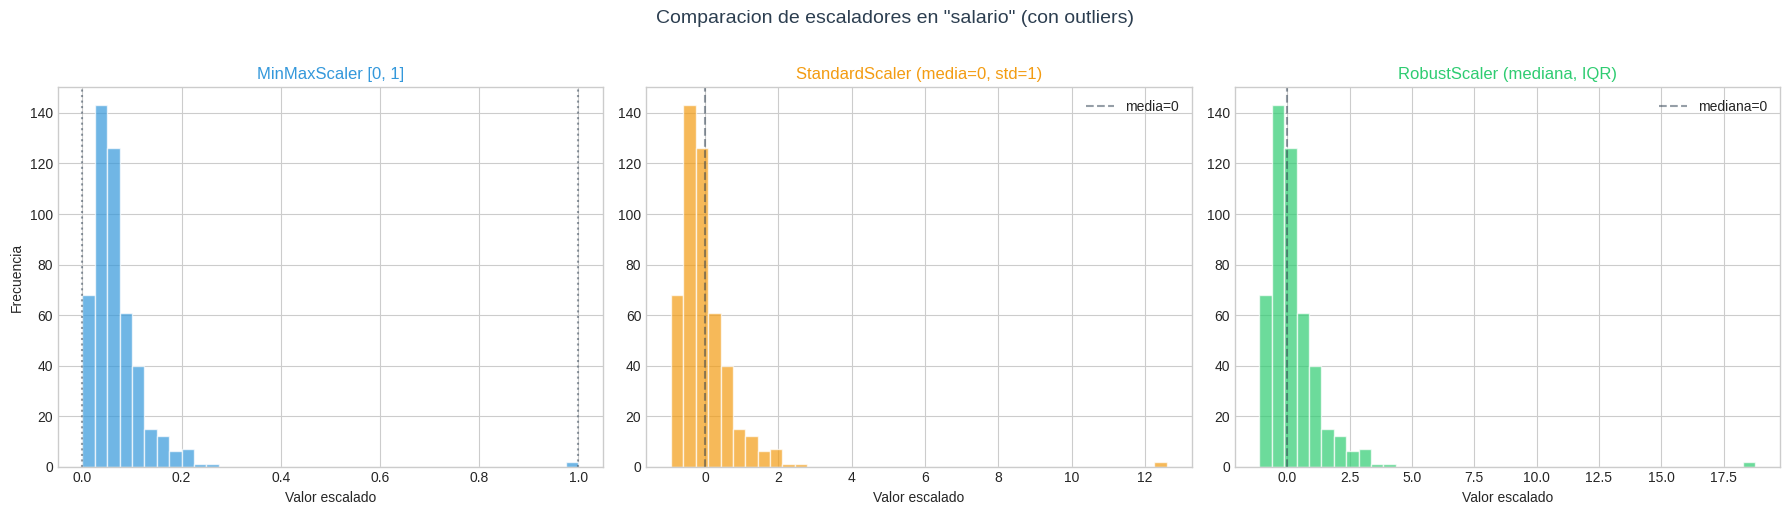


--- Estadisticas de cada escalado ---
  MinMax    : min=0.000, max=1.000, media=0.068, std=0.074
  Standard  : min=-0.925, max=12.593, media=-0.000, std=1.000
  Robust    : min=-1.113, max=18.765, media=0.248, std=1.470


In [28]:
# --- Ejercicio 27: Comparar MinMax vs Standard vs Robust en salario ---

salario = df_dirty['salario'].dropna().values.reshape(-1, 1)

scaler_mm = MinMaxScaler()
scaler_ss = StandardScaler()
scaler_rb = RobustScaler()

sal_minmax = scaler_mm.fit_transform(salario).flatten()
sal_standard = scaler_ss.fit_transform(salario).flatten()
sal_robust = scaler_rb.fit_transform(salario).flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sal_minmax, bins=40, color=C_PRIMARY, alpha=0.7, edgecolor='white')
axes[0].set_title('MinMaxScaler [0, 1]', fontsize=12, color=C_PRIMARY)
axes[0].set_xlabel('Valor escalado')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(0, color=C_DARK, linestyle=':', alpha=0.5)
axes[0].axvline(1, color=C_DARK, linestyle=':', alpha=0.5)

axes[1].hist(sal_standard, bins=40, color=C_ORANGE, alpha=0.7, edgecolor='white')
axes[1].set_title('StandardScaler (media=0, std=1)', fontsize=12, color=C_ORANGE)
axes[1].set_xlabel('Valor escalado')
axes[1].axvline(0, color=C_DARK, linestyle='--', alpha=0.5, label='media=0')
axes[1].legend()

axes[2].hist(sal_robust, bins=40, color=C_SUCCESS, alpha=0.7, edgecolor='white')
axes[2].set_title('RobustScaler (mediana, IQR)', fontsize=12, color=C_SUCCESS)
axes[2].set_xlabel('Valor escalado')
axes[2].axvline(0, color=C_DARK, linestyle='--', alpha=0.5, label='mediana=0')
axes[2].legend()

plt.suptitle('Comparacion de escaladores en "salario" (con outliers)', fontsize=14, color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

# Estadisticas
print("\n--- Estadisticas de cada escalado ---")
for nombre, datos in [('MinMax', sal_minmax), ('Standard', sal_standard), ('Robust', sal_robust)]:
    print(f"  {nombre:10s}: min={datos.min():.3f}, max={datos.max():.3f}, media={datos.mean():.3f}, std={datos.std():.3f}")

**Ejercicio 28:** Usar `ColumnTransformer` de scikit-learn para aplicar transformaciones diferentes a columnas numericas y categoricas simultaneamente: escalar las numericas (`edad`, `salario`, `evaluacion`) con StandardScaler y aplicar One-Hot Encoding a las categoricas (`departamento`, `ciudad`). Primero preparar los datos eliminando NaN.

**Resolucion:**

1. **ColumnTransformer:** Permite aplicar diferentes transformadores a diferentes subconjuntos de columnas en un solo paso.
2. Se define como una lista de tuplas `(nombre, transformador, columnas)`:
   - `('num', StandardScaler(), cols_numericas)`: escala las columnas numericas.
   - `('cat', OneHotEncoder(drop='first', sparse_output=False), cols_categoricas)`: aplica one-hot a las categoricas.
3. `ct.fit_transform(X)` aplica todas las transformaciones y devuelve un array con las columnas transformadas concatenadas.
4. `ct.get_feature_names_out()` devuelve los nombres de las columnas resultantes.
5. Se preparan los datos eliminando filas con NaN en las columnas relevantes (o imputando previamente).
6. El resultado es una matriz lista para alimentar un modelo de ML.

Shape tras eliminar NaN: (353, 5)
Columnas numericas: ['edad', 'salario', 'evaluacion']
Columnas categoricas: ['departamento', 'ciudad']

Shape resultante: (353, 9)
Columnas: ['num__edad', 'num__salario', 'num__evaluacion', 'cat__departamento_Marketing', 'cat__departamento_RRHH', 'cat__departamento_Ventas', 'cat__ciudad_Madrid', 'cat__ciudad_Sevilla', 'cat__ciudad_Valencia']


,num__edad,num__salario,num__evaluacion,cat__departamento_Marketing,cat__departamento_RRHH,cat__departamento_Ventas,cat__ciudad_Madrid,cat__ciudad_Sevilla,cat__ciudad_Valencia
0,-0.379896,-0.842842,-0.219530,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.527832,0.949987,-0.098948,0.0,1.0,0.0,1.0,0.0,0.0
2,1.247392,-0.932604,-1.425352,0.0,0.0,1.0,0.0,0.0,0.0
3,0.951522,-1.046507,1.187262,0.0,0.0,0.0,0.0,0.0,1.0
4,0.507716,-0.239852,-0.018560,0.0,1.0,0.0,0.0,0.0,1.0
5,-0.675767,0.668688,-1.787099,0.0,1.0,0.0,0.0,0.0,0.0
6,-0.305929,0.702023,1.066680,1.0,0.0,0.0,0.0,0.0,0.0
7,-0.379896,0.102922,1.709785,0.0,0.0,1.0,1.0,0.0,0.0
8,-0.527832,-0.184897,0.383381,0.0,0.0,1.0,0.0,0.0,1.0
9,-0.527832,2.012063,1.629397,0.0,1.0,0.0,0.0,0.0,0.0


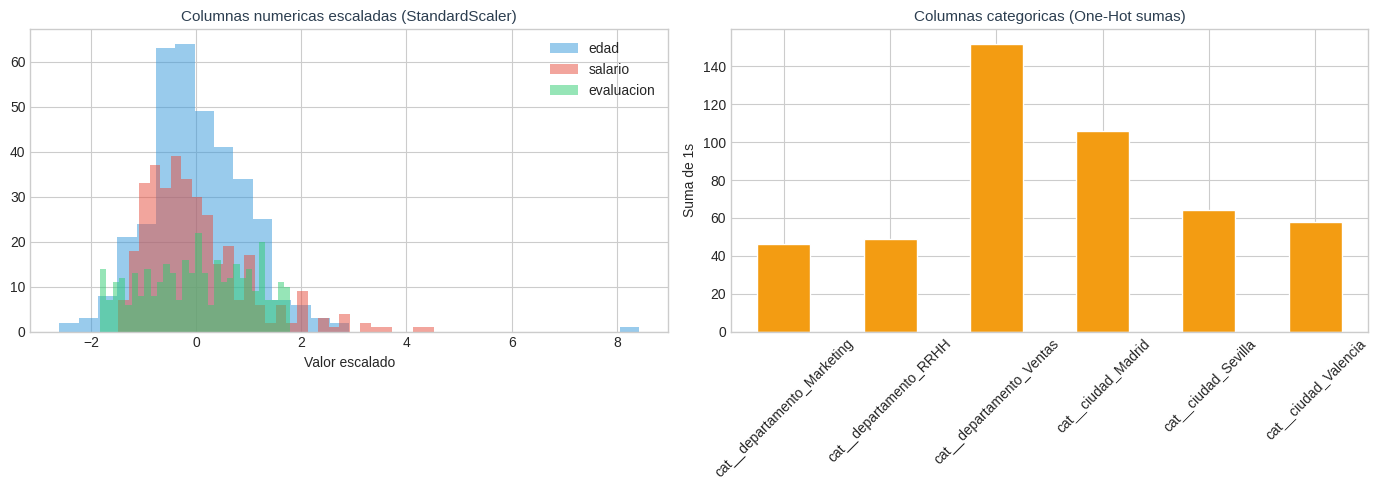

In [29]:
# --- Ejercicio 28: ColumnTransformer ---

# Preparar datos: normalizar categoricas y eliminar NaN
df_ct = df_dirty.copy()
df_ct['departamento'] = df_ct['departamento'].str.strip().str.title().replace({'It': 'IT', 'Rrhh': 'RRHH'})
df_ct['ciudad'] = df_ct['ciudad'].str.strip().str.title()

cols_num = ['edad', 'salario', 'evaluacion']
cols_cat = ['departamento', 'ciudad']
df_ct = df_ct[cols_num + cols_cat].dropna()

print(f"Shape tras eliminar NaN: {df_ct.shape}")
print(f"Columnas numericas: {cols_num}")
print(f"Columnas categoricas: {cols_cat}")

# Definir ColumnTransformer
ct = ColumnTransformer([
    ('num', StandardScaler(), cols_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cols_cat)
])

# Aplicar
X_transformed = ct.fit_transform(df_ct)
feature_names = ct.get_feature_names_out()

df_result = pd.DataFrame(X_transformed, columns=feature_names)
print(f"\nShape resultante: {df_result.shape}")
print(f"Columnas: {list(feature_names)}")

display(df_result.head(10))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numericas escaladas
for i, col in enumerate(cols_num):
    axes[0].hist(df_result[f'num__{col}'], bins=30, alpha=0.5,
                 label=col, color=[C_PRIMARY, C_DANGER, C_SUCCESS][i])
axes[0].set_title('Columnas numericas escaladas (StandardScaler)', fontsize=11, color=C_DARK)
axes[0].legend()
axes[0].set_xlabel('Valor escalado')

# Categoricas one-hot
cat_cols = [c for c in feature_names if c.startswith('cat__')]
cat_sums = df_result[cat_cols].sum()
cat_sums.plot(kind='bar', ax=axes[1], color=C_ORANGE, edgecolor='white')
axes[1].set_title('Columnas categoricas (One-Hot sumas)', fontsize=11, color=C_DARK)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Suma de 1s')

plt.tight_layout()
plt.show()

del df_ct

**Ejercicio 29:** Construir un pipeline completo con scikit-learn que aplique: para columnas numericas, `SimpleImputer(strategy='median')` seguido de `StandardScaler`; para columnas categoricas, `SimpleImputer(strategy='most_frequent')` seguido de `OneHotEncoder`. Combinar ambos con `ColumnTransformer` y aplicar a `df_dirty`.

**Resolucion:**

1. **Pipeline:** Encadena transformadores en secuencia. Cada paso recibe la salida del anterior.
   - `Pipeline([('imputer', SimpleImputer(...)), ('scaler', StandardScaler())])`.
2. **Pipeline numerico:** `SimpleImputer(strategy='median')` rellena NaN con la mediana, luego `StandardScaler()` escala a media=0, std=1.
3. **Pipeline categorico:** `SimpleImputer(strategy='most_frequent')` rellena NaN con la moda, luego `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` codifica las categorias.
4. **ColumnTransformer:** Combina ambos pipelines, aplicando cada uno a su subconjunto de columnas.
5. El resultado es un array numpy limpio, sin NaN, con todas las columnas transformadas y listo para un modelo.
6. Ventaja: todo el preprocesamiento queda encapsulado en un solo objeto reproducible.

Shape original: (515, 6)
Shape transformado: (515, 13)
NaN en resultado: 0

Columnas resultantes (13):
['num__edad', 'num__salario', 'num__evaluacion', 'cat__departamento_Marketing', 'cat__departamento_RRHH', 'cat__departamento_Ventas', 'cat__departamento_None', 'cat__ciudad_Madrid', 'cat__ciudad_Sevilla', 'cat__ciudad_Valencia', 'cat__satisfaccion_bajo', 'cat__satisfaccion_medio', 'cat__satisfaccion_None']


,num__edad,num__salario,num__evaluacion,cat__departamento_Marketing,cat__departamento_RRHH,cat__departamento_Ventas,cat__departamento_None,cat__ciudad_Madrid,cat__ciudad_Sevilla,cat__ciudad_Valencia,cat__satisfaccion_bajo,cat__satisfaccion_medio,cat__satisfaccion_None
0,-0.348108,-0.554092,-0.208508,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.499716,0.541958,-0.084128,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.485733,0.087099,-1.079171,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.319574,-0.608968,-1.452313,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.016359,-0.678603,1.242597,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5,0.561536,-0.185453,-0.001208,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,-0.651323,0.369986,-1.825454,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,-0.272305,0.390365,1.118216,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,-0.348108,0.024103,1.781579,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9,-0.499716,-0.151855,0.413394,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


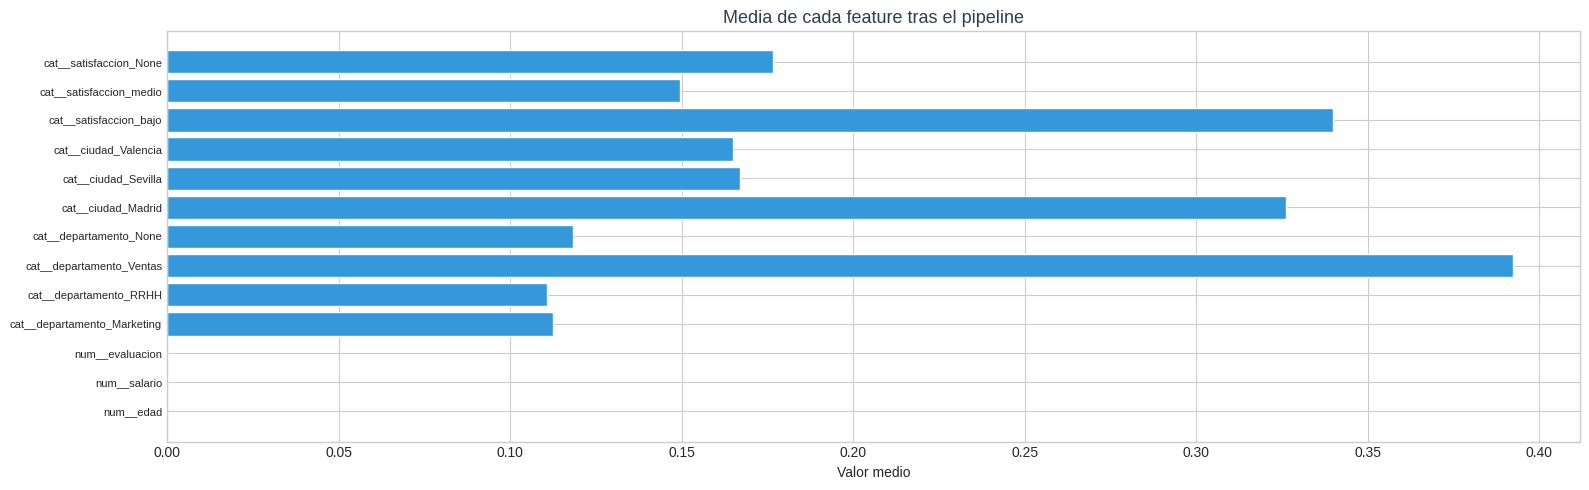

In [30]:
# --- Ejercicio 29: Pipeline completo con ColumnTransformer ---

# Normalizar categoricas primero
df_pipe = df_dirty.copy()
df_pipe['departamento'] = df_pipe['departamento'].str.strip().str.title().replace({'It': 'IT', 'Rrhh': 'RRHH'})
df_pipe['ciudad'] = df_pipe['ciudad'].str.strip().str.title()
df_pipe['satisfaccion'] = df_pipe['satisfaccion'].str.strip().str.lower()

cols_num = ['edad', 'salario', 'evaluacion']
cols_cat = ['departamento', 'ciudad', 'satisfaccion']

# Pipeline numerico
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categorico
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])

# Aplicar
X = df_pipe[cols_num + cols_cat]
X_transformed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

df_result = pd.DataFrame(X_transformed, columns=feature_names)

print(f"Shape original: {X.shape}")
print(f"Shape transformado: {df_result.shape}")
print(f"NaN en resultado: {df_result.isnull().sum().sum()}")
print(f"\nColumnas resultantes ({len(feature_names)}):")
print(list(feature_names))

display(df_result.head(10))

# Visualizacion
fig, ax = plt.subplots(figsize=(16, 5))
ax.barh(range(len(feature_names)), df_result.mean().values, color=C_PRIMARY, edgecolor='white')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, fontsize=8)
ax.set_xlabel('Valor medio')
ax.set_title('Media de cada feature tras el pipeline', fontsize=13, color=C_DARK)
plt.tight_layout()
plt.show()

del df_pipe

**Ejercicio 30:** Limpieza end-to-end. Tomar `df_dirty` original y producir `df_clean` listo para modelo, aplicando TODOS los pasos anteriores en secuencia: (1) eliminar duplicados, (2) normalizar strings, (3) parsear fechas, (4) validar rangos y marcar invalidos, (5) tratar outliers con IQR, (6) imputar nulos, (7) encoding categorico, (8) escalar numericas. Mostrar un resumen comparativo del dataset antes y despues.

**Resolucion:**

El pipeline end-to-end aplica cada tecnica aprendida en orden logico:

1. **Duplicados:** `drop_duplicates()` elimina filas identicas. Se hace primero para no procesar datos redundantes.
2. **Strings:** Normalizar `nombre`, `departamento`, `ciudad`, `satisfaccion` con strip + title/lower + replace de inconsistencias.
3. **Fechas:** Parsear `fecha_ingreso` con la funcion personalizada que maneja formatos mixtos. Extraer anno, mes, dia de la semana.
4. **Validacion:** Aplicar reglas de negocio (edad [18,70], salario > 0, evaluacion [1,10]). Reemplazar invalidos por NaN.
5. **Outliers:** Aplicar IQR en `salario` para winsorizar valores extremos.
6. **Imputacion:** Mediana para numericas, moda para categoricas.
7. **Encoding:** Ordinal para `satisfaccion`, One-Hot para `departamento` y `ciudad`.
8. **Escalado:** StandardScaler para todas las columnas numericas.

El resultado es un DataFrame sin NaN, sin duplicados, con tipos correctos, valores en rango y listo para alimentar un modelo.

INICIO: 515 filas x 9 columnas
  NaN totales: 372

[1] Duplicados eliminados: 15 -> quedan 500 filas
[2] Strings normalizados
[3] Fechas parseadas, extraidos mes y dia de semana
[4] Valores fuera de rango reemplazados por NaN
[5] Outliers en salario winsorizados: 20 valores recortados
[6] Nulos imputados. NaN restantes: 27
[7] Encoding aplicado: ordinal (satisfaccion), one-hot (departamento, ciudad)
[8] Columnas numericas escaladas con StandardScaler

RESULTADO FINAL: 500 filas x 12 columnas
NaN totales: 0
Tipos: {dtype('float64'): 6, dtype('bool'): 6}
Columnas: ['edad', 'salario', 'evaluacion', 'mes_ingreso', 'dia_semana', 'satisfaccion_ord', 'departamento_Marketing', 'departamento_RRHH', 'departamento_Ventas', 'ciudad_Madrid', 'ciudad_Sevilla', 'ciudad_Valencia']


,edad,salario,evaluacion,mes_ingreso,dia_semana,satisfaccion_ord,departamento_Marketing,departamento_RRHH,departamento_Ventas,ciudad_Madrid,ciudad_Sevilla,ciudad_Valencia
0,-0.605128,-0.924278,-0.204154,-1.630280,1.007664,-0.900747,False,False,True,False,True,False
1,-0.802817,1.189703,-0.079568,-0.723897,-1.015757,1.317841,False,True,False,True,False,False
2,0.482165,0.312403,-1.076251,-0.723897,-0.509902,-0.900747,False,False,True,False,False,True
3,1.569457,-1.030119,-1.450007,1.088867,-1.521613,1.317841,False,False,True,False,False,False
4,1.174078,-1.164426,1.249341,-0.723897,-0.004047,-0.900747,False,False,False,False,False,True
5,0.581010,-0.213273,0.003488,1.390995,-1.521613,-0.900747,False,True,False,False,False,True
6,-1.000507,0.858015,-1.823763,0.182485,-0.004047,0.208547,False,True,False,False,False,False
7,-0.506283,0.897321,1.124756,-1.328152,-1.521613,1.317841,True,False,False,False,False,False
8,-0.605128,0.190903,1.789211,-0.723897,1.513519,-0.900747,False,False,True,True,False,False
9,-0.802817,-0.148474,0.418773,0.484612,-0.509902,-0.900747,False,False,True,False,False,True


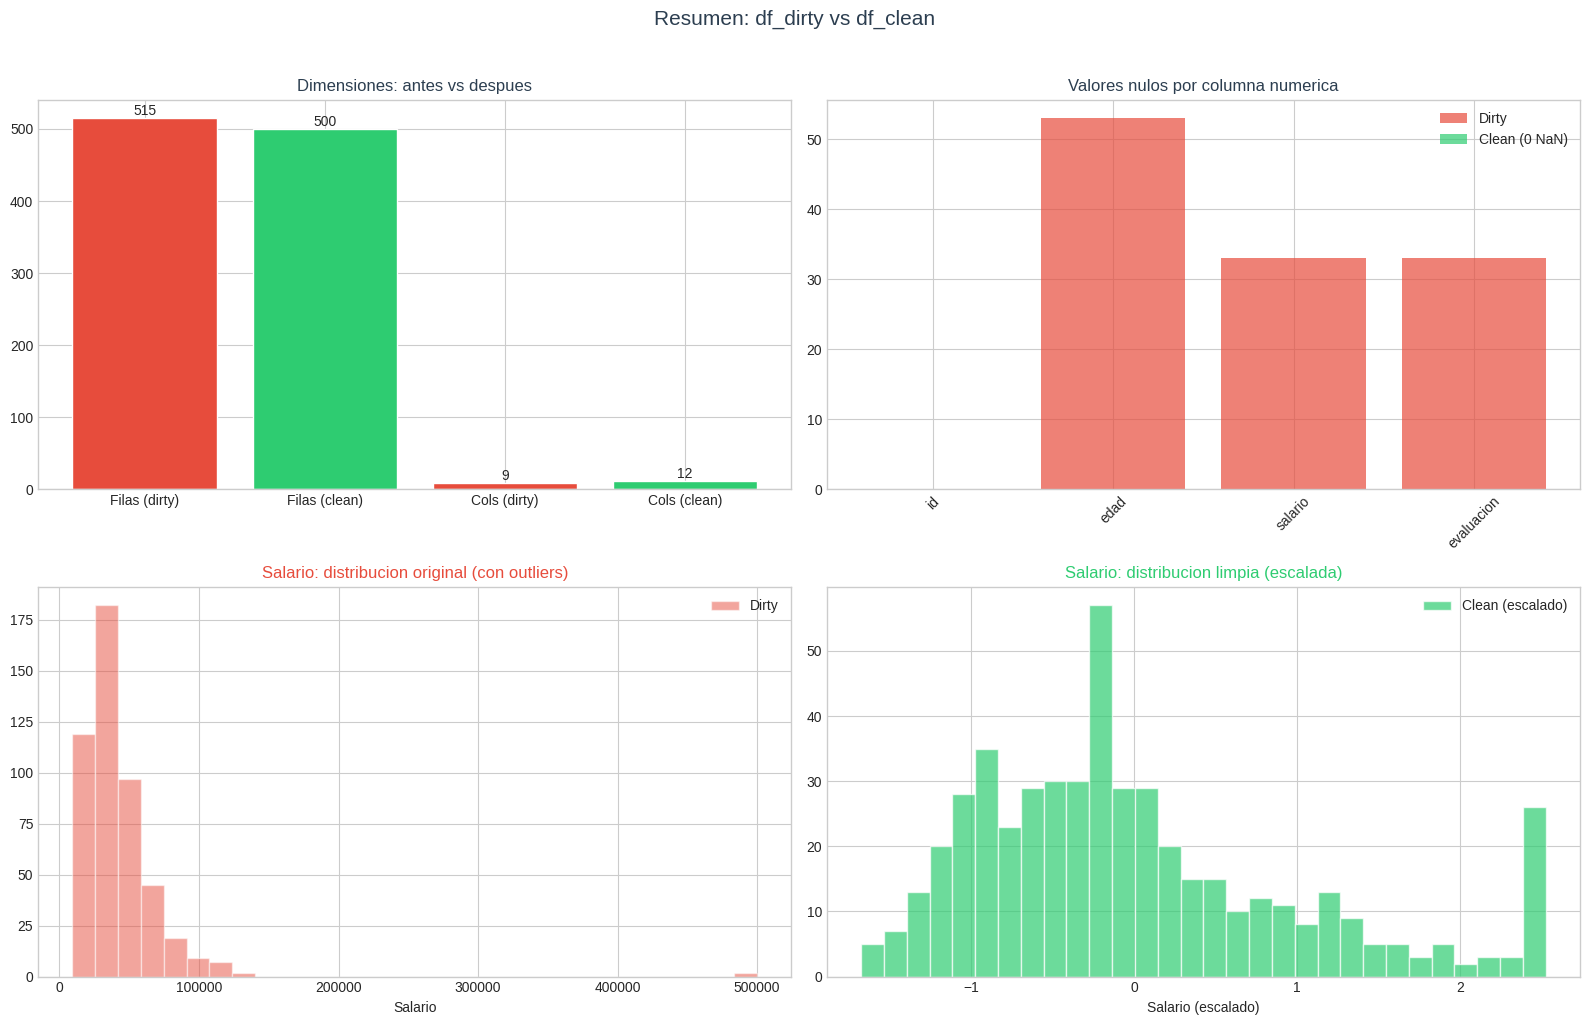

In [31]:
# --- Ejercicio 30: Limpieza end-to-end ---

df = df_dirty.copy()
print(f"INICIO: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"  NaN totales: {df.isnull().sum().sum()}")

# === PASO 1: Eliminar duplicados ===
n_antes = len(df)
df = df.drop_duplicates()
print(f"\n[1] Duplicados eliminados: {n_antes - len(df)} -> quedan {len(df)} filas")

# === PASO 2: Normalizar strings ===
df['nombre'] = df['nombre'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title()
df['departamento'] = df['departamento'].str.strip().str.title().replace({'It': 'IT', 'Rrhh': 'RRHH'})
df['ciudad'] = df['ciudad'].str.strip().str.title()
df['satisfaccion'] = df['satisfaccion'].str.strip().str.lower()
print(f"[2] Strings normalizados")

# === PASO 3: Parsear fechas ===
def parsear_fecha(x):
    if pd.isna(x):
        return pd.NaT
    for fmt in ['%Y-%m-%d', '%d/%m/%Y']:
        try:
            return pd.to_datetime(x, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['fecha_ingreso'] = df['fecha_ingreso'].apply(parsear_fecha)
df['mes_ingreso'] = df['fecha_ingreso'].dt.month
df['dia_semana'] = df['fecha_ingreso'].dt.dayofweek
print(f"[3] Fechas parseadas, extraidos mes y dia de semana")

# === PASO 4: Validar rangos ===
df.loc[~df['edad'].between(18, 70), 'edad'] = np.nan
df.loc[df['salario'] <= 0, 'salario'] = np.nan
df.loc[~df['evaluacion'].between(1, 10), 'evaluacion'] = np.nan
print(f"[4] Valores fuera de rango reemplazados por NaN")

# === PASO 5: Tratar outliers (winsorizar salario con IQR) ===
Q1 = df['salario'].quantile(0.25)
Q3 = df['salario'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
n_out = ((df['salario'] < lim_inf) | (df['salario'] > lim_sup)).sum()
df['salario'] = df['salario'].clip(lower=lim_inf, upper=lim_sup)
print(f"[5] Outliers en salario winsorizados: {n_out} valores recortados")

# === PASO 6: Imputar nulos ===
df['edad'] = df['edad'].fillna(df['edad'].median())
df['salario'] = df['salario'].fillna(df['salario'].median())
df['evaluacion'] = df['evaluacion'].fillna(df['evaluacion'].median())
df['nombre'] = df['nombre'].fillna('Desconocido')
df['departamento'] = df['departamento'].fillna(df['departamento'].mode()[0])
df['ciudad'] = df['ciudad'].fillna(df['ciudad'].mode()[0])
df['satisfaccion'] = df['satisfaccion'].fillna(df['satisfaccion'].mode()[0])
df['mes_ingreso'] = df['mes_ingreso'].fillna(df['mes_ingreso'].median())
df['dia_semana'] = df['dia_semana'].fillna(df['dia_semana'].median())
print(f"[6] Nulos imputados. NaN restantes: {df.isnull().sum().sum()}")

# === PASO 7: Encoding categorico ===
mapeo_satis = {'bajo': 1, 'medio': 2, 'alto': 3}
df['satisfaccion_ord'] = df['satisfaccion'].map(mapeo_satis)
df = pd.get_dummies(df, columns=['departamento', 'ciudad'], drop_first=True)
print(f"[7] Encoding aplicado: ordinal (satisfaccion), one-hot (departamento, ciudad)")

# === PASO 8: Escalar numericas ===
cols_to_scale = ['edad', 'salario', 'evaluacion', 'satisfaccion_ord', 'mes_ingreso', 'dia_semana']
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print(f"[8] Columnas numericas escaladas con StandardScaler")

# Eliminar columnas auxiliares
df_clean = df.drop(columns=['id', 'nombre', 'satisfaccion', 'fecha_ingreso'], errors='ignore')

print(f"\n{'='*60}")
print(f"RESULTADO FINAL: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")
print(f"NaN totales: {df_clean.isnull().sum().sum()}")
print(f"Tipos: {df_clean.dtypes.value_counts().to_dict()}")
print(f"Columnas: {list(df_clean.columns)}")

display(df_clean.head(10))

# === VISUALIZACION COMPARATIVA ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Comparar shape
labels_shape = ['Filas (dirty)', 'Filas (clean)', 'Cols (dirty)', 'Cols (clean)']
vals_shape = [df_dirty.shape[0], df_clean.shape[0], df_dirty.shape[1], df_clean.shape[1]]
colors_shape = [C_DANGER, C_SUCCESS, C_DANGER, C_SUCCESS]
bars = axes[0, 0].bar(labels_shape, vals_shape, color=colors_shape, edgecolor='white')
axes[0, 0].bar_label(bars, fontsize=10)
axes[0, 0].set_title('Dimensiones: antes vs despues', fontsize=12, color=C_DARK)

# NaN comparison
nulls_dirty = df_dirty.select_dtypes(include=[np.number]).isnull().sum()
axes[0, 1].bar(nulls_dirty.index, nulls_dirty.values, color=C_DANGER, alpha=0.7, label='Dirty')
axes[0, 1].bar(nulls_dirty.index, [0]*len(nulls_dirty), color=C_SUCCESS, alpha=0.7, label='Clean (0 NaN)')
axes[0, 1].set_title('Valores nulos por columna numerica', fontsize=12, color=C_DARK)
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Distribucion de salario antes vs despues
axes[1, 0].hist(df_dirty['salario'].dropna(), bins=30, color=C_DANGER, alpha=0.5, label='Dirty', edgecolor='white')
axes[1, 0].set_title('Salario: distribucion original (con outliers)', fontsize=12, color=C_DANGER)
axes[1, 0].legend()
axes[1, 0].set_xlabel('Salario')

salario_idx = cols_to_scale.index('salario')
axes[1, 1].hist(df_clean['salario'], bins=30, color=C_SUCCESS, alpha=0.7, edgecolor='white', label='Clean (escalado)')
axes[1, 1].set_title('Salario: distribucion limpia (escalada)', fontsize=12, color=C_SUCCESS)
axes[1, 1].legend()
axes[1, 1].set_xlabel('Salario (escalado)')

plt.suptitle('Resumen: df_dirty vs df_clean', fontsize=15, color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

---

## Bloque 10: Intermedio-Avanzado (Ejercicios 31-50)

---

**Ejercicio 31:** Cargar el dataset Iris de scikit-learn, inyectar artificialmente un 10% de valores nulos aleatorios, agregar outliers extremos en dos columnas y duplicar algunas filas. Luego, realizar una limpieza completa: (1) eliminar duplicados, (2) detectar y tratar outliers con IQR, (3) imputar nulos con KNNImputer. Mostrar el dataset antes y despues de cada paso.

**Resolucion Ejercicio 31:**

1. Cargar Iris con `sklearn.datasets.load_iris` y convertir a DataFrame.
2. Inyectar ~10% de NaN en posiciones aleatorias usando una mascara booleana.
3. Insertar outliers extremos en `sepal length` y `petal width` (valores 10x fuera de rango).
4. Duplicar un subconjunto de filas con `pd.concat`.
5. Paso 1 de limpieza: `drop_duplicates()` para eliminar filas duplicadas.
6. Paso 2 de limpieza: calcular IQR por columna numerica, recortar outliers a los limites.
7. Paso 3 de limpieza: `KNNImputer(n_neighbors=5)` para rellenar los NaN restantes.
8. En cada paso, mostrar shape y estadisticas para verificar el progreso.

In [ ]:
# --- Ejercicio 31: Limpieza completa de Iris ---
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

np.random.seed(42)

# Cargar Iris
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
print("=== Dataset original ===")
print(f"Shape: {df_iris.shape}")
print(df_iris.describe())

# --- Inyectar problemas ---
df_sucio = df_iris.copy()

# 1) Inyectar 10% NaN
mask = np.random.random(df_sucio[iris.feature_names].shape) < 0.10
df_sucio.loc[:, iris.feature_names] = df_sucio[iris.feature_names].mask(mask)

# 2) Insertar outliers extremos
outlier_idx = np.random.choice(df_sucio.index, size=5, replace=False)
df_sucio.loc[outlier_idx, 'sepal length (cm)'] = np.random.uniform(50, 80, size=5)
outlier_idx2 = np.random.choice(df_sucio.index, size=5, replace=False)
df_sucio.loc[outlier_idx2, 'petal width (cm)'] = np.random.uniform(20, 40, size=5)

# 3) Duplicar filas
filas_dup = df_sucio.sample(20, random_state=42)
df_sucio = pd.concat([df_sucio, filas_dup], ignore_index=True)

print("\n=== Dataset sucio ===")
print(f"Shape: {df_sucio.shape}")
print(f"Duplicados: {df_sucio.duplicated().sum()}")
print(f"Nulos totales: {df_sucio.isnull().sum().sum()}")

# --- Limpieza ---
# Paso 1: eliminar duplicados
df_limpio = df_sucio.drop_duplicates().reset_index(drop=True)
print(f"\n--- Paso 1: Eliminar duplicados ---")
print(f"Shape despues: {df_limpio.shape}")

# Paso 2: tratar outliers con IQR (clip)
num_cols = iris.feature_names
for col in num_cols:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_limpio[col] < lower) | (df_limpio[col] > upper)).sum()
    df_limpio[col] = df_limpio[col].clip(lower, upper)
    print(f"  {col}: {n_outliers} outliers recortados a [{lower:.2f}, {upper:.2f}]")

# Paso 3: imputar NaN con KNNImputer
print(f"\nNulos antes de imputar: {df_limpio[num_cols].isnull().sum().sum()}")
imputer = KNNImputer(n_neighbors=5)
df_limpio[num_cols] = imputer.fit_transform(df_limpio[num_cols])
print(f"Nulos despues de imputar: {df_limpio[num_cols].isnull().sum().sum()}")

# Visualizacion antes/despues
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df_sucio[col].dropna(), bins=20, alpha=0.7, color='salmon', edgecolor='black')
    axes[0, i].set_title(f"ANTES\n{col}", fontsize=9)
    axes[1, i].hist(df_limpio[col], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1, i].set_title(f"DESPUES\n{col}", fontsize=9)
fig.suptitle("Ejercicio 31: Limpieza completa de Iris", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Resumen final ===")
print(df_limpio.describe())

**Ejercicio 32:** Data drift detection. Generar un dataset de entrenamiento con distribuciones normales conocidas (3 features). Luego generar un dataset de "produccion" donde una de las features tiene la media desplazada. Aplicar el test de Kolmogorov-Smirnov (KS-test) columna por columna para detectar automaticamente cual feature sufrio drift. Visualizar las distribuciones lado a lado.

**Resolucion Ejercicio 32:**

1. Generar `df_train` con 1000 filas y 3 columnas: feature_A ~ N(0,1), feature_B ~ N(5,2), feature_C ~ N(10,3).
2. Generar `df_prod` con las mismas distribuciones, excepto feature_B ~ N(7,2) (media desplazada +2).
3. Para cada columna, ejecutar `scipy.stats.ks_2samp(train_col, prod_col)`.
4. Si p-value < 0.05, se declara drift significativo en esa feature.
5. Visualizar histogramas superpuestos de train vs produccion para cada feature.
6. El KS-test detectara que feature_B tiene drift y las otras dos no.

In [ ]:
# --- Ejercicio 32: Data drift detection con KS-test ---
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000

# Generar datos de entrenamiento
df_train = pd.DataFrame({
    'feature_A': np.random.normal(0, 1, n),
    'feature_B': np.random.normal(5, 2, n),
    'feature_C': np.random.normal(10, 3, n)
})

# Generar datos de produccion (feature_B con drift: media desplazada)
df_prod = pd.DataFrame({
    'feature_A': np.random.normal(0, 1, n),
    'feature_B': np.random.normal(7, 2, n),   # media 5 -> 7
    'feature_C': np.random.normal(10, 3, n)
})

print("=== Estadisticas Train ===")
print(df_train.describe().round(3))
print("\n=== Estadisticas Produccion ===")
print(df_prod.describe().round(3))

# KS-test por columna
print("\n=== Resultados KS-test (alpha=0.05) ===")
resultados = []
for col in df_train.columns:
    stat, pvalue = stats.ks_2samp(df_train[col], df_prod[col])
    drift = "DRIFT DETECTADO" if pvalue < 0.05 else "Sin drift"
    resultados.append({'feature': col, 'KS_stat': stat, 'p_value': pvalue, 'resultado': drift})
    print(f"  {col}: KS={stat:.4f}, p-value={pvalue:.6f} => {drift}")

df_resultados = pd.DataFrame(resultados)
print("\n", df_resultados.to_string(index=False))

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(df_train.columns):
    axes[i].hist(df_train[col], bins=30, alpha=0.5, label='Train', color='steelblue', density=True)
    axes[i].hist(df_prod[col], bins=30, alpha=0.5, label='Produccion', color='salmon', density=True)
    pval = df_resultados.loc[df_resultados['feature'] == col, 'p_value'].values[0]
    axes[i].set_title(f"{col}\np-value={pval:.4f}", fontsize=10)
    axes[i].legend()
fig.suptitle("Ejercicio 32: Data Drift Detection (KS-test)", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 33:** Feature selection por correlacion. Generar un DataFrame con 8 features numericas donde algunas pares tengan correlacion superior a 0.95. Escribir una funcion que detecte automaticamente los pares con correlacion > 0.95 y elimine una de las dos columnas de cada par. Mostrar la matriz de correlacion antes y despues.

**Resolucion Ejercicio 33:**

1. Generar 8 features: 5 independientes y 3 derivadas (casi copias con ruido minimo) para crear correlaciones >0.95.
2. Calcular la matriz de correlacion absoluta con `df.corr().abs()`.
3. Tomar el triangulo superior para evitar contar pares dos veces.
4. Iterar: si una columna ya esta marcada para eliminar, saltar; si no, marcar la segunda del par.
5. Eliminar las columnas marcadas.
6. Visualizar heatmaps de correlacion antes y despues con seaborn.

In [ ]:
# --- Ejercicio 33: Eliminar features con correlacion >0.95 ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500

# Generar features: 5 independientes + 3 derivadas (alta correlacion)
df33 = pd.DataFrame({
    'f1': np.random.normal(0, 1, n),
    'f2': np.random.normal(5, 2, n),
    'f3': np.random.normal(10, 3, n),
    'f4': np.random.uniform(0, 100, n),
    'f5': np.random.exponential(2, n),
})
df33['f6'] = df33['f1'] * 1.0 + np.random.normal(0, 0.02, n)  # ~f1
df33['f7'] = df33['f3'] * 0.99 + np.random.normal(0, 0.05, n)  # ~f3
df33['f8'] = df33['f4'] + np.random.normal(0, 0.1, n)           # ~f4

print("=== Correlaciones altas (>0.95) ===")
corr_matrix = df33.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

pares_altos = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and val > 0.95:
            pares_altos.append((idx, col, val))
            print(f"  {idx} <-> {col}: {val:.4f}")

# Funcion para eliminar features con correlacion > umbral
def eliminar_correlacionadas(df, umbral=0.95):
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set()
    for col in upper.columns:
        for idx in upper.index:
            if pd.notna(upper.loc[idx, col]) and upper.loc[idx, col] > umbral:
                if col not in to_drop:
                    to_drop.add(col)
    return df.drop(columns=to_drop), to_drop

df33_limpio, eliminadas = eliminar_correlacionadas(df33, umbral=0.95)
print(f"\nColumnas eliminadas: {eliminadas}")
print(f"Shape antes: {df33.shape} -> Shape despues: {df33_limpio.shape}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df33.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("ANTES: Matriz de correlacion")
sns.heatmap(df33_limpio.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("DESPUES: Sin features redundantes")
fig.suptitle("Ejercicio 33: Feature Selection por Correlacion", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 34:** IterativeImputer (MICE) completo. Generar un dataset con 4 features correlacionadas y crear valores faltantes del tipo MAR (Missing At Random): la probabilidad de falta en una columna depende de otra columna. Comparar la imputacion con `IterativeImputer` (MICE) frente a `SimpleImputer(strategy='mean')` midiendo el error respecto a los valores originales.

**Resolucion Ejercicio 34:**

1. Generar datos con correlacion usando una matriz de covarianza definida (4 variables).
2. Crear mecanismo MAR: las filas donde columna_A > percentil 70, tienen 40% probabilidad de NaN en columna_B.
3. Guardar copia de los valores originales para calcular el error.
4. Imputar con `SimpleImputer(strategy='mean')` y medir RMSE contra los originales.
5. Imputar con `IterativeImputer(max_iter=10, random_state=42)` y medir RMSE.
6. Comparar: MICE deberia tener menor error porque aprovecha las correlaciones entre variables.
7. Visualizar distribuciones imputadas vs originales para ambos metodos.

In [ ]:
# --- Ejercicio 34: IterativeImputer (MICE) vs SimpleImputer ---
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500

# Generar datos correlacionados
mean = [50, 30, 20, 10]
cov = [[10, 6, 4, 2],
       [6, 8, 5, 3],
       [4, 5, 7, 4],
       [2, 3, 4, 6]]
data = np.random.multivariate_normal(mean, cov, n)
cols = ['A', 'B', 'C', 'D']
df34_orig = pd.DataFrame(data, columns=cols)

# Crear mecanismo MAR: donde A > percentil 70, B tiene 40% prob de ser NaN
df34 = df34_orig.copy()
p70 = df34['A'].quantile(0.70)
mar_mask = (df34['A'] > p70) & (np.random.random(n) < 0.40)
df34.loc[mar_mask, 'B'] = np.nan

# Agregar algunos NaN aleatorios en C y D
mask_c = np.random.random(n) < 0.08
mask_d = np.random.random(n) < 0.08
df34.loc[mask_c, 'C'] = np.nan
df34.loc[mask_d, 'D'] = np.nan

print(f"Nulos por columna:\n{df34.isnull().sum()}")
print(f"Total nulos: {df34.isnull().sum().sum()}")

# Indices donde hay NaN en B (para comparar)
nan_idx_B = df34['B'].isnull()
valores_reales_B = df34_orig.loc[nan_idx_B, 'B'].values

# Imputacion con SimpleImputer (media)
imp_simple = SimpleImputer(strategy='mean')
df_simple = pd.DataFrame(imp_simple.fit_transform(df34), columns=cols)
rmse_simple = np.sqrt(mean_squared_error(valores_reales_B, df_simple.loc[nan_idx_B, 'B'].values))

# Imputacion con IterativeImputer (MICE)
imp_mice = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(imp_mice.fit_transform(df34), columns=cols)
rmse_mice = np.sqrt(mean_squared_error(valores_reales_B, df_mice.loc[nan_idx_B, 'B'].values))

print(f"\n=== Comparacion de RMSE en columna B (solo posiciones imputadas) ===")
print(f"  SimpleImputer (media): RMSE = {rmse_simple:.4f}")
print(f"  IterativeImputer (MICE): RMSE = {rmse_mice:.4f}")
print(f"  Mejora relativa: {(rmse_simple - rmse_mice) / rmse_simple * 100:.1f}%")

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df34_orig['B'], bins=25, alpha=0.7, color='green', label='Original', density=True)
axes[0].set_title("Original (sin NaN)")
axes[0].legend()

axes[1].hist(df34_orig['B'], bins=25, alpha=0.4, color='green', label='Original', density=True)
axes[1].hist(df_simple['B'], bins=25, alpha=0.4, color='salmon', label=f'SimpleImputer\nRMSE={rmse_simple:.3f}', density=True)
axes[1].set_title("SimpleImputer (media)")
axes[1].legend()

axes[2].hist(df34_orig['B'], bins=25, alpha=0.4, color='green', label='Original', density=True)
axes[2].hist(df_mice['B'], bins=25, alpha=0.4, color='steelblue', label=f'MICE\nRMSE={rmse_mice:.3f}', density=True)
axes[2].set_title("IterativeImputer (MICE)")
axes[2].legend()

fig.suptitle("Ejercicio 34: MICE vs SimpleImputer en datos MAR", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 35:** Encoding de alta cardinalidad. Generar un DataFrame con una columna categorica `ciudad` con 500 ciudades unicas y un target numerico. Aplicar dos estrategias de encoding: (a) Frequency Encoding (reemplazar cada ciudad por su frecuencia relativa) y (b) Target Encoding (reemplazar por la media del target por ciudad). Comparar ambos resultados y discutir ventajas e inconvenientes.

**Resolucion Ejercicio 35:**

1. Generar 5000 filas con 500 ciudades (frecuencias desiguales usando distribuciones Zipf-like).
2. Asignar un target numerico correlacionado parcialmente con la ciudad.
3. Frequency Encoding: `df['ciudad'].map(df['ciudad'].value_counts(normalize=True))`.
4. Target Encoding: `df['ciudad'].map(df.groupby('ciudad')['target'].mean())`.
5. Frequency Encoding no usa informacion del target (no hay leakage), pero pierde la relacion ciudad-target.
6. Target Encoding captura la relacion, pero puede causar overfitting en ciudades con pocas observaciones.
7. Visualizar distribucion de valores codificados para ambos metodos.

In [ ]:
# --- Ejercicio 35: Encoding alta cardinalidad (500 ciudades) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 5000
n_ciudades = 500

# Generar ciudades con frecuencias desiguales (tipo Zipf)
ciudades = [f"ciudad_{i:04d}" for i in range(n_ciudades)]
probs = np.random.zipf(1.5, n_ciudades).astype(float)
probs /= probs.sum()
ciudad_col = np.random.choice(ciudades, size=n, p=probs)

# Asignar un efecto por ciudad y generar target
efecto_ciudad = {c: np.random.normal(0, 5) for c in ciudades}
target = np.array([efecto_ciudad[c] for c in ciudad_col]) + np.random.normal(0, 3, n)

df35 = pd.DataFrame({'ciudad': ciudad_col, 'target': target})
print(f"Shape: {df35.shape}")
print(f"Ciudades unicas: {df35['ciudad'].nunique()}")
print(f"Top 10 ciudades mas frecuentes:\n{df35['ciudad'].value_counts().head(10)}")

# --- Frequency Encoding ---
freq_map = df35['ciudad'].value_counts(normalize=True)
df35['ciudad_freq_enc'] = df35['ciudad'].map(freq_map)

# --- Target Encoding ---
target_map = df35.groupby('ciudad')['target'].mean()
df35['ciudad_target_enc'] = df35['ciudad'].map(target_map)

print(f"\n=== Primeras filas con ambos encodings ===")
print(df35[['ciudad', 'target', 'ciudad_freq_enc', 'ciudad_target_enc']].head(10))

# Correlacion con target
corr_freq = df35['ciudad_freq_enc'].corr(df35['target'])
corr_target = df35['ciudad_target_enc'].corr(df35['target'])
print(f"\nCorrelacion con target:")
print(f"  Frequency Encoding: {corr_freq:.4f}")
print(f"  Target Encoding:    {corr_target:.4f}")

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df35['ciudad_freq_enc'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Frequency Encoding\n(distribucion de valores)")
axes[0].set_xlabel("Frecuencia relativa")

axes[1].hist(df35['ciudad_target_enc'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title("Target Encoding\n(distribucion de valores)")
axes[1].set_xlabel("Media del target")

axes[2].scatter(df35['ciudad_target_enc'], df35['target'], alpha=0.1, s=5)
axes[2].set_xlabel("Target Encoding")
axes[2].set_ylabel("Target real")
axes[2].set_title(f"Target Enc vs Target\ncorr={corr_target:.3f}")

fig.suptitle("Ejercicio 35: Encoding Alta Cardinalidad", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 36:** Clases raras. Generar una columna categorica con ~20 categorias donde la mayoria tenga frecuencias muy bajas (<1% del total). Agrupar todas las categorias con frecuencia inferior al 1% en una nueva categoria llamada "Otros". Mostrar la distribucion de categorias antes y despues de la agrupacion.

**Resolucion Ejercicio 36:**

1. Crear 20 categorias con probabilidades desiguales (unas pocas dominantes, muchas raras).
2. Generar 2000 observaciones con esas probabilidades.
3. Calcular la frecuencia relativa de cada categoria.
4. Identificar las que tienen <1% y reemplazarlas por "Otros".
5. Comparar el numero de categorias antes y despues.
6. Visualizar con graficos de barras horizontales antes y despues.

In [ ]:
# --- Ejercicio 36: Agrupar clases raras en "Otros" ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 2000

# Crear 20 categorias con probabilidades desiguales
categorias = [f"Cat_{chr(65+i)}" for i in range(20)]
probs = np.array([30, 25, 15, 8, 5, 3, 2, 1.5, 1.2, 1, 0.9, 0.8, 0.7, 0.6,
                  0.5, 0.4, 0.3, 0.2, 0.15, 0.05])  # suman ~96.3, se normaliza
probs = probs / probs.sum()

df36 = pd.DataFrame({
    'categoria': np.random.choice(categorias, size=n, p=probs),
    'valor': np.random.normal(100, 20, n)
})

print("=== ANTES: Distribucion de categorias ===")
freq_antes = df36['categoria'].value_counts(normalize=True).sort_values(ascending=False)
print(freq_antes)
print(f"\nCategorias unicas: {df36['categoria'].nunique()}")

# Identificar categorias raras (<1%)
umbral = 0.01
categorias_raras = freq_antes[freq_antes < umbral].index.tolist()
print(f"\nCategorias con <1% de frecuencia ({len(categorias_raras)}):")
print(f"  {categorias_raras}")

# Agrupar en "Otros"
df36['categoria_limpia'] = df36['categoria'].apply(
    lambda x: "Otros" if x in categorias_raras else x
)

print(f"\n=== DESPUES: Distribucion de categorias ===")
freq_despues = df36['categoria_limpia'].value_counts(normalize=True).sort_values(ascending=False)
print(freq_despues)
print(f"\nCategorias unicas: {df36['categoria_limpia'].nunique()}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
freq_antes.sort_values().plot.barh(ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title(f"ANTES\n{len(freq_antes)} categorias")
axes[0].axvline(x=umbral, color='red', linestyle='--', label=f'Umbral {umbral*100}%')
axes[0].legend()
axes[0].set_xlabel("Frecuencia relativa")

freq_despues.sort_values().plot.barh(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title(f"DESPUES\n{len(freq_despues)} categorias")
axes[1].set_xlabel("Frecuencia relativa")

fig.suptitle("Ejercicio 36: Agrupar Clases Raras (<1%) en 'Otros'", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 37:** Limpieza de texto. Crear una columna con comentarios sucios que contengan etiquetas HTML, URLs, signos de puntuacion excesivos, espacios multiples y caracteres especiales. Limpiar aplicando: (1) eliminar HTML con regex, (2) eliminar URLs, (3) eliminar puntuacion, (4) normalizar espacios, (5) convertir a minusculas. Mostrar cada comentario antes y despues.

**Resolucion Ejercicio 37:**

1. Crear manualmente 8-10 comentarios con problemas tipicos de datos web.
2. Paso 1: `re.sub(r'<[^>]+>', '', texto)` para quitar etiquetas HTML.
3. Paso 2: `re.sub(r'https?://\S+', '', texto)` para quitar URLs.
4. Paso 3: `re.sub(r'[^\w\s]', '', texto)` para quitar puntuacion.
5. Paso 4: `re.sub(r'\s+', ' ', texto).strip()` para normalizar espacios.
6. Paso 5: `.lower()` para convertir a minusculas.
7. Encapsular todo en una funcion `limpiar_texto()` reutilizable.
8. Mostrar tabla comparativa antes/despues.

In [ ]:
# --- Ejercicio 37: Limpiar columna de comentarios (HTML, URLs, puntuacion) ---
import re
import pandas as pd

comentarios_sucios = [
    '<p>Excelente producto!!!  Me <b>encanto</b> mucho.</p>',
    'Malisimo, ver https://www.ejemplo.com/quejas   para mas info...',
    '<div class="review">No lo recomiendo &amp; es caro!!!</div>',
    'Bueno...  pero   el envio fue    LENTO.  https://tracking.com/abc123',
    '<span>5 estrellas *****</span> <a href="link">ver mas</a>',
    'PESIMO!!! @#$%  no  funciona   para    NADA',
    'Producto OK, ver detalles en http://mi-sitio.org/review?id=42&lang=es',
    '<h1>Gran compra</h1><br/>Lo volveria a    comprar!!!',
    'regular... ni bueno ni malo https://t.co/xyz123 #opinion @usuario',
    '  Llego    roto,  <i>muy</i>   decepcionado   :( :( :(  '
]

df37 = pd.DataFrame({'comentario_sucio': comentarios_sucios})

def limpiar_texto(texto):
    """Limpia texto eliminando HTML, URLs, puntuacion, normalizando espacios."""
    # 1. Eliminar etiquetas HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # 2. Eliminar entidades HTML
    texto = re.sub(r'&\w+;', ' ', texto)
    # 3. Eliminar URLs
    texto = re.sub(r'https?://\S+', '', texto)
    # 4. Eliminar menciones y hashtags
    texto = re.sub(r'[@#]\w+', '', texto)
    # 5. Eliminar puntuacion y caracteres especiales
    texto = re.sub(r'[^\w\s]', '', texto)
    # 6. Normalizar espacios multiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    # 7. Convertir a minusculas
    texto = texto.lower()
    return texto

df37['comentario_limpio'] = df37['comentario_sucio'].apply(limpiar_texto)

print("=== Comparacion ANTES / DESPUES ===\n")
for i, row in df37.iterrows():
    print(f"[{i}] ANTES:   {row['comentario_sucio']}")
    print(f"    DESPUES: {row['comentario_limpio']}")
    print()

# Visualizacion: longitud de caracteres antes vs despues
import matplotlib.pyplot as plt

df37['len_antes'] = df37['comentario_sucio'].str.len()
df37['len_despues'] = df37['comentario_limpio'].str.len()

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df37))
width = 0.35
ax.bar([i - width/2 for i in x], df37['len_antes'], width, label='Antes', color='salmon')
ax.bar([i + width/2 for i in x], df37['len_despues'], width, label='Despues', color='steelblue')
ax.set_xlabel("Comentario #")
ax.set_ylabel("Longitud (caracteres)")
ax.set_title("Ejercicio 37: Longitud de comentarios antes vs despues de limpieza", fontweight='bold')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 38:** Series temporales con gaps. Generar una serie temporal diaria de 365 dias, eliminar aleatoriamente 30 dias para crear huecos. Detectar los gaps (dias faltantes) y rellenarlos con dos metodos: (a) interpolacion lineal y (b) interpolacion spline. Comparar visualmente ambos metodos contra los datos originales.

**Resolucion Ejercicio 38:**

1. Generar serie temporal con tendencia + estacionalidad + ruido para 365 dias.
2. Eliminar 30 dias aleatorios para simular datos faltantes.
3. Reindexar con `pd.date_range` completo para que aparezcan NaN en los gaps.
4. Detectar gaps: encontrar las fechas donde el valor es NaN.
5. Interpolar con `interpolate(method='linear')`.
6. Interpolar con `interpolate(method='spline', order=3)`.
7. Visualizar las tres series (original, lineal, spline) superpuestas marcando los gaps.

In [ ]:
# --- Ejercicio 38: Series temporales - detectar gaps e interpolar ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar serie temporal: tendencia + estacionalidad + ruido
fechas = pd.date_range('2025-01-01', periods=365, freq='D')
t = np.arange(365)
valores = 20 + 0.05 * t + 5 * np.sin(2 * np.pi * t / 365) + np.random.normal(0, 1, 365)
df38_orig = pd.Series(valores, index=fechas, name='valor')

# Eliminar 30 dias aleatorios
idx_eliminar = np.random.choice(365, size=30, replace=False)
idx_eliminar.sort()
df38_gaps = df38_orig.copy()
df38_gaps.iloc[idx_eliminar] = np.nan

# Detectar gaps
gaps = df38_gaps[df38_gaps.isnull()].index
print(f"=== Gaps detectados: {len(gaps)} dias faltantes ===")
print(f"Primeros 10 gaps: {gaps[:10].tolist()}")

# Interpolacion lineal
df38_lineal = df38_gaps.interpolate(method='linear')

# Interpolacion spline
df38_spline = df38_gaps.interpolate(method='spline', order=3)

# Calcular error en posiciones interpoladas
rmse_lineal = np.sqrt(np.mean((df38_orig.iloc[idx_eliminar] - df38_lineal.iloc[idx_eliminar])**2))
rmse_spline = np.sqrt(np.mean((df38_orig.iloc[idx_eliminar] - df38_spline.iloc[idx_eliminar])**2))
print(f"\nRMSE Interpolacion Lineal: {rmse_lineal:.4f}")
print(f"RMSE Interpolacion Spline: {rmse_spline:.4f}")

# Visualizacion
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Serie con gaps
axes[0].plot(df38_orig.index, df38_orig.values, 'g-', alpha=0.3, label='Original')
axes[0].plot(df38_gaps.index, df38_gaps.values, 'b-', linewidth=0.8, label='Con gaps')
axes[0].scatter(gaps, [df38_orig[g] for g in gaps], color='red', s=15, zorder=5, label=f'Gaps ({len(gaps)})')
axes[0].set_title("Serie con gaps (30 dias eliminados)")
axes[0].legend()

# Panel 2: Interpolacion lineal
axes[1].plot(df38_orig.index, df38_orig.values, 'g-', alpha=0.3, label='Original')
axes[1].plot(df38_lineal.index, df38_lineal.values, 'b-', linewidth=0.8, label='Interpolacion lineal')
axes[1].scatter(gaps, [df38_lineal[g] for g in gaps], color='orange', s=15, zorder=5, label='Valores interpolados')
axes[1].set_title(f"Interpolacion Lineal (RMSE={rmse_lineal:.4f})")
axes[1].legend()

# Panel 3: Interpolacion spline
axes[2].plot(df38_orig.index, df38_orig.values, 'g-', alpha=0.3, label='Original')
axes[2].plot(df38_spline.index, df38_spline.values, 'b-', linewidth=0.8, label='Interpolacion spline')
axes[2].scatter(gaps, [df38_spline[g] for g in gaps], color='purple', s=15, zorder=5, label='Valores interpolados')
axes[2].set_title(f"Interpolacion Spline orden 3 (RMSE={rmse_spline:.4f})")
axes[2].legend()

fig.suptitle("Ejercicio 38: Gaps en Series Temporales - Interpolacion", fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Ejercicio 39:** Cross-validation con pipeline para evitar data leakage. Generar un dataset de clasificacion. Demostrar que hacer fit del scaler en todo el dataset ANTES de cross-validation produce resultados optimistas (leakage), mientras que usar un Pipeline dentro de `cross_val_score` produce resultados correctos. Comparar las metricas de ambos enfoques.

**Resolucion Ejercicio 39:**

1. Generar datos con `make_classification` (200 muestras, 20 features, ruido moderado).
2. Enfoque INCORRECTO (con leakage): hacer `StandardScaler().fit_transform(X)` en todo X, luego `cross_val_score` con LogisticRegression.
3. Enfoque CORRECTO (sin leakage): crear `Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression())])` y pasarlo a `cross_val_score`.
4. El pipeline garantiza que el scaler se ajuste solo en el train de cada fold.
5. Comparar accuracy promedio de ambos enfoques; el incorrecto tendra valores ligeramente superiores.
6. Visualizar las distribuciones de scores de los folds para ambos metodos.

In [ ]:
# --- Ejercicio 39: Cross-validation con pipeline - evitar data leakage ---
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar dataset de clasificacion
X, y = make_classification(n_samples=200, n_features=20, n_informative=5,
                           n_redundant=5, n_classes=2, random_state=42,
                           flip_y=0.15)  # 15% ruido para hacer el problema mas dificil

print(f"Shape X: {X.shape}, clases: {np.unique(y)}")

# --- ENFOQUE INCORRECTO: escalar TODO antes de CV (data leakage) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit en TODO el dataset (incluye datos de test)
scores_leakage = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_scaled, y, cv=10, scoring='accuracy'
)

# --- ENFOQUE CORRECTO: Pipeline dentro de CV (sin leakage) ---
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
scores_correcto = cross_val_score(pipe, X, y, cv=10, scoring='accuracy')

print(f"\n=== Resultados Cross-Validation (10 folds) ===")
print(f"\nCON LEAKAGE (scaler antes de CV):")
print(f"  Scores por fold: {np.round(scores_leakage, 3)}")
print(f"  Accuracy media:  {scores_leakage.mean():.4f} (+/- {scores_leakage.std():.4f})")

print(f"\nSIN LEAKAGE (Pipeline dentro de CV):")
print(f"  Scores por fold: {np.round(scores_correcto, 3)}")
print(f"  Accuracy media:  {scores_correcto.mean():.4f} (+/- {scores_correcto.std():.4f})")

diferencia = scores_leakage.mean() - scores_correcto.mean()
print(f"\nDiferencia (leakage - correcto): {diferencia:.4f}")
print("El enfoque con leakage tiende a dar resultados ligeramente optimistas.")

# Visualizacion
fig, ax = plt.subplots(figsize=(10, 5))
folds = np.arange(1, 11)
width = 0.35
ax.bar(folds - width/2, scores_leakage, width, label=f'Con Leakage (media={scores_leakage.mean():.3f})', color='salmon')
ax.bar(folds + width/2, scores_correcto, width, label=f'Sin Leakage (media={scores_correcto.mean():.3f})', color='steelblue')
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Ejercicio 39: Data Leakage en Cross-Validation", fontweight='bold')
ax.set_xticks(folds)
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

**Ejercicio 40:** Feature engineering automatico. Generar un dataset de regresion con 4 features. Aplicar `PolynomialFeatures` de grado 2 para generar interacciones y terminos cuadraticos. Luego, usar `mutual_info_regression` para seleccionar las K mejores features del conjunto expandido. Comparar el rendimiento de un modelo con features originales vs features seleccionadas.

**Resolucion Ejercicio 40:**

1. Generar datos con `make_regression` (300 muestras, 4 features).
2. Aplicar `PolynomialFeatures(degree=2, include_bias=False)` para expandir de 4 a 14 features.
3. Calcular `mutual_info_regression` para medir la informacion mutua de cada feature expandida con el target.
4. Seleccionar las top-K features (ej: K=8) con mayor informacion mutua.
5. Entrenar `LinearRegression` con: (a) 4 features originales, (b) 14 features polinomiales, (c) 8 features seleccionadas.
6. Comparar R2 en test para los tres modelos.
7. Visualizar ranking de features por informacion mutua.

In [ ]:
# --- Ejercicio 40: Feature engineering con PolynomialFeatures + mutual_info ---
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar dataset de regresion
X, y = make_regression(n_samples=300, n_features=4, n_informative=3,
                       noise=10, random_state=42)
feature_names_orig = [f'x{i}' for i in range(4)]

print(f"Features originales: {len(feature_names_orig)}")

# Aplicar PolynomialFeatures grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names_poly = poly.get_feature_names_out(feature_names_orig)

print(f"Features despues de PolynomialFeatures: {len(feature_names_poly)}")
print(f"Nombres: {list(feature_names_poly)}")

# Calcular mutual information
mi_scores = mutual_info_regression(X_poly, y, random_state=42)
mi_ranking = pd.Series(mi_scores, index=feature_names_poly).sort_values(ascending=False)

print(f"\n=== Ranking por Mutual Information ===")
print(mi_ranking.round(4))

# Seleccionar top-K features
K = 8
top_features = mi_ranking.head(K).index.tolist()
top_indices = [list(feature_names_poly).index(f) for f in top_features]
X_selected = X_poly[:, top_indices]

print(f"\nTop {K} features seleccionadas: {top_features}")

# Comparar modelos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_poly, X_test_poly = poly.fit_transform(X_train), poly.transform(X_test)
X_train_sel = X_train_poly[:, top_indices]
X_test_sel = X_test_poly[:, top_indices]

modelos = {
    f'Original ({X.shape[1]} features)': (X_train, X_test),
    f'Polinomial ({X_poly.shape[1]} features)': (X_train_poly, X_test_poly),
    f'Seleccionadas ({K} features)': (X_train_sel, X_test_sel),
}

print(f"\n=== Comparacion de R2 en test ===")
r2_results = {}
for nombre, (Xtr, Xte) in modelos.items():
    model = LinearRegression()
    model.fit(Xtr, y_train)
    r2 = r2_score(y_test, model.predict(Xte))
    r2_results[nombre] = r2
    print(f"  {nombre}: R2 = {r2:.4f}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ranking mutual info
mi_ranking.plot.barh(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel("Mutual Information")
axes[0].set_title("Ranking de Features por MI")
axes[0].axhline(y=len(mi_ranking) - K - 0.5, color='red', linestyle='--', label=f'Top {K}')

# R2 comparacion
bars = axes[1].bar(r2_results.keys(), r2_results.values(), color=['salmon', 'steelblue', 'green'], edgecolor='black')
axes[1].set_ylabel("R2 Score")
axes[1].set_title("R2 en Test Set")
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars, r2_results.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}',
                ha='center', fontweight='bold')

fig.suptitle("Ejercicio 40: PolynomialFeatures + Seleccion con Mutual Info", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 41:** TF-IDF + features numericas. Crear un DataFrame con una columna de texto (descripciones de productos) y columnas numericas (precio, rating). Aplicar TF-IDF a la columna de texto y combinar la matriz resultante con las features numericas en un solo DataFrame. Mostrar la forma del dataset combinado y las primeras filas.

**Resolucion Ejercicio 41:**

1. Crear DataFrame con 10 productos: descripcion (texto libre), precio y rating.
2. Aplicar `TfidfVectorizer(max_features=20)` a la columna de texto.
3. Convertir la matriz sparse resultante a DataFrame con los nombres de los tokens como columnas.
4. Escalar las columnas numericas con `StandardScaler`.
5. Concatenar ambos DataFrames horizontalmente con `pd.concat`.
6. Verificar que no hay NaN y que el shape es correcto.
7. Visualizar la distribucion de features TF-IDF y numericas.

In [ ]:
# --- Ejercicio 41: TF-IDF + features numericas ---
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)

# Crear dataset de productos
df41 = pd.DataFrame({
    'descripcion': [
        'laptop potente con procesador rapido y pantalla grande',
        'telefono movil con camara de alta resolucion y bateria larga',
        'auriculares inalambricos con cancelacion de ruido activa',
        'tablet ligera con pantalla grande y bateria duradera',
        'monitor curvo para gaming con alta tasa de refresco',
        'teclado mecanico retroiluminado con switches cherry',
        'raton inalambrico ergonomico con sensor de precision',
        'disco duro externo con gran capacidad de almacenamiento',
        'camara web con alta resolucion para videollamadas',
        'altavoz bluetooth portatil con sonido potente y bateria larga',
        'smartwatch con sensor de ritmo cardiaco y gps integrado',
        'cargador rapido con multiples puertos usb tipo c'
    ],
    'precio': [899.99, 599.99, 149.99, 449.99, 349.99, 89.99,
               39.99, 79.99, 59.99, 69.99, 199.99, 29.99],
    'rating': [4.5, 4.2, 4.7, 4.0, 4.3, 4.6, 4.1, 3.9, 4.0, 4.4, 4.2, 4.5]
})

print("=== Dataset original ===")
print(df41)

# Aplicar TF-IDF a la columna de texto
tfidf = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf.fit_transform(df41['descripcion'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{w}' for w in tfidf.get_feature_names_out()],
    index=df41.index
)

print(f"\nFeatures TF-IDF generadas: {tfidf_df.shape[1]}")
print(f"Vocabulario: {tfidf.get_feature_names_out().tolist()}")

# Escalar features numericas
scaler = StandardScaler()
num_cols = ['precio', 'rating']
num_scaled = pd.DataFrame(
    scaler.fit_transform(df41[num_cols]),
    columns=[f'scaled_{c}' for c in num_cols],
    index=df41.index
)

# Combinar
df41_combinado = pd.concat([num_scaled, tfidf_df], axis=1)
print(f"\n=== Dataset combinado ===")
print(f"Shape: {df41_combinado.shape}")
print(f"Columnas: {df41_combinado.columns.tolist()}")
print(f"NaN totales: {df41_combinado.isnull().sum().sum()}")
print(f"\nPrimeras 5 filas (primeras 8 columnas):")
print(df41_combinado.iloc[:5, :8])

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de TF-IDF
import seaborn as sns
sns.heatmap(tfidf_df, cmap='YlOrRd', ax=axes[0], xticklabels=True, yticklabels=True)
axes[0].set_title("Matriz TF-IDF")
axes[0].set_ylabel("Producto")
axes[0].tick_params(axis='x', rotation=45)

# Features numericas vs TF-IDF: dimensiones
labels = ['Numericas\n(escaladas)', 'TF-IDF', 'Combinado']
valores = [len(num_cols), tfidf_df.shape[1], df41_combinado.shape[1]]
bars = axes[1].bar(labels, valores, color=['steelblue', 'salmon', 'green'], edgecolor='black')
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', fontweight='bold')
axes[1].set_ylabel("Numero de features")
axes[1].set_title("Composicion del dataset combinado")

fig.suptitle("Ejercicio 41: TF-IDF + Features Numericas", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 42:** Target leakage. Crear un dataset de clasificacion donde una feature es una version ruidosa del target (simula informacion que no estaria disponible en produccion). Entrenar un modelo con y sin esa feature, mostrar que la accuracy es sospechosamente alta con ella. Detectar el leakage calculando la correlacion de cada feature con el target y eliminar la feature problematica.

**Resolucion Ejercicio 42:**

1. Generar dataset con `make_classification` (5 features legitimas).
2. Agregar una feature `leaked` = target + ruido_pequeno (correlacion ~0.95 con target).
3. Entrenar LogisticRegression con todas las features (incluida leaked) y medir accuracy.
4. Entrenar sin la feature leaked y comparar accuracy.
5. La feature leaked dara accuracy anormalmente alta (~95%+).
6. Detectar: calcular correlacion punto-biserial de cada feature con el target; la leaked tendra correlacion sospechosamente alta.
7. Visualizar las correlaciones como barras para identificar la feature problematica.

In [ ]:
# --- Ejercicio 42: Target leakage - detectar y eliminar ---
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar dataset
X, y = make_classification(n_samples=500, n_features=5, n_informative=3,
                           n_redundant=1, random_state=42, flip_y=0.1)
feature_names = [f'feature_{i}' for i in range(5)]
df42 = pd.DataFrame(X, columns=feature_names)
df42['target'] = y

# Agregar feature con leakage (version ruidosa del target)
df42['leaked'] = y + np.random.normal(0, 0.15, len(y))

print("=== Dataset con feature leaked ===")
print(df42.head())

# Modelo CON leakage
X_con_leak = df42.drop(columns=['target'])
scores_con = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                             X_con_leak, y, cv=5, scoring='accuracy')

# Modelo SIN leakage
X_sin_leak = df42[feature_names]
scores_sin = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                             X_sin_leak, y, cv=5, scoring='accuracy')

print(f"\n=== Resultados ===")
print(f"CON feature leaked:  Accuracy = {scores_con.mean():.4f} (+/- {scores_con.std():.4f})")
print(f"SIN feature leaked:  Accuracy = {scores_sin.mean():.4f} (+/- {scores_sin.std():.4f})")
print(f"Diferencia sospechosa: {scores_con.mean() - scores_sin.mean():.4f}")

# Detectar leakage: correlacion de cada feature con target
correlaciones = df42.drop(columns=['target']).corrwith(df42['target']).abs().sort_values(ascending=False)
print(f"\n=== Correlacion absoluta con target ===")
print(correlaciones)

umbral_sospecha = 0.8
sospechosas = correlaciones[correlaciones > umbral_sospecha].index.tolist()
print(f"\nFeatures sospechosas (corr > {umbral_sospecha}): {sospechosas}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlaciones
colors = ['red' if c > umbral_sospecha else 'steelblue' for c in correlaciones.values]
correlaciones.plot.bar(ax=axes[0], color=colors, edgecolor='black')
axes[0].axhline(y=umbral_sospecha, color='red', linestyle='--', label=f'Umbral {umbral_sospecha}')
axes[0].set_title("Correlacion absoluta con target")
axes[0].set_ylabel("|Correlacion|")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Accuracy comparacion
labels = ['Con Leakage', 'Sin Leakage']
means = [scores_con.mean(), scores_sin.mean()]
stds = [scores_con.std(), scores_sin.std()]
bars = axes[1].bar(labels, means, yerr=stds, color=['salmon', 'steelblue'],
                   edgecolor='black', capsize=5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy con vs sin leakage")
axes[1].set_ylim(0.5, 1.05)

fig.suptitle("Ejercicio 42: Target Leakage - Deteccion y Eliminacion", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 43:** Coordenadas GPS. Crear un DataFrame con columnas de latitud y longitud que contengan valores invalidos (latitudes fuera de [-90, 90], longitudes fuera de [-180, 180], valores nulos). Limpiar las coordenadas invalidas y calcular la distancia haversine entre pares de puntos consecutivos. Visualizar los puntos validos en un scatter plot.

**Resolucion Ejercicio 43:**

1. Crear 30 puntos GPS centrados en una region (ej: ciudades espanolas), algunos con errores.
2. Inyectar: latitudes > 90 o < -90, longitudes > 180, valores NaN.
3. Validar: marcar como invalidos los puntos fuera de rango o con NaN.
4. Eliminar o corregir los puntos invalidos.
5. Implementar la formula haversine para calcular distancias en km entre puntos consecutivos.
6. Mostrar tabla con puntos validos y distancias.
7. Visualizar los puntos en un scatter plot (lon vs lat), marcando invalidos en rojo.

In [ ]:
# --- Ejercicio 43: Coordenadas GPS - limpiar y distancia haversine ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Crear puntos GPS centrados en Espana (~40N, ~3W) con errores
n_puntos = 30
latitudes = np.random.uniform(36, 43, n_puntos)
longitudes = np.random.uniform(-9, 3, n_puntos)
nombres = [f"Punto_{i:02d}" for i in range(n_puntos)]

df43 = pd.DataFrame({'nombre': nombres, 'lat': latitudes, 'lon': longitudes})

# Inyectar errores
df43.loc[3, 'lat'] = 150.0       # latitud fuera de rango
df43.loc[7, 'lat'] = -100.0      # latitud fuera de rango
df43.loc[12, 'lon'] = 250.0      # longitud fuera de rango
df43.loc[18, 'lon'] = -200.0     # longitud fuera de rango
df43.loc[5, 'lat'] = np.nan      # NaN
df43.loc[5, 'lon'] = np.nan
df43.loc[22, 'lat'] = np.nan
df43.loc[25, 'lon'] = np.nan
df43.loc[15, 'lat'] = 0.0        # punto sospechoso (0,0 = "Null Island")
df43.loc[15, 'lon'] = 0.0

print("=== Dataset con errores ===")
print(df43.to_string())

# Validar coordenadas
def validar_gps(row):
    if pd.isna(row['lat']) or pd.isna(row['lon']):
        return 'NaN'
    if row['lat'] < -90 or row['lat'] > 90:
        return 'lat_fuera_rango'
    if row['lon'] < -180 or row['lon'] > 180:
        return 'lon_fuera_rango'
    if row['lat'] == 0 and row['lon'] == 0:
        return 'null_island'
    return 'valido'

df43['estado'] = df43.apply(validar_gps, axis=1)

print(f"\n=== Validacion ===")
print(df43['estado'].value_counts())
print(f"\nPuntos invalidos:")
print(df43[df43['estado'] != 'valido'][['nombre', 'lat', 'lon', 'estado']])

# Limpiar: quedarse solo con validos
df43_limpio = df43[df43['estado'] == 'valido'].copy().reset_index(drop=True)

# Formula haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Calcular distancia entre puntos consecutivos
distancias = []
for i in range(len(df43_limpio) - 1):
    d = haversine(df43_limpio.loc[i, 'lat'], df43_limpio.loc[i, 'lon'],
                  df43_limpio.loc[i+1, 'lat'], df43_limpio.loc[i+1, 'lon'])
    distancias.append(d)
distancias.append(np.nan)  # ultimo punto no tiene siguiente
df43_limpio['dist_siguiente_km'] = distancias

print(f"\n=== Puntos validos con distancias ===")
print(df43_limpio[['nombre', 'lat', 'lon', 'dist_siguiente_km']].head(15))
print(f"\nDistancia media entre consecutivos: {df43_limpio['dist_siguiente_km'].mean():.1f} km")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Antes: todos los puntos
validos = df43[df43['estado'] == 'valido']
invalidos = df43[df43['estado'] != 'valido']
axes[0].scatter(validos['lon'], validos['lat'], c='steelblue', s=30, label='Validos', zorder=5)
axes[0].scatter(invalidos['lon'], invalidos['lat'], c='red', s=60, marker='x',
               label='Invalidos', zorder=5, linewidths=2)
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].set_title(f"ANTES: {len(df43)} puntos\n({len(invalidos)} invalidos)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Despues: solo validos
axes[1].scatter(df43_limpio['lon'], df43_limpio['lat'], c='steelblue', s=30, zorder=5)
for i in range(len(df43_limpio) - 1):
    axes[1].plot([df43_limpio.loc[i, 'lon'], df43_limpio.loc[i+1, 'lon']],
                [df43_limpio.loc[i, 'lat'], df43_limpio.loc[i+1, 'lat']],
                'gray', alpha=0.3, linewidth=0.5)
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
axes[1].set_title(f"DESPUES: {len(df43_limpio)} puntos validos")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Ejercicio 43: Limpieza de Coordenadas GPS + Distancia Haversine", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 44:** Serializar pipeline con joblib. Construir un pipeline completo (imputacion + escalado + modelo), entrenarlo con datos de entrenamiento. Serializarlo con `joblib.dump`. Luego cargarlo con `joblib.load` y aplicarlo a datos nuevos sin necesidad de reentrenar. Verificar que las predicciones son identicas.

**Resolucion Ejercicio 44:**

1. Generar datos de entrenamiento y test con `make_classification`, inyectar NaN.
2. Construir pipeline: `SimpleImputer(strategy='median')` -> `StandardScaler` -> `LogisticRegression`.
3. Entrenar con `pipe.fit(X_train, y_train)`.
4. Predecir con el pipeline original y guardar predicciones.
5. Serializar con `joblib.dump(pipe, 'pipeline.joblib')`.
6. Cargar con `pipe_cargado = joblib.load('pipeline.joblib')`.
7. Predecir con el pipeline cargado y verificar que las predicciones son identicas.
8. Limpiar el archivo temporal.

In [ ]:
# --- Ejercicio 44: Serializar pipeline con joblib ---
import numpy as np
import pandas as pd
import os
import tempfile
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar datos
X, y = make_classification(n_samples=300, n_features=5, random_state=42)

# Inyectar NaN (~10%)
mask = np.random.random(X.shape) < 0.10
X[mask] = np.nan
print(f"NaN inyectados: {np.isnan(X).sum()} de {X.size} ({np.isnan(X).mean()*100:.1f}%)")

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Construir pipeline
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenar
pipe.fit(X_train, y_train)
pred_original = pipe.predict(X_test)
acc_original = accuracy_score(y_test, pred_original)
print(f"\n=== Pipeline original ===")
print(f"Accuracy en test: {acc_original:.4f}")
print(f"Pasos del pipeline: {[step[0] for step in pipe.steps]}")

# Serializar
tmp_file = os.path.join(tempfile.gettempdir(), 'pipeline_ej44.joblib')
joblib.dump(pipe, tmp_file)
file_size = os.path.getsize(tmp_file)
print(f"\nPipeline guardado en: {tmp_file}")
print(f"Tamano del archivo: {file_size / 1024:.1f} KB")

# Cargar y predecir
pipe_cargado = joblib.load(tmp_file)
pred_cargado = pipe_cargado.predict(X_test)
acc_cargado = accuracy_score(y_test, pred_cargado)
print(f"\n=== Pipeline cargado ===")
print(f"Accuracy en test: {acc_cargado:.4f}")

# Verificar que son identicas
son_iguales = np.array_equal(pred_original, pred_cargado)
print(f"\nPredicciones identicas: {son_iguales}")

# Simular datos nuevos de produccion
X_nuevo = np.random.randn(5, 5)
X_nuevo[0, 2] = np.nan  # algun NaN
X_nuevo[3, 0] = np.nan
pred_nuevo = pipe_cargado.predict(X_nuevo)
prob_nuevo = pipe_cargado.predict_proba(X_nuevo)
print(f"\n=== Predicciones en datos nuevos (produccion) ===")
df_pred = pd.DataFrame(X_nuevo, columns=[f'f{i}' for i in range(5)])
df_pred['prediccion'] = pred_nuevo
df_pred['prob_clase_1'] = prob_nuevo[:, 1]
print(df_pred)

# Limpiar archivo temporal
os.remove(tmp_file)

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Comparar predicciones
axes[0].scatter(range(len(pred_original)), pred_original, alpha=0.5, label='Original', s=20)
axes[0].scatter(range(len(pred_cargado)), pred_cargado, alpha=0.5, label='Cargado', s=20, marker='x')
axes[0].set_xlabel("Muestra")
axes[0].set_ylabel("Prediccion")
axes[0].set_title(f"Predicciones: Original vs Cargado\n(identicas={son_iguales})")
axes[0].legend()

# Flujo del pipeline
pasos = ['Datos\n(con NaN)', 'SimpleImputer\n(median)', 'StandardScaler', 'LogisticRegression', 'Prediccion']
for i, paso in enumerate(pasos):
    color = 'steelblue' if i < len(pasos)-1 else 'green'
    axes[1].barh(i, 1, color=color, edgecolor='black', alpha=0.7)
    axes[1].text(0.5, i, paso, ha='center', va='center', fontweight='bold', fontsize=9)
    if i < len(pasos) - 1:
        axes[1].annotate('', xy=(0.5, i+0.4), xytext=(0.5, i+0.6),
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
axes[1].set_xlim(0, 1)
axes[1].set_title("Pipeline serializado con joblib")
axes[1].axis('off')

fig.suptitle("Ejercicio 44: Serializar Pipeline con joblib", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 45:** MNAR (Missing Not At Random). Generar un dataset donde la probabilidad de que un valor sea NaN depende del propio valor (ej: los salarios altos tienen mayor probabilidad de ser faltantes). Detectar este patron comparando la distribucion de los valores observados vs los completos. Visualizar la evidencia del mecanismo MNAR.

**Resolucion Ejercicio 45:**

1. Generar columna `salario` con distribucion normal (media=50000, std=15000).
2. Crear mecanismo MNAR: probabilidad de NaN = sigmoid(salario_normalizado), asi los salarios altos tienen ~70% prob de falta.
3. Guardar el dataset completo como referencia.
4. Comparar media y mediana de los valores observados vs completos.
5. Hacer test estadistico: la media de los observados sera significativamente menor que la real.
6. Visualizar histogramas superpuestos: distribucion completa vs observada.
7. Mostrar la relacion entre el valor original y la probabilidad de ser NaN.

In [ ]:
# --- Ejercicio 45: MNAR - Missing Not At Random ---
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000

# Generar salarios
salario_completo = np.random.normal(50000, 15000, n)
salario_completo = np.clip(salario_completo, 15000, None)  # minimo 15000

# Crear mecanismo MNAR: prob de NaN depende del valor
# Sigmoid: los salarios mas altos tienen mayor prob de ser NaN
z = (salario_completo - salario_completo.mean()) / salario_completo.std()
prob_nan = 1 / (1 + np.exp(-2 * z))  # sigmoid con pendiente=2

# Aplicar NaN
es_nan = np.random.random(n) < prob_nan
salario_mnar = salario_completo.copy()
salario_mnar[es_nan] = np.nan

df45 = pd.DataFrame({
    'salario_completo': salario_completo,
    'salario_mnar': salario_mnar,
    'es_faltante': es_nan,
    'prob_nan': prob_nan
})

print(f"=== Estadisticas MNAR ===")
print(f"Total registros: {n}")
print(f"Faltantes: {es_nan.sum()} ({es_nan.mean()*100:.1f}%)")
print(f"\nMedia salario COMPLETO:  {salario_completo.mean():.0f}")
print(f"Media salario OBSERVADO: {np.nanmean(salario_mnar):.0f}")
print(f"Sesgo (observado - real): {np.nanmean(salario_mnar) - salario_completo.mean():.0f}")

print(f"\nMediana salario COMPLETO:  {np.median(salario_completo):.0f}")
print(f"Mediana salario OBSERVADO: {np.nanmedian(salario_mnar):.0f}")

# Test: comparar medias de observados vs faltantes (usando valores completos)
observados = salario_completo[~es_nan]
faltantes = salario_completo[es_nan]
t_stat, p_val = stats.ttest_ind(observados, faltantes)
print(f"\n=== Deteccion del patron MNAR ===")
print(f"Media de los que estan observados: {observados.mean():.0f}")
print(f"Media de los que faltan (real):    {faltantes.mean():.0f}")
print(f"t-test: t={t_stat:.2f}, p-value={p_val:.2e}")
print("Si p-value < 0.05, las distribuciones son distintas => evidencia de MNAR")

# Visualizacion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogramas superpuestos
axes[0, 0].hist(salario_completo, bins=40, alpha=0.5, color='green', label='Completo', density=True)
axes[0, 0].hist(salario_mnar[~np.isnan(salario_mnar)], bins=40, alpha=0.5, color='salmon',
               label='Observado', density=True)
axes[0, 0].axvline(salario_completo.mean(), color='green', linestyle='--', label=f'Media real={salario_completo.mean():.0f}')
axes[0, 0].axvline(np.nanmean(salario_mnar), color='red', linestyle='--', label=f'Media obs={np.nanmean(salario_mnar):.0f}')
axes[0, 0].set_title("Distribucion Completa vs Observada")
axes[0, 0].legend(fontsize=8)

# Probabilidad de NaN vs valor
salario_sorted = np.sort(salario_completo)
prob_sorted = 1 / (1 + np.exp(-2 * (salario_sorted - salario_completo.mean()) / salario_completo.std()))
axes[0, 1].plot(salario_sorted, prob_sorted, 'b-', linewidth=2)
axes[0, 1].set_xlabel("Salario")
axes[0, 1].set_ylabel("P(NaN)")
axes[0, 1].set_title("Probabilidad de ser NaN vs Valor\n(mecanismo MNAR)")
axes[0, 1].grid(True, alpha=0.3)

# Tasa de NaN por decil
df45['decil'] = pd.qcut(df45['salario_completo'], 10, labels=False) + 1
tasa_nan = df45.groupby('decil')['es_faltante'].mean()
axes[1, 0].bar(tasa_nan.index, tasa_nan.values, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel("Decil de salario (1=mas bajo, 10=mas alto)")
axes[1, 0].set_ylabel("Tasa de NaN")
axes[1, 0].set_title("Tasa de faltantes por decil\n(patron MNAR evidente)")

# Boxplot: observados vs faltantes
axes[1, 1].boxplot([observados, faltantes], labels=['Observados', 'Faltantes\n(valores reales)'])
axes[1, 1].set_ylabel("Salario")
axes[1, 1].set_title(f"Boxplot: Observados vs Faltantes\np-value={p_val:.2e}")

fig.suptitle("Ejercicio 45: Deteccion de MNAR (Missing Not At Random)", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 46:** PCA para deteccion de outliers multivariados. Generar un dataset de 3 dimensiones con una distribucion normal y agregar puntos anomalos. Calcular la distancia de Mahalanobis de cada punto al centroide. Usar un umbral basado en chi-cuadrado para clasificar anomalias. Comparar con deteccion univariada (que no detecta los outliers multivariados).

**Resolucion Ejercicio 46:**

1. Generar 300 puntos de una normal multivariada 3D.
2. Agregar 10 puntos anomalos en posiciones extremas del espacio multivariado.
3. Calcular la distancia de Mahalanobis: `D = sqrt((x-mu)^T * Sigma^{-1} * (x-mu))`.
4. Usar umbral de chi-cuadrado con p=3 grados de libertad al 97.5%: `chi2.ppf(0.975, 3)`.
5. Los puntos con D > umbral se clasifican como anomalias.
6. Comparar: deteccion univariada (Z-score por columna) puede fallar en detectar anomalias que solo son visibles en el espacio multivariado.
7. Visualizar en 2D (scatter de las dos primeras componentes PCA) coloreando anomalias.

In [ ]:
# --- Ejercicio 46: PCA + Mahalanobis para outliers multivariados ---
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar datos normales 3D con covarianza
mean = [10, 20, 30]
cov = [[4, 2, 1], [2, 5, 2], [1, 2, 6]]
X_normal = np.random.multivariate_normal(mean, cov, 300)

# Agregar anomalias multivariadas (no extremas en cada dimension individual)
X_anomalias = np.array([
    [14, 14, 36],  # no extremo en ninguna dim, pero raro en conjunto
    [6, 26, 24],
    [16, 16, 22],
    [4, 28, 38],
    [18, 12, 40],
    [15, 28, 20],
    [5, 14, 40],
    [17, 26, 22],
    [3, 25, 35],
    [16, 13, 38],
])

X = np.vstack([X_normal, X_anomalias])
etiquetas_reales = np.array([0]*300 + [1]*10)  # 0=normal, 1=anomalia

df46 = pd.DataFrame(X, columns=['x1', 'x2', 'x3'])
print(f"Shape: {df46.shape}")
print(f"Anomalias reales: {etiquetas_reales.sum()}")

# Calcular distancia de Mahalanobis
mu = df46.mean().values
S = df46.cov().values
S_inv = np.linalg.inv(S)

dist_mahal = np.array([mahalanobis(row, mu, S_inv) for row in X])
df46['dist_mahalanobis'] = dist_mahal

# Umbral basado en chi-cuadrado (3 dimensiones, 97.5%)
umbral = np.sqrt(chi2.ppf(0.975, df=3))
df46['anomalia_mahal'] = (dist_mahal > umbral).astype(int)

print(f"\n=== Deteccion con Mahalanobis ===")
print(f"Umbral (chi2, 97.5%): {umbral:.2f}")
print(f"Anomalias detectadas: {df46['anomalia_mahal'].sum()}")

# Deteccion univariada con Z-score
from scipy import stats as sp_stats
z_scores = np.abs(sp_stats.zscore(X))
anomalia_univariada = (z_scores > 3).any(axis=1).astype(int)
df46['anomalia_zscore'] = anomalia_univariada

print(f"\n=== Deteccion univariada (Z-score > 3) ===")
print(f"Anomalias detectadas: {anomalia_univariada.sum()}")

# Comparar detecciones
print(f"\n=== Comparacion ===")
print(f"Anomalias reales:     {etiquetas_reales.sum()}")
print(f"Detectadas (Mahal):   {df46['anomalia_mahal'].sum()}")
print(f"Detectadas (Z-score): {anomalia_univariada.sum()}")

# PCA para visualizacion 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mahalanobis
colors_mahal = ['red' if a == 1 else 'steelblue' for a in df46['anomalia_mahal']]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_mahal, alpha=0.6, s=20, edgecolors='black', linewidths=0.3)
axes[0].scatter(X_pca[etiquetas_reales == 1, 0], X_pca[etiquetas_reales == 1, 1],
               facecolors='none', edgecolors='green', s=100, linewidths=2, label='Anomalias reales')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title(f"Mahalanobis\n(detectadas: {df46['anomalia_mahal'].sum()}, rojo)")
axes[0].legend()

# Z-score univariado
colors_zscore = ['red' if a == 1 else 'steelblue' for a in anomalia_univariada]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_zscore, alpha=0.6, s=20, edgecolors='black', linewidths=0.3)
axes[1].scatter(X_pca[etiquetas_reales == 1, 0], X_pca[etiquetas_reales == 1, 1],
               facecolors='none', edgecolors='green', s=100, linewidths=2, label='Anomalias reales')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title(f"Z-score univariado\n(detectadas: {anomalia_univariada.sum()}, rojo)")
axes[1].legend()

fig.suptitle("Ejercicio 46: Outliers Multivariados - Mahalanobis vs Z-score", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 47:** Schema validation. Crear un DataFrame con datos que violan un esquema esperado: tipos incorrectos, valores fuera de rango, formatos de string invalidos (ej: emails sin @, fechas mal formateadas). Escribir funciones de validacion que verifiquen tipo de dato, rango numerico y formato de string con regex. Generar un reporte de violaciones por columna.

**Resolucion Ejercicio 47:**

1. Definir el esquema esperado como diccionario: nombre de columna, tipo, rango/formato.
2. Crear DataFrame con datos correctos e incorrectos mezclados.
3. Funcion `validar_tipo(col, tipo_esperado)`: verifica que todos los valores sean del tipo correcto.
4. Funcion `validar_rango(col, min_val, max_val)`: verifica valores dentro del rango.
5. Funcion `validar_formato(col, regex_pattern)`: verifica que los strings cumplan el patron.
6. Ejecutar todas las validaciones y recopilar violaciones.
7. Generar tabla resumen con columna, tipo de violacion, numero de filas afectadas y ejemplos.
8. Visualizar el reporte con un heatmap de violaciones.

In [ ]:
# --- Ejercicio 47: Schema Validation ---
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# Crear DataFrame con datos mixtos (algunos correctos, algunos incorrectos)
df47 = pd.DataFrame({
    'id': [1, 2, 3, 4, 5, 6, 7, 8, 'nueve', 10, 11, -1],
    'nombre': ['Ana Garcia', 'Bob', '', 'Carlos Lopez', None, 'Diana M', '123', 'Eva', 'F', 'Gustavo H', 'Irene', 'Julia K'],
    'email': ['ana@empresa.com', 'bob_empresa.com', 'carlos@mail.es', 'no-email', 'diana@co', 'eva@mail.com',
              '', 'gustavo@empresa.com', 'irene@.com', 'julia@empresa.com', 'k@m.co', '@sin_usuario.com'],
    'edad': [25, 150, 30, -5, 45, 28, 0, 35, 200, 22, 40, 17],
    'salario': [30000, 45000, 'treinta mil', 50000, -1000, 60000, 0, 55000, 70000, None, 40000, 35000],
    'fecha_registro': ['2024-01-15', '15/01/2024', '2024-13-01', '2024-02-30', '2024-03-10',
                       'ayer', '2024-04-15', '01-2024-05', '2024-06-20', '2024-07-25', '2024-08-30', '2024-09-15']
})

print("=== Dataset con errores ===")
print(df47.to_string())

# --- Definir esquema ---
schema = {
    'id': {'tipo': 'numeric', 'rango': (1, 9999)},
    'nombre': {'tipo': 'string', 'min_len': 2, 'formato': r'^[A-Za-z\s]+$'},
    'email': {'tipo': 'string', 'formato': r'^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z]{2,}$'},
    'edad': {'tipo': 'numeric', 'rango': (18, 120)},
    'salario': {'tipo': 'numeric', 'rango': (1, 500000)},
    'fecha_registro': {'tipo': 'string', 'formato': r'^\d{4}-\d{2}-\d{2}$'}
}

# --- Funciones de validacion ---
def validar_columna(serie, reglas):
    """Valida una columna segun las reglas del schema."""
    violaciones = []

    for idx, val in serie.items():
        errores_fila = []

        # Verificar NaN/None
        if pd.isna(val) or val is None or val == '':
            errores_fila.append('nulo_o_vacio')
            violaciones.append({'fila': idx, 'valor': val, 'errores': errores_fila})
            continue

        # Verificar tipo
        if reglas['tipo'] == 'numeric':
            try:
                val_num = float(val)
                # Verificar rango
                if 'rango' in reglas:
                    if val_num < reglas['rango'][0] or val_num > reglas['rango'][1]:
                        errores_fila.append(f'fuera_de_rango [{reglas["rango"][0]}, {reglas["rango"][1]}]')
            except (ValueError, TypeError):
                errores_fila.append('tipo_incorrecto (se esperaba numerico)')

        elif reglas['tipo'] == 'string':
            if not isinstance(val, str):
                errores_fila.append('tipo_incorrecto (se esperaba string)')
            else:
                if 'min_len' in reglas and len(val) < reglas['min_len']:
                    errores_fila.append(f'longitud < {reglas["min_len"]}')
                if 'formato' in reglas and not re.match(reglas['formato'], str(val)):
                    errores_fila.append('formato_invalido')

        if errores_fila:
            violaciones.append({'fila': idx, 'valor': val, 'errores': errores_fila})

    return violaciones

# --- Ejecutar validacion ---
print("\n=== REPORTE DE VALIDACION ===\n")
reporte = {}
for col, reglas in schema.items():
    viols = validar_columna(df47[col], reglas)
    reporte[col] = viols
    n_viols = len(viols)
    pct = n_viols / len(df47) * 100
    print(f"--- {col} ({n_viols} violaciones, {pct:.0f}%) ---")
    for v in viols:
        print(f"  Fila {v['fila']}: valor='{v['valor']}' -> {', '.join(v['errores'])}")
    print()

# Resumen
resumen = pd.DataFrame({
    'columna': list(reporte.keys()),
    'violaciones': [len(v) for v in reporte.values()],
    'pct_violaciones': [len(v)/len(df47)*100 for v in reporte.values()]
}).sort_values('violaciones', ascending=False)

print("=== RESUMEN ===")
print(resumen.to_string(index=False))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violaciones por columna
colors = ['red' if v > 2 else 'orange' if v > 0 else 'green' for v in resumen['violaciones']]
axes[0].barh(resumen['columna'], resumen['violaciones'], color=colors, edgecolor='black')
axes[0].set_xlabel("Numero de violaciones")
axes[0].set_title("Violaciones por columna")

# Matriz de validacion (fila x columna)
val_matrix = pd.DataFrame(0, index=range(len(df47)), columns=schema.keys())
for col, viols in reporte.items():
    for v in viols:
        val_matrix.loc[v['fila'], col] = 1

import seaborn as sns
sns.heatmap(val_matrix, cmap='RdYlGn_r', cbar_kws={'label': '0=OK, 1=Error'},
           ax=axes[1], xticklabels=True, yticklabels=True)
axes[1].set_title("Matriz de Violaciones\n(filas x columnas)")
axes[1].set_ylabel("Fila")

fig.suptitle("Ejercicio 47: Schema Validation", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 48:** Parsear logs de servidor. Crear una lista de lineas de log en formato Apache Common Log (o similar) que incluyan timestamp, IP, metodo HTTP, endpoint, status code y tamano de respuesta. Extraer cada campo usando expresiones regulares y construir un DataFrame estructurado. Mostrar estadisticas basicas (IPs mas frecuentes, status codes, endpoints).

**Resolucion Ejercicio 48:**

1. Crear 20+ lineas de log simuladas en formato Apache: `IP - - [timestamp] "METHOD /path HTTP/1.1" status size`.
2. Incluir lineas con formatos ligeramente rotos para manejar errores de parseo.
3. Usar `re.match` con grupos nombrados para extraer cada campo.
4. Construir DataFrame con columnas: ip, timestamp, method, endpoint, status, size.
5. Convertir tipos: status a int, size a int, timestamp a datetime.
6. Calcular estadisticas: top IPs, distribucion de status codes, endpoints mas visitados.
7. Visualizar distribucion de status codes y top endpoints.

In [ ]:
# --- Ejercicio 48: Parsear logs de servidor ---
import re
import pandas as pd
import matplotlib.pyplot as plt

# Simular lineas de log Apache
logs = [
    '192.168.1.1 - - [10/Mar/2025:08:15:30 +0000] "GET /index.html HTTP/1.1" 200 5120',
    '10.0.0.5 - - [10/Mar/2025:08:15:31 +0000] "POST /api/login HTTP/1.1" 200 342',
    '192.168.1.1 - - [10/Mar/2025:08:15:32 +0000] "GET /css/style.css HTTP/1.1" 200 1024',
    '172.16.0.10 - - [10/Mar/2025:08:15:33 +0000] "GET /api/users HTTP/1.1" 401 128',
    '10.0.0.5 - - [10/Mar/2025:08:15:34 +0000] "GET /dashboard HTTP/1.1" 200 8192',
    '192.168.1.50 - - [10/Mar/2025:08:15:35 +0000] "GET /images/logo.png HTTP/1.1" 304 0',
    '172.16.0.10 - - [10/Mar/2025:08:15:36 +0000] "POST /api/login HTTP/1.1" 200 512',
    '10.0.0.5 - - [10/Mar/2025:08:15:37 +0000] "GET /api/products HTTP/1.1" 200 4096',
    '192.168.1.1 - - [10/Mar/2025:08:15:38 +0000] "DELETE /api/users/42 HTTP/1.1" 403 64',
    '10.0.0.100 - - [10/Mar/2025:08:15:39 +0000] "GET /nonexistent HTTP/1.1" 404 256',
    '192.168.1.1 - - [10/Mar/2025:08:15:40 +0000] "GET /api/products HTTP/1.1" 200 4096',
    '172.16.0.10 - - [10/Mar/2025:08:15:41 +0000] "PUT /api/users/5 HTTP/1.1" 200 128',
    'LINEA_CORRUPTA sin formato valido',
    '10.0.0.5 - - [10/Mar/2025:08:15:43 +0000] "GET /api/orders HTTP/1.1" 500 32',
    '192.168.1.50 - - [10/Mar/2025:08:15:44 +0000] "GET /index.html HTTP/1.1" 200 5120',
    '10.0.0.100 - - [10/Mar/2025:08:15:45 +0000] "POST /api/orders HTTP/1.1" 201 256',
    '192.168.1.1 - - [10/Mar/2025:08:15:46 +0000] "GET /api/users HTTP/1.1" 200 2048',
    'otra linea rota [timestamp] incompleta',
    '172.16.0.10 - - [10/Mar/2025:08:15:48 +0000] "GET /dashboard HTTP/1.1" 200 8192',
    '10.0.0.5 - - [10/Mar/2025:08:15:49 +0000] "GET /api/products HTTP/1.1" 200 4096',
    '192.168.1.50 - - [10/Mar/2025:08:15:50 +0000] "POST /api/login HTTP/1.1" 200 342',
    '10.0.0.100 - - [10/Mar/2025:08:15:51 +0000] "GET /index.html HTTP/1.1" 200 5120',
]

print(f"Total lineas de log: {len(logs)}")

# Regex para formato Apache Common Log
pattern = (
    r'(?P<ip>\d+\.\d+\.\d+\.\d+) - - '
    r'\[(?P<timestamp>[^\]]+)\] '
    r'"(?P<method>\w+) (?P<endpoint>\S+) HTTP/\d\.\d" '
    r'(?P<status>\d{3}) (?P<size>\d+)'
)

# Parsear
registros = []
errores = []
for i, linea in enumerate(logs):
    match = re.match(pattern, linea)
    if match:
        registros.append(match.groupdict())
    else:
        errores.append({'linea': i, 'contenido': linea})

print(f"Lineas parseadas correctamente: {len(registros)}")
print(f"Lineas con error de parseo: {len(errores)}")
for e in errores:
    print(f"  Linea {e['linea']}: '{e['contenido'][:60]}...'")

# Construir DataFrame
df48 = pd.DataFrame(registros)

# Convertir tipos
df48['status'] = df48['status'].astype(int)
df48['size'] = df48['size'].astype(int)
df48['timestamp'] = pd.to_datetime(df48['timestamp'], format='%d/%b/%Y:%H:%M:%S %z')

print(f"\n=== DataFrame estructurado ===")
print(df48.head(10))
print(f"\nDtypes:\n{df48.dtypes}")

# Estadisticas
print(f"\n=== Estadisticas ===")
print(f"\nTop IPs:")
print(df48['ip'].value_counts())

print(f"\nDistribucion de status codes:")
print(df48['status'].value_counts().sort_index())

print(f"\nEndpoints mas visitados:")
print(df48['endpoint'].value_counts().head(5))

print(f"\nMetodos HTTP:")
print(df48['method'].value_counts())

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Status codes
status_counts = df48['status'].value_counts().sort_index()
colors_status = ['green' if s < 300 else 'orange' if s < 400 else 'red' for s in status_counts.index]
axes[0].bar(status_counts.index.astype(str), status_counts.values, color=colors_status, edgecolor='black')
axes[0].set_xlabel("Status Code")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion de Status Codes")

# Top IPs
ip_counts = df48['ip'].value_counts()
axes[1].barh(ip_counts.index, ip_counts.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel("Peticiones")
axes[1].set_title("Peticiones por IP")

# Top endpoints
ep_counts = df48['endpoint'].value_counts().head(6)
axes[2].barh(ep_counts.index, ep_counts.values, color='salmon', edgecolor='black')
axes[2].set_xlabel("Peticiones")
axes[2].set_title("Top Endpoints")

fig.suptitle("Ejercicio 48: Parseo de Logs de Servidor", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 49:** A/B test cleanup. Generar datos de un experimento A/B con dos grupos (control y tratamiento). Incluir problemas comunes: desbalance entre grupos, sesiones de bots (duracion < 2 segundos), usuarios duplicados, valores nulos en la metrica de conversion. Limpiar los datos, verificar el balance post-limpieza y calcular metricas (tasa de conversion, diferencia, intervalo de confianza).

**Resolucion Ejercicio 49:**

1. Generar 2000 sesiones con user_id, grupo (A/B), duracion_sesion, conversion (0/1).
2. Inyectar: bots (100 sesiones con duracion < 2s), duplicados (50 usuarios repetidos), NaN en conversion (30).
3. Paso 1: filtrar bots (duracion < 2s).
4. Paso 2: eliminar duplicados por user_id (quedarse con la primera sesion).
5. Paso 3: eliminar filas con conversion NaN.
6. Verificar balance: proporcion de usuarios en cada grupo.
7. Calcular tasa de conversion por grupo, diferencia y test chi-cuadrado o z-test.
8. Visualizar tasas de conversion con intervalo de confianza.

In [ ]:
# --- Ejercicio 49: A/B Test Cleanup ---
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar datos del experimento
n = 2000
user_ids = [f"user_{i:05d}" for i in range(n)]
grupos = np.random.choice(['control', 'tratamiento'], n, p=[0.5, 0.5])
duracion = np.random.exponential(120, n)  # duracion en segundos
# Conversion: tratamiento tiene tasa ligeramente mayor
conversion = np.where(
    grupos == 'control',
    np.random.binomial(1, 0.10, n),  # 10% conversion control
    np.random.binomial(1, 0.13, n)   # 13% conversion tratamiento
)

df49 = pd.DataFrame({
    'user_id': user_ids,
    'grupo': grupos,
    'duracion_s': duracion.round(1),
    'conversion': conversion.astype(float)
})

# --- Inyectar problemas ---
# 1. Bots: 100 sesiones con duracion < 2s
bot_idx = np.random.choice(n, 100, replace=False)
df49.loc[bot_idx, 'duracion_s'] = np.random.uniform(0.1, 1.9, 100).round(1)

# 2. Duplicados: repetir 50 usuarios
dup_rows = df49.sample(50, random_state=42).copy()
dup_rows['duracion_s'] = dup_rows['duracion_s'] + np.random.uniform(1, 10, 50)
df49 = pd.concat([df49, dup_rows], ignore_index=True)

# 3. NaN en conversion
nan_idx = np.random.choice(len(df49), 30, replace=False)
df49.loc[nan_idx, 'conversion'] = np.nan

print("=== Dataset sucio ===")
print(f"Shape: {df49.shape}")
print(f"Duplicados por user_id: {df49.duplicated(subset='user_id').sum()}")
print(f"Sesiones < 2s (bots): {(df49['duracion_s'] < 2).sum()}")
print(f"Conversiones NaN: {df49['conversion'].isna().sum()}")
print(f"\nBalance de grupos:")
print(df49['grupo'].value_counts())

# --- Limpieza ---
df49_limpio = df49.copy()

# Paso 1: filtrar bots
n_bots = (df49_limpio['duracion_s'] < 2).sum()
df49_limpio = df49_limpio[df49_limpio['duracion_s'] >= 2]
print(f"\n--- Paso 1: Filtrar bots (duracion < 2s) ---")
print(f"  Eliminados: {n_bots}, Quedan: {len(df49_limpio)}")

# Paso 2: eliminar duplicados
n_dups = df49_limpio.duplicated(subset='user_id').sum()
df49_limpio = df49_limpio.drop_duplicates(subset='user_id', keep='first')
print(f"\n--- Paso 2: Eliminar duplicados por user_id ---")
print(f"  Eliminados: {n_dups}, Quedan: {len(df49_limpio)}")

# Paso 3: eliminar NaN en conversion
n_nan = df49_limpio['conversion'].isna().sum()
df49_limpio = df49_limpio.dropna(subset=['conversion'])
print(f"\n--- Paso 3: Eliminar NaN en conversion ---")
print(f"  Eliminados: {n_nan}, Quedan: {len(df49_limpio)}")

# Verificar balance
print(f"\n=== Balance post-limpieza ===")
balance = df49_limpio['grupo'].value_counts()
print(balance)
print(f"Ratio: {balance.min() / balance.max():.3f} (ideal = 1.0)")

# Calcular metricas
control = df49_limpio[df49_limpio['grupo'] == 'control']
tratamiento = df49_limpio[df49_limpio['grupo'] == 'tratamiento']

tasa_control = control['conversion'].mean()
tasa_tratamiento = tratamiento['conversion'].mean()
diferencia = tasa_tratamiento - tasa_control

# Z-test para proporciones
n_c, n_t = len(control), len(tratamiento)
p_pool = (control['conversion'].sum() + tratamiento['conversion'].sum()) / (n_c + n_t)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
z_stat = diferencia / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Intervalo de confianza 95%
se_diff = np.sqrt(tasa_control*(1-tasa_control)/n_c + tasa_tratamiento*(1-tasa_tratamiento)/n_t)
ci_lower = diferencia - 1.96 * se_diff
ci_upper = diferencia + 1.96 * se_diff

print(f"\n=== Resultados del A/B Test ===")
print(f"Control:      n={n_c}, tasa={tasa_control:.4f} ({tasa_control*100:.2f}%)")
print(f"Tratamiento:  n={n_t}, tasa={tasa_tratamiento:.4f} ({tasa_tratamiento*100:.2f}%)")
print(f"Diferencia:   {diferencia:.4f} ({diferencia*100:.2f}pp)")
print(f"IC 95%:       [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
print(f"Z-stat:       {z_stat:.3f}")
print(f"p-value:      {p_value:.4f}")
print(f"Significativo (alpha=0.05): {'Si' if p_value < 0.05 else 'No'}")

# Visualizacion
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tasas de conversion
tasas = [tasa_control*100, tasa_tratamiento*100]
errors = [1.96 * np.sqrt(tasa_control*(1-tasa_control)/n_c)*100,
          1.96 * np.sqrt(tasa_tratamiento*(1-tasa_tratamiento)/n_t)*100]
bars = axes[0].bar(['Control', 'Tratamiento'], tasas, yerr=errors,
                   color=['steelblue', 'salmon'], edgecolor='black', capsize=10)
for bar, val in zip(bars, tasas):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + errors[0] + 0.3,
                f'{val:.2f}%', ha='center', fontweight='bold')
axes[0].set_ylabel("Tasa de conversion (%)")
axes[0].set_title(f"Tasa de Conversion\np-value={p_value:.4f}")

# Distribucion de duracion (antes/despues)
axes[1].hist(df49['duracion_s'], bins=50, alpha=0.5, color='salmon', label='Antes', density=True)
axes[1].hist(df49_limpio['duracion_s'], bins=50, alpha=0.5, color='steelblue', label='Despues', density=True)
axes[1].axvline(x=2, color='red', linestyle='--', label='Umbral bot (2s)')
axes[1].set_xlabel("Duracion (s)")
axes[1].set_title("Distribucion de duracion")
axes[1].legend()
axes[1].set_xlim(0, 500)

# Resumen limpieza
labels = ['Original', 'Sin bots', 'Sin dups', 'Sin NaN']
sizes = [len(df49), len(df49) - n_bots, len(df49) - n_bots - n_dups, len(df49_limpio)]
axes[2].bar(labels, sizes, color=['gray', 'salmon', 'orange', 'steelblue'], edgecolor='black')
for i, v in enumerate(sizes):
    axes[2].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[2].set_ylabel("Registros")
axes[2].set_title("Registros en cada paso de limpieza")
axes[2].tick_params(axis='x', rotation=15)

fig.suptitle("Ejercicio 49: A/B Test Cleanup", fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 50:** Pipeline end-to-end con Titanic. Descargar el dataset Titanic desde scikit-learn (o generarlo). Realizar el flujo completo de un proyecto de ciencia de datos: (1) exploracion inicial, (2) limpieza (nulos, duplicados, tipos), (3) feature engineering (crear nuevas features utiles), (4) preprocesamiento con Pipeline y ColumnTransformer, (5) entrenar modelo de clasificacion, (6) evaluar con metricas y visualizaciones.

**Resolucion Ejercicio 50:**

1. Cargar Titanic con `sklearn.datasets.fetch_openml('titanic', version=1)` o crear version sintetica.
2. Exploracion: shape, dtypes, nulos, describe, distribuciones de supervivencia.
3. Limpieza: eliminar columnas irrelevantes (cabin, ticket, name), imputar age y embarked.
4. Feature engineering: crear `family_size` = SibSp + Parch + 1, `is_alone`, extraer titulo del nombre.
5. Preprocesamiento: Pipeline con ColumnTransformer para numericas (imputer+scaler) y categoricas (imputer+onehot).
6. Entrenar RandomForestClassifier con cross-validation.
7. Evaluar: accuracy, precision, recall, F1, confusion matrix, ROC curve.
8. Mostrar feature importances del modelo entrenado.

In [ ]:
# --- Ejercicio 50: Pipeline end-to-end Titanic ---
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === 1. CARGA DE DATOS ===
print("=" * 60)
print("1. CARGA DE DATOS")
print("=" * 60)

try:
    titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
    df50 = titanic.data.copy()
    df50['survived'] = titanic.target.astype(int)
except Exception:
    # Generar datos sinteticos si no se puede descargar
    np.random.seed(42)
    n = 891
    df50 = pd.DataFrame({
        'pclass': np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
        'name': [f"Passenger_{i}" for i in range(n)],
        'sex': np.random.choice(['male', 'female'], n, p=[0.65, 0.35]),
        'age': np.where(np.random.random(n) < 0.2, np.nan,
                       np.random.normal(30, 14, n).clip(0.5, 80)),
        'sibsp': np.random.choice(range(6), n, p=[0.68, 0.23, 0.03, 0.02, 0.02, 0.02]),
        'parch': np.random.choice(range(7), n, p=[0.76, 0.12, 0.08, 0.01, 0.01, 0.01, 0.01]),
        'fare': np.random.exponential(30, n).round(2),
        'embarked': np.random.choice(['S', 'C', 'Q', np.nan], n, p=[0.70, 0.19, 0.09, 0.02]),
        'survived': np.random.binomial(1, 0.38, n)
    })
    print("(Usando datos sinteticos - no se pudo descargar de OpenML)")

print(f"Shape: {df50.shape}")
print(f"Columnas: {df50.columns.tolist()}")

# === 2. EXPLORACION ===
print("\n" + "=" * 60)
print("2. EXPLORACION INICIAL")
print("=" * 60)
print(f"\nPrimeras 5 filas:")
print(df50.head())
print(f"\nTipos de datos:\n{df50.dtypes}")
print(f"\nValores nulos:\n{df50.isnull().sum()[df50.isnull().sum() > 0]}")
print(f"\nTasa de supervivencia: {df50['survived'].mean():.2%}")

# === 3. LIMPIEZA ===
print("\n" + "=" * 60)
print("3. LIMPIEZA")
print("=" * 60)

# Seleccionar columnas utiles
cols_eliminar = [c for c in ['cabin', 'ticket', 'boat', 'body', 'home.dest']
                 if c in df50.columns]
df50_clean = df50.drop(columns=cols_eliminar, errors='ignore')
print(f"Columnas eliminadas: {cols_eliminar}")

# Eliminar duplicados
n_dups = df50_clean.duplicated().sum()
df50_clean = df50_clean.drop_duplicates()
print(f"Duplicados eliminados: {n_dups}")

print(f"Shape despues de limpieza: {df50_clean.shape}")
print(f"Nulos restantes:\n{df50_clean.isnull().sum()[df50_clean.isnull().sum() > 0]}")

# === 4. FEATURE ENGINEERING ===
print("\n" + "=" * 60)
print("4. FEATURE ENGINEERING")
print("=" * 60)

# Asegurar tipos correctos
if 'sibsp' in df50_clean.columns:
    df50_clean['sibsp'] = pd.to_numeric(df50_clean['sibsp'], errors='coerce').fillna(0).astype(int)
if 'parch' in df50_clean.columns:
    df50_clean['parch'] = pd.to_numeric(df50_clean['parch'], errors='coerce').fillna(0).astype(int)

# Family size
if 'sibsp' in df50_clean.columns and 'parch' in df50_clean.columns:
    df50_clean['family_size'] = df50_clean['sibsp'] + df50_clean['parch'] + 1
    df50_clean['is_alone'] = (df50_clean['family_size'] == 1).astype(int)
    print(f"family_size creado: rango [{df50_clean['family_size'].min()}, {df50_clean['family_size'].max()}]")
    print(f"is_alone: {df50_clean['is_alone'].mean():.2%} viajan solos")

# Convertir pclass a categorico si existe
if 'pclass' in df50_clean.columns:
    df50_clean['pclass'] = df50_clean['pclass'].astype(str)

# === 5. PREPROCESAMIENTO + MODELO ===
print("\n" + "=" * 60)
print("5. PIPELINE + MODELO")
print("=" * 60)

# Separar target
y = df50_clean['survived'].astype(int)
X = df50_clean.drop(columns=['survived', 'name'], errors='ignore')

# Identificar columnas numericas y categoricas
num_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features numericas ({len(num_features)}): {num_features}")
print(f"Features categoricas ({len(cat_features)}): {cat_features}")

# Pipelines por tipo
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

# Pipeline completo
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6))
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# Cross-validation
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nCross-validation (5 folds):")
print(f"  Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  Scores: {np.round(cv_scores, 3)}")

# Entrenar modelo final
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_prob = full_pipeline.predict_proba(X_test)[:, 1]

# === 6. EVALUACION ===
print("\n" + "=" * 60)
print("6. EVALUACION")
print("=" * 60)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMetricas en Test:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Sobrevivio', 'Sobrevivio']))

# Feature importances
clf = full_pipeline.named_steps['classifier']
feature_names_out = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pd.Series(clf.feature_importances_, index=feature_names_out).sort_values(ascending=False)

print(f"\nTop 10 Feature Importances:")
print(importances.head(10).round(4))

# === VISUALIZACION ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
           xticklabels=['No Sobrevivio', 'Sobrevivio'],
           yticklabels=['No Sobrevivio', 'Sobrevivio'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title(f'Matriz de Confusion\nAccuracy={acc:.3f}')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Aleatorio')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()

# Feature Importances (top 10)
top_imp = importances.head(10)
top_imp.sort_values().plot.barh(ax=axes[1, 0], color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Importancia')
axes[1, 0].set_title('Top 10 Feature Importances')

# CV scores
axes[1, 1].bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].axhline(y=cv_scores.mean(), color='red', linestyle='--',
                   label=f'Media={cv_scores.mean():.3f}')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Cross-Validation Scores')
axes[1, 1].set_ylim(0.5, 1.0)
axes[1, 1].legend()

fig.suptitle("Ejercicio 50: Pipeline End-to-End - Titanic", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PIPELINE COMPLETADO")
print("=" * 60)